In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from pathlib import Path
import json
import pprint

from sklearn.model_selection import train_test_split
from myFunctions import *


# Donnée de catastrophes naturelles reconnues

In [2]:
# Importation des données
# Aléa reconnus sur les communes
risque = pd.read_csv("../Data/risq_gaspar.csv", sep = ";")

# catnat reconnues
catnat = pd.read_csv("../Data/catnat_gaspar.csv", sep=";")


C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\2434091482.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  catnat = pd.read_csv("../Data/catnat_gaspar.csv", sep=";")


In [3]:
# Spécification des aléas climatiques
risque.loc[risque.lib_risque.isin(['Cyclone / Ouragan (vent)',
                                   'Tempête et grains (vent)'
                                  ]), "lib_risque"] = "Phénomène atmosphérique"

risque.loc[risque.lib_risque.isin(['Inondation',
                                   "Par une crue à débordement lent de cours d'eau",
                                   "Par une crue torrentielle ou à montée rapide de cours d'eau",
                                   'Par ruissellement et coulée de boue',
                                   'Par submersion marine',
                                   'Par remontées de nappes naturelles',
                                   'Par lave torrentielle (torrent et talweg)' 
                                 ]), "lib_risque"] = "Inondation"

risque.loc[risque.lib_risque.isin(['Mouvement de terrain',
                                   'Glissement de terrain',
                                   'Eboulement ou chutes de pierres et de blocs',
                                   'Tassements différentiels',
                                   'Recul du trait de côte et de falaises',
                                   'Avancée dunaire',
                                 ]), "lib_risque"] = 'Mouvement de Terrain'

risque_climat = risque[risque.lib_risque.isin(['Avalanche',
                                         "Phénomène atmosphérique",
                                         'Feu de forêt',
                                         "Inondation",
                                         'Mouvement de Terrain' ])]

In [4]:
catnat.dat_deb = pd.to_datetime(catnat.dat_deb)
catnat.dat_fin = pd.to_datetime(catnat.dat_fin)
catnat.dat_pub_arrete = pd.to_datetime(catnat.dat_pub_arrete)
catnat.dat_pub_jo = pd.to_datetime(catnat.dat_pub_jo)
catnat.dat_maj = pd.to_datetime(catnat.dat_maj)

In [5]:
# Spécification des aléas climatiques
catnat.loc[catnat.lib_risque_jo.isin(['Vents Cycloniques',
                                      'Tempête'
                                     ]), "lib_risque_jo"] = "Phénomène atmosphérique"

catnat.loc[catnat.lib_risque_jo.isin(['Inondations et/ou Coulées de Boue',
                                      'Inondations Remontée Nappe',
                                      'Lave Torrentielle', 'Coulée de Boue'
                                 ]), "lib_risque_jo"] = "Inondation"

catnat.loc[catnat.lib_risque_jo.isin(['Glissement de Terrain',
                                      'Mouvement de Terrain','Effondrement et/ou Affaisement',
                                      'Eboulement et/ou Chute de Blocs',
                                      'Glissement et Effondrement de Terrain', 
                                      'Mouvements de terrain différentiels consécutifs à la sécheresse et à la réhydratation des sols',
                                      'Glissement et Eboulement Rocheux', 
                                      'Mouvements de terrains (hors sécheresse géotechnique)'
                                 ]), "lib_risque_jo"] = 'Mouvement de Terrain'


In [6]:
# Restriction des catnat au périmètres des inondations
catnat_flood = catnat[catnat.lib_risque_jo.isin(['Inondation'])]
catnat_flood.rename(columns = {'lib_risque_jo': 'lib_risque'}, inplace=True)

catnat_flood.head()

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3926924251.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catnat_flood.rename(columns = {'lib_risque_jo': 'lib_risque'}, inplace=True)


,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
1,BUDD8750038A,2B050,Calvi,54,Inondation,1987-01-14,1987-01-15,1987-06-24,1987-07-10,2022-05-20 15:53:47.111
2,BUDD8750038A,30006,Aimargues,54,Inondation,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
3,BUDD8750038A,30020,Aubord,54,Inondation,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
4,BUDD8750038A,30033,Beauvoisin,54,Inondation,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
5,BUDD8750038A,30036,Bernis,54,Inondation,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138


In [7]:
catnat_flood["duree"] = catnat_flood.dat_fin - catnat_flood.dat_deb
catnat_flood["dat_fin"] = catnat_flood.dat_fin.dt.year 
catnat_flood["dat_deb"] = catnat_flood.dat_deb.dt.year 


C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3439210746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catnat_flood["duree"] = catnat_flood.dat_fin - catnat_flood.dat_deb
C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3439210746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catnat_flood["dat_fin"] = catnat_flood.dat_fin.dt.year
C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3439210746.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [8]:
catnat_flood.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147515 entries, 1 to 261330
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype          
---  ------          --------------   -----          
 0   cod_nat_catnat  147515 non-null  object         
 1   cod_commune     147515 non-null  object         
 2   lib_commune     147515 non-null  object         
 3   num_risque_jo   147280 non-null  object         
 4   lib_risque      147515 non-null  object         
 5   dat_deb         147515 non-null  int32          
 6   dat_fin         147515 non-null  int32          
 7   dat_pub_arrete  147515 non-null  datetime64[ns] 
 8   dat_pub_jo      147515 non-null  datetime64[ns] 
 9   dat_maj         147515 non-null  datetime64[ns] 
 10  duree           147515 non-null  timedelta64[ns]
dtypes: datetime64[ns](3), int32(2), object(5), timedelta64[ns](1)
memory usage: 12.4+ MB


# Cartes des communes de France

In [9]:
# Carte des communes de france
carte_france = gpd.read_file('../Carte France/communes-20220101.shp')

file_path = Path("../Carte France/communes-france-avec-polygon-2025.json")

# Communes de france
geo_data = json.loads(file_path.read_text(encoding='utf-8'))

In [10]:
geo_data.keys()

dict_keys(['metadata', 'colonnes', 'data'])

In [11]:
pprint.pprint(geo_data['metadata'])

{'Description': 'Données principales des communes / villes en France avec les '
                'codes permettants de rattacher une commune à un jeu de '
                'données',
 'Fichier généré le': '2025-02-21'}


In [12]:
pprint.pprint(geo_data['colonnes'])

{'academie_code': "Code de l'académie de rattachement des écoles de la commune",
 'academie_nom': "Nom de l'académie de rattachement",
 'altitude_maximale': 'Altitude maximale, en m',
 'altitude_minimale': 'Altitude minimale, en m',
 'altitude_moyenne': 'Altitude moyenne, en m',
 'canton_code': 'Code Canton de la commune',
 'canton_nom': 'Nom du canton de la commune',
 'code_insee': "Code commune, Code INSEE, Code assigné par l'INSEE à la "
               'commune',
 'code_insee_centre_zone_emploi': 'Code INSEE de la commune centre de la zone '
                                  "d'emploi",
 'code_postal': 'Code postal principal la commune',
 'code_unite_urbaine': "Code INSEE de l'unité urbaine (agglomération). Si la "
                       "commune est hors unité urbaine, il s'agit du code du "
                       'département suivi par trois 0.',
 'codes_postaux': 'Codes postaux rattachés à la commune',
 'densite': 'Densité de la commune, en habitant au km2',
 'dep_code': "Code dé

In [13]:
header = ['code_insee',
          'nom_standard',
          'reg_code',
          'reg_nom',
          'dep_code',
          'dep_nom',
          'code_postal',
          'latitude_centre',
          'longitude_centre',
          'polygone']

In [14]:
from shapely.geometry import Polygon

geo_data_commune = pd.DataFrame(geo_data['data'])
geo_data_commune = geo_data_commune[header]

geo_data_commune = gpd.GeoDataFrame(geo_data_commune,
                                   geometry=gpd.points_from_xy(geo_data_commune['latitude_centre'], geo_data_commune['longitude_centre']),
                                   crs="EPSG:4326")


In [15]:
geo_data_commune.loc[1]

code_insee                                                      01002
nom_standard                                    L'Abergement-de-Varey
reg_code                                                           84
reg_nom                                          Auvergne-Rhône-Alpes
dep_code                                                           01
dep_nom                                                           Ain
code_postal                                                     01640
latitude_centre                                             46.008999
longitude_centre                                                5.428
polygone            [[45.9828, 5.4302], [45.9851, 5.4349], [45.997...
geometry                           POINT (46.0089988708 5.4279999733)
Name: 1, dtype: object

In [16]:
empty_polygon = []
for i, polygon in enumerate(geo_data_commune['polygone']):
    if len(polygon)>2:
        geo_data_commune.loc[i,'polygone'] = Polygon(polygon)
    else:
        geo_data_commune.loc[i,'polygone'] = None
        empty_polygon.append(i)

In [17]:
len(empty_polygon)

107

In [18]:
geo_data_commune.rename(columns={'code_insee':'cod_commune',
                                 'dep_code':'cod_dep',
                                 'dep_nom':'lib_dep',
                                 'reg_code':'cod_reg',
                                 'reg_nom':'lib_reg',
                                'geometry': 'centre_commune'}, inplace=True)

carte_france.rename(columns = {'insee': 'cod_commune', 'nom': 'lib_commune'}, inplace=True)


In [19]:
header = ['cod_commune',
 'cod_reg',
 'lib_reg',
 'cod_dep',
 'lib_dep',
 'code_postal',
 'centre_commune']

In [20]:
carte_france = carte_france.merge(geo_data_commune[header], on= 'cod_commune', how='right')

dom_tom_com = ['971', '972', '973', '974', '976', # DOM
       '975', '977', '978', '986', '987', '988', '984', '989'] # TOM/ COM 

hexagone = carte_france[~carte_france.cod_dep.isin(dom_tom_com)]

<Axes: >

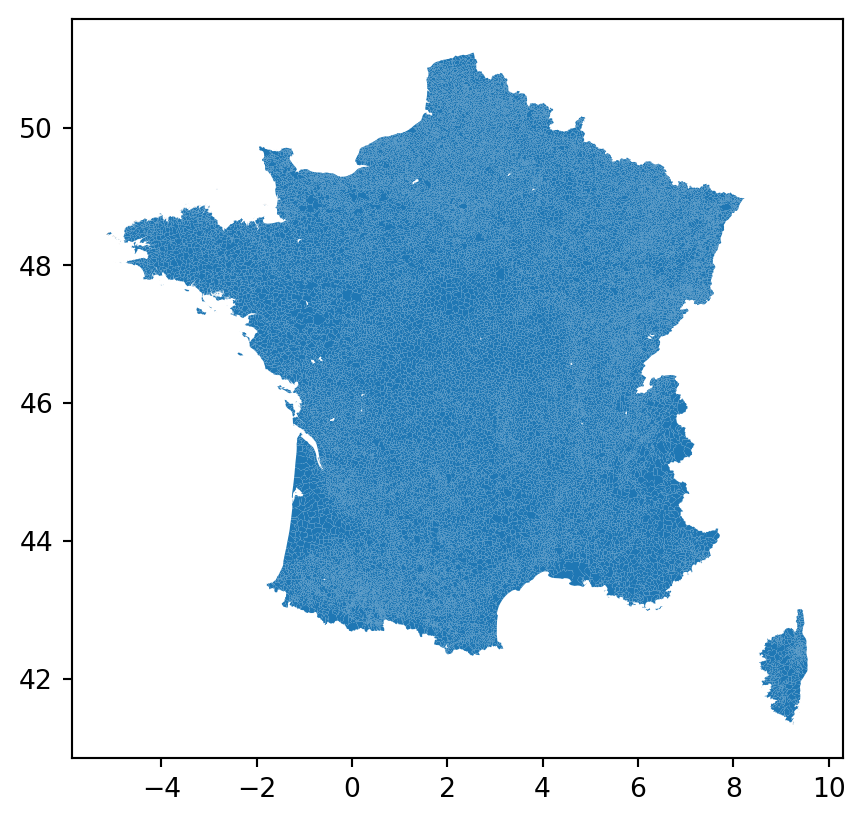

In [21]:
hexagone.plot()

# Indicateurs de risque physique

In [22]:
data_climat_ref = pd.read_table("../Data/indicesALADIN63_CNRM-CM5_REF.txt", skiprows=23, sep=";")
data_climat_rcp26 = pd.read_table("../Data/indicesALADIN63_CNRM-CM5_RCP26.txt",  skiprows=23, sep=";")

header = ["point", "latitude", "longitude", "contexte", "dat_deb", "TAV", "PN20MM", "PQ90","PQ99", "RR99"]

row_temp = data_climat_ref.columns
data_climat_ref = data_climat_ref.iloc[:,:-1]
data_climat_ref.columns = header

data_climat_rcp26 = data_climat_rcp26.iloc[:,:-1]
data_climat_rcp26.columns = header

data_climat = pd.concat([data_climat_ref, data_climat_rcp26])
data_climat.head()

,point,latitude,longitude,contexte,dat_deb,TAV,PN20MM,PQ90,PQ99,RR99
0,11741,47.3229,-3.2243,REF,1990,13.06,6,7.81,20.39,6
1,11741,47.3229,-3.2243,REF,1991,12.27,1,6.69,16.46,1
2,11741,47.3229,-3.2243,REF,1992,12.17,4,6.84,19.21,4
3,11741,47.3229,-3.2243,REF,1993,12.52,4,6.11,20.11,4
4,11741,47.3229,-3.2243,REF,1994,11.99,4,7.65,20.06,4


In [23]:
data_climat = gpd.GeoDataFrame(data_climat,
                                  geometry=gpd.points_from_xy(data_climat['latitude'], data_climat['longitude']),
                                   crs="EPSG:4326")
data_climat.rename(columns={'geometry':'centre_commune'}, inplace=True)

In [24]:
# Variable de positions comparaison des distances
data_climat.set_geometry('centre_commune', inplace=True)
carte_france.set_geometry('centre_commune', inplace=True)

data_climat = gpd.sjoin_nearest(data_climat, carte_france, how='left', max_distance=None)
data_climat.head()

D:\deb\MyWebSite\franckdeba-ws\.venv\Lib\site-packages\geopandas\array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,point,latitude,longitude,contexte,dat_deb,TAV,PN20MM,PQ90,PQ99,RR99,...,cod_commune,lib_commune,wikipedia,surf_ha,geometry,cod_reg,lib_reg,cod_dep,lib_dep,code_postal
0,11741,47.3229,-3.2243,REF,1990,13.06,6,7.81,20.39,6,...,56241,Sauzon,fr:Sauzon,2304.0,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",53,Bretagne,56,Morbihan,56360
1,11741,47.3229,-3.2243,REF,1991,12.27,1,6.69,16.46,1,...,56241,Sauzon,fr:Sauzon,2304.0,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",53,Bretagne,56,Morbihan,56360
2,11741,47.3229,-3.2243,REF,1992,12.17,4,6.84,19.21,4,...,56241,Sauzon,fr:Sauzon,2304.0,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",53,Bretagne,56,Morbihan,56360
3,11741,47.3229,-3.2243,REF,1993,12.52,4,6.11,20.11,4,...,56241,Sauzon,fr:Sauzon,2304.0,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",53,Bretagne,56,Morbihan,56360
4,11741,47.3229,-3.2243,REF,1994,11.99,4,7.65,20.06,4,...,56241,Sauzon,fr:Sauzon,2304.0,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",53,Bretagne,56,Morbihan,56360


In [25]:
data_climat = data_climat[['contexte',
            'dat_deb',
            'TAV',
            'PN20MM',
            'PQ90',
            'PQ99',
            'RR99',
            'centre_commune',
            'cod_commune',
            'lib_commune',
            'cod_reg',
            'lib_reg',
            'cod_dep',
            'lib_dep',
            'code_postal',
           'geometry']]

# Matching indicateurs de risque et catnat

<Axes: >

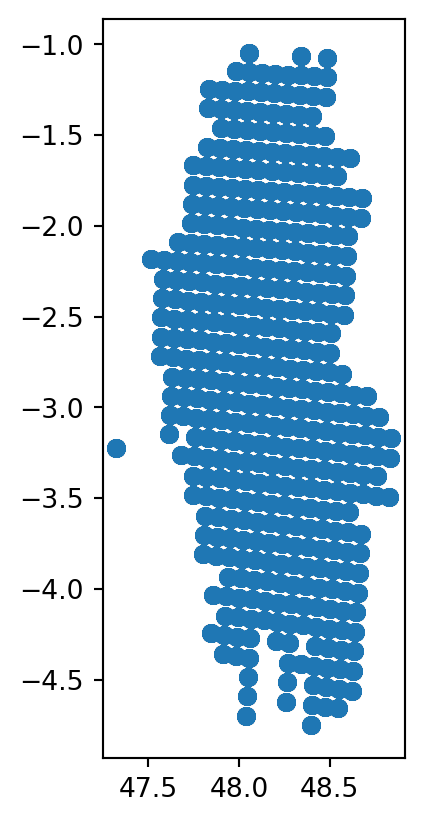

In [26]:
data_climat.plot()

<Axes: >

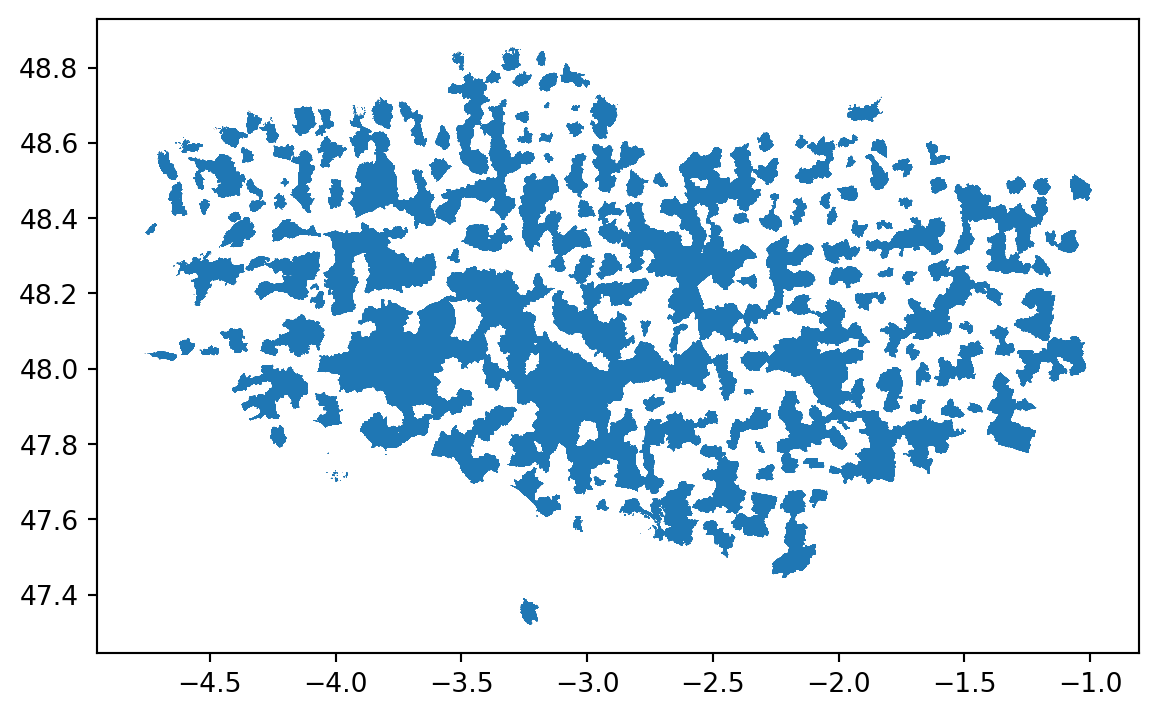

In [27]:
data_climat.set_geometry('geometry', inplace=True)
data_climat.plot()


In [28]:
data_climat = data_climat.merge(catnat_flood[['cod_commune', 'dat_deb', 'dat_fin', 'duree']], on = ["dat_deb", "cod_commune"], how='left')

In [29]:
data_climat.head()

,contexte,dat_deb,TAV,PN20MM,PQ90,PQ99,RR99,centre_commune,cod_commune,lib_commune,cod_reg,lib_reg,cod_dep,lib_dep,code_postal,geometry,dat_fin,duree
0,REF,1990,13.06,6,7.81,20.39,6,POINT (47.3229 -3.2243),56241,Sauzon,53,Bretagne,56,Morbihan,56360,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",NaN,NaT
1,REF,1991,12.27,1,6.69,16.46,1,POINT (47.3229 -3.2243),56241,Sauzon,53,Bretagne,56,Morbihan,56360,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",NaN,NaT
2,REF,1992,12.17,4,6.84,19.21,4,POINT (47.3229 -3.2243),56241,Sauzon,53,Bretagne,56,Morbihan,56360,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",NaN,NaT
3,REF,1993,12.52,4,6.11,20.11,4,POINT (47.3229 -3.2243),56241,Sauzon,53,Bretagne,56,Morbihan,56360,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",NaN,NaT
4,REF,1994,11.99,4,7.65,20.06,4,POINT (47.3229 -3.2243),56241,Sauzon,53,Bretagne,56,Morbihan,56360,"MULTIPOLYGON (((-3.2645 47.3599, -3.26443 47.3...",NaN,NaT


In [30]:
data_climat['cat_nat'] = 1
data_climat.loc[data_climat.dat_fin.isna(), 'cat_nat'] = 0

# Stat Desc

In [31]:
data = data_climat[['contexte', 'dat_deb', 'TAV', 'PN20MM', 'PQ90', 'PQ99', 'RR99','cat_nat']]
data_rcp = data[data.contexte != 'REF'] 
train_test_oot = data[data.contexte == 'REF']
train_test_oot.drop(columns=['contexte'], inplace=True)

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\514289987.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_test_oot.drop(columns=['contexte'], inplace=True)


In [32]:
train_test_oot.describe()

,dat_deb,TAV,PN20MM,PQ90,PQ99,RR99,cat_nat
count,6896.000000,6896.000000,6896.000000,6896.000000,6896.000000,6896.000000,6896.000000
mean,1997.506235,11.442807,5.460412,7.851459,21.347710,3.790313,0.163283
std,4.597059,0.607228,3.355927,1.716521,4.383474,1.954552,0.369651
min,1990.000000,9.590000,0.000000,3.320000,11.440000,0.000000,0.000000
25%,1994.000000,11.010000,3.000000,6.700000,18.030000,2.000000,0.000000
50%,1998.000000,11.430000,5.000000,7.680000,21.010000,4.000000,0.000000
75%,2001.000000,11.890000,7.000000,8.990000,24.120000,5.000000,0.000000
max,2005.000000,13.280000,20.000000,13.880000,38.910000,12.000000,1.000000


In [33]:
from myFunctions import *

data_oot = train_test_oot[train_test_oot.dat_deb > 2000]
train_test = train_test_oot[train_test_oot.dat_deb <= 2000]

data_train, data_test = sampleData(train_test, ['dat_deb', 'cat_nat'], frac = .2, rand_state=49)

D:\deb\MyWebSite\franckdeba-ws\projects\Climate\Notebooks\myFunctions.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['strat_var'] = df[var].astype(str).agg('_'.join, axis=1)


In [34]:
describe_cat(data_train[['dat_deb', 'cat_nat']])


Proportion de chaque catégorie dans dat_deb:
dat_deb
1999    0.094071
2000    0.092490
1993    0.091700
1995    0.091436
1990    0.090646
1997    0.090382
1994    0.090382
1996    0.089855
1991    0.089855
1998    0.089592
1992    0.089592
Name: proportion, dtype: float64
_._._._._._._._._._._._._._._._._._._.__._._

Proportion de chaque catégorie dans cat_nat:
cat_nat
0    0.788669
1    0.211331
Name: proportion, dtype: float64
_._._._._._._._._._._._._._._._._._._.__._._


In [35]:
def stabilite_structurelle(data, var, datdelhis, title):
    df = data.copy()
        
    # proportion mensuelle par catégorie
    df = data.groupby([datdelhis, var]).size().reset_index(name='count')
    df['freq'] = df.groupby([datdelhis])['count'].transform(lambda x: x / x.sum()) * 100
    
    # Evolution mensuelle 
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x=datdelhis, y='freq', hue=var, marker='o')
    #plt.plot(df[datdelhis], df['freq'])
    plt.title(title)
    plt.xlabel("Date d'observation")
    plt.ylabel('Pourcentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return df

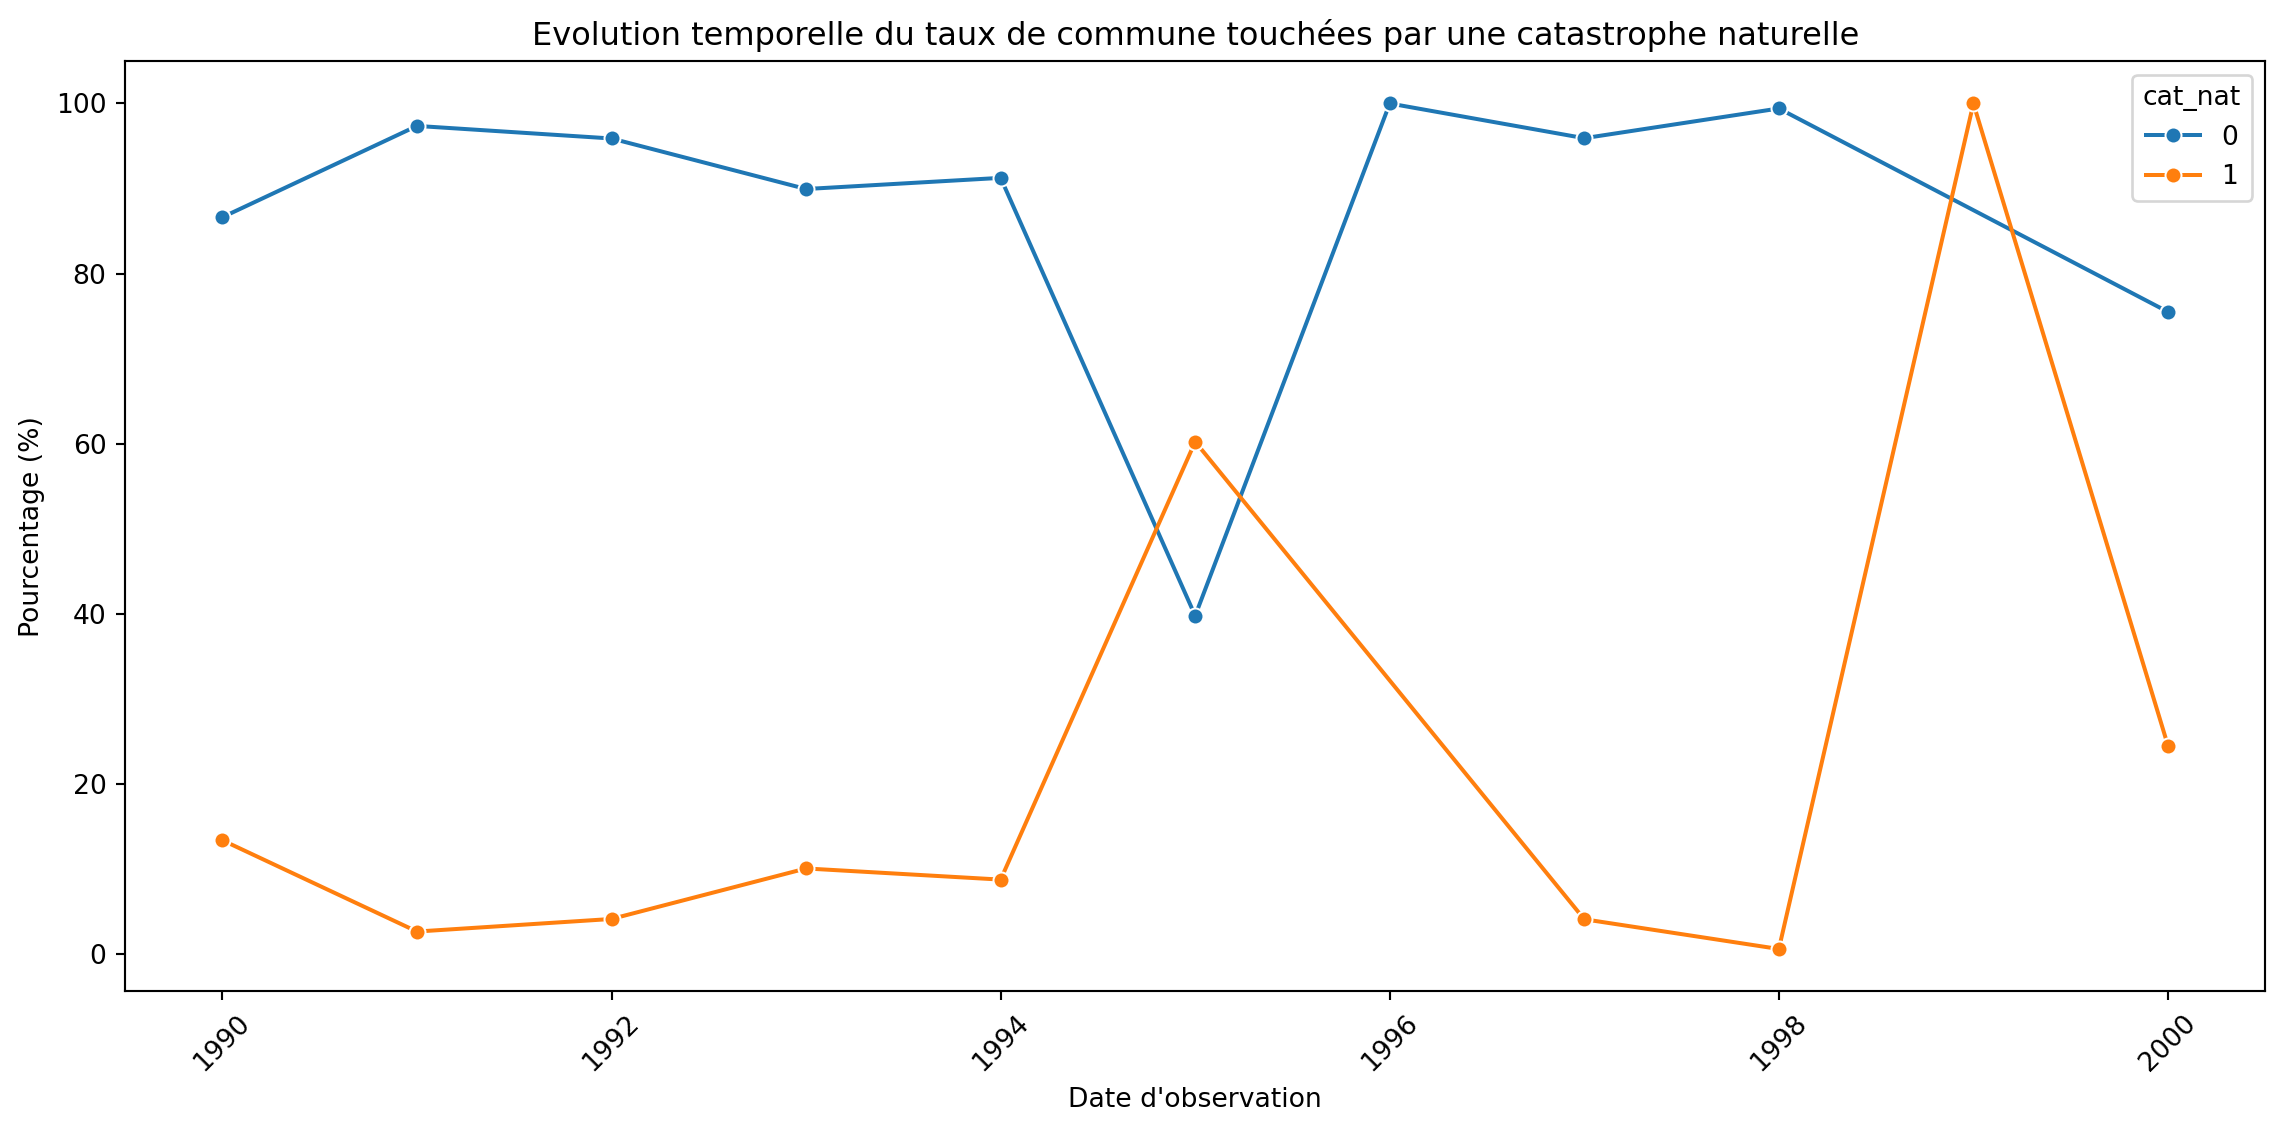

In [36]:
# 15 vs autres
df = stabilite_structurelle(data_train, 'cat_nat', 'dat_deb', "Evolution temporelle du taux de commune touchées par une catastrophe naturelle")

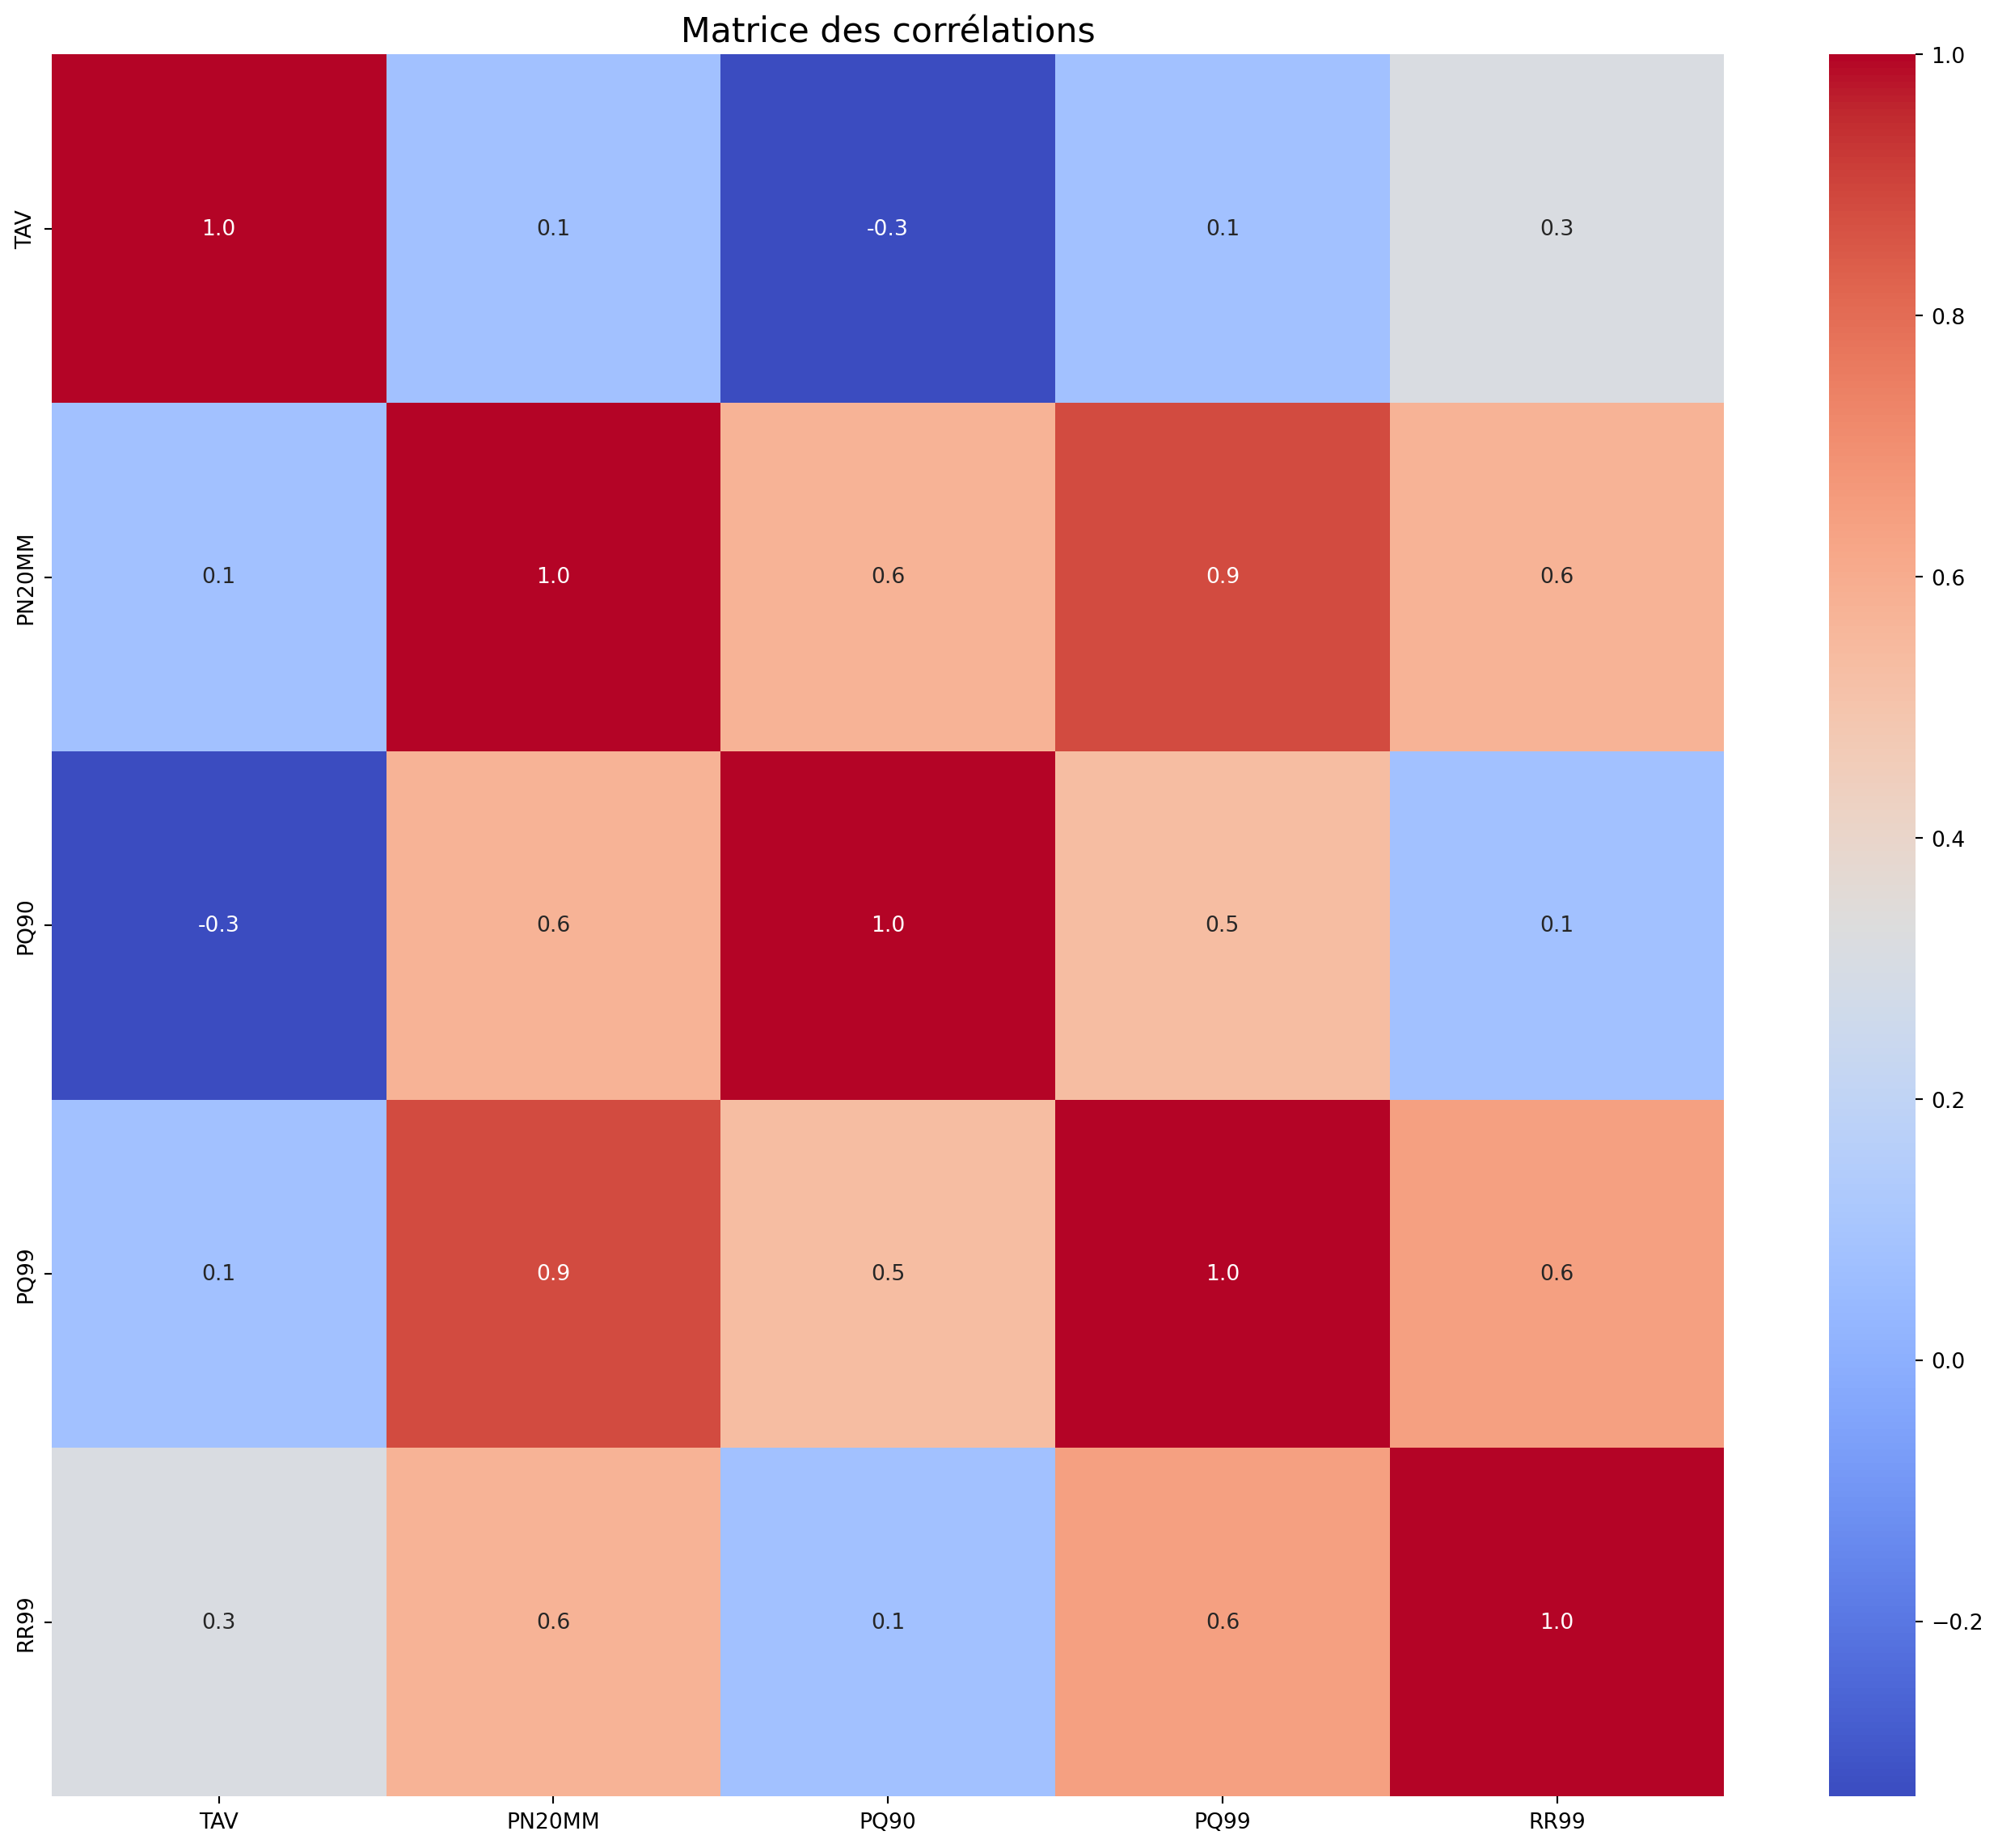

In [37]:
# Matrice des corrélations
col_num = ['TAV', 'PN20MM', 'PQ90', 'PQ99', 'RR99']
corr_matrix = data_train[col_num].corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm', cbar=True)

# Customize plot title
plt.title('Matrice des corrélations', fontsize=16)
plt.tight_layout()

# Show the plot
plt.show()

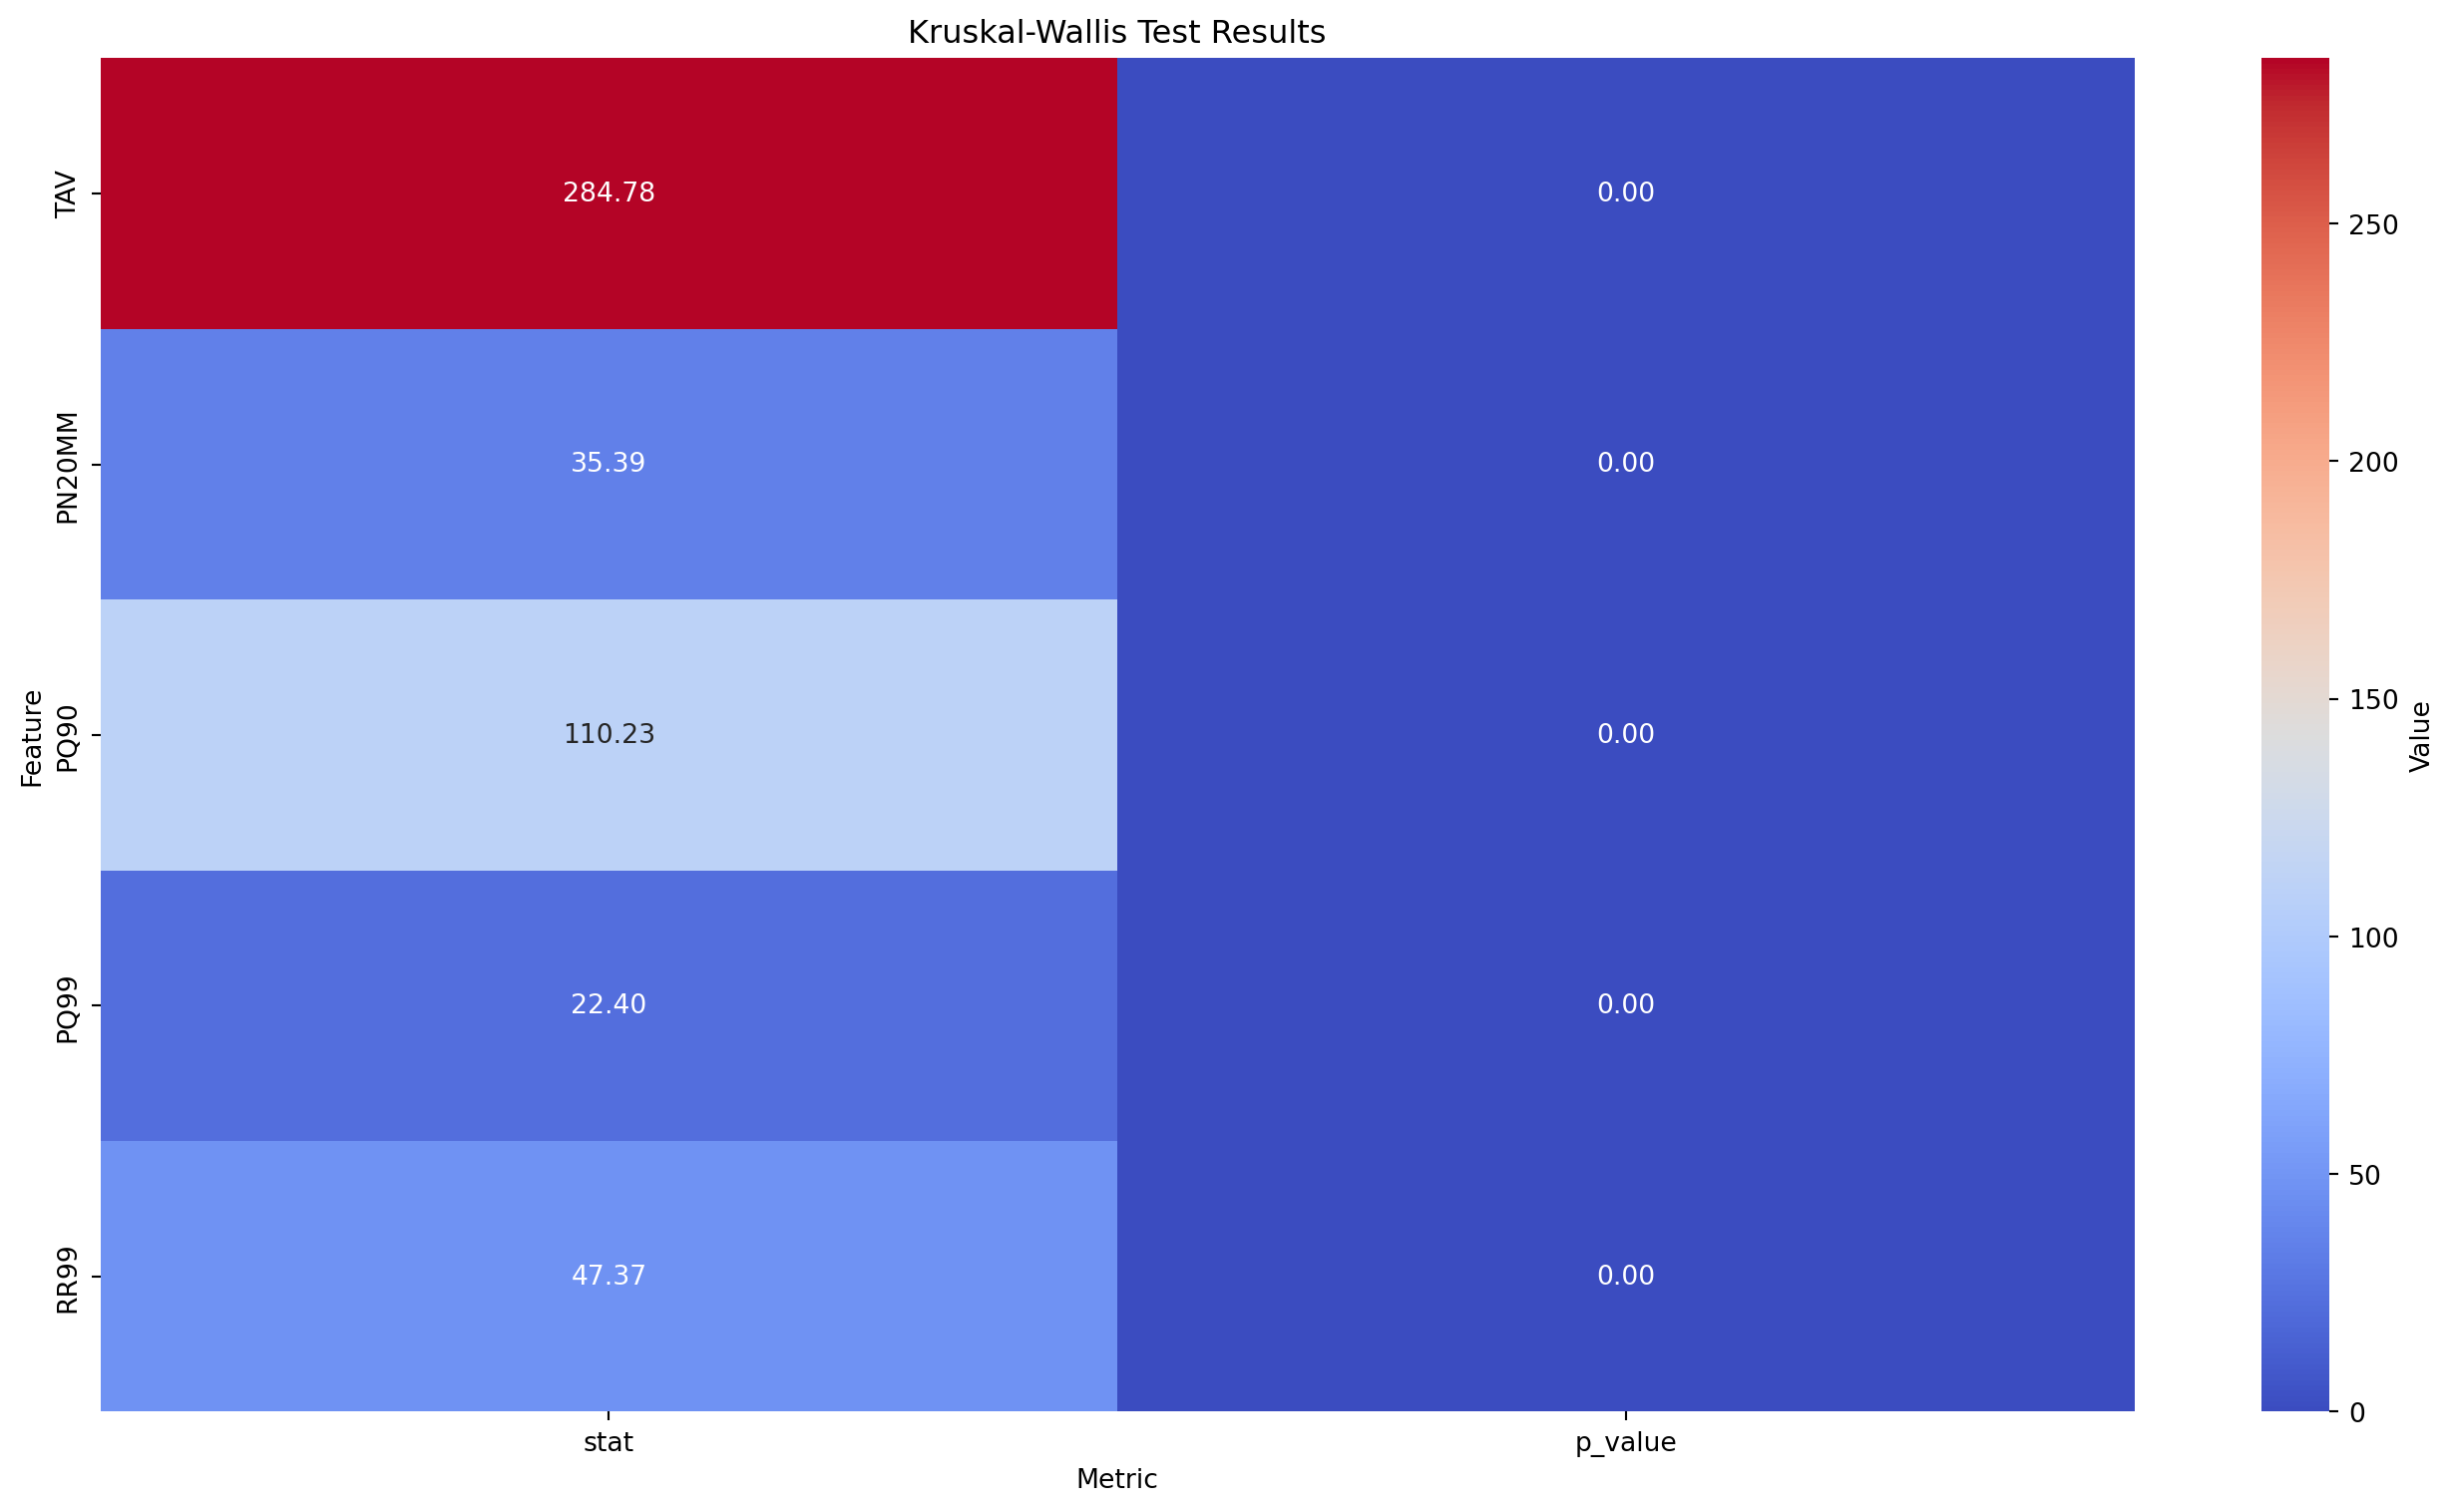

In [38]:
from scipy.stats import kruskal

# Kruskal-Wallis test for each feature
results = {}
for col in col_num:  # Skip the 'Group' column
    grouped_data = [data_train[data_train['cat_nat'] == g][col] for g in data_train['cat_nat'].unique()]
    stat, p_value = kruskal(*grouped_data)
    results[col] = {'stat': stat, 'p_value': p_value}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Heatmap visualization
plt.figure(figsize=(14, 8))
sns.heatmap(
    results_df[['stat', 'p_value']],  # Show stats and p-values
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Value'}
)

plt.title('Kruskal-Wallis Test Results')
plt.ylabel('Feature')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

In [39]:
# Var significatives
results_df['significant'] = results_df['p_value'] < 0.05

In [40]:
results_df[results_df['significant']].sort_values('stat', ascending=False)

,stat,p_value,significant
TAV,284.777537,6.831544e-64,True
PQ90,110.232391,8.715085e-26,True
RR99,47.373366,5.867453e-12,True
PN20MM,35.389648,2.699177e-09,True
PQ99,22.404541,2.208512e-06,True


# Discrétisation

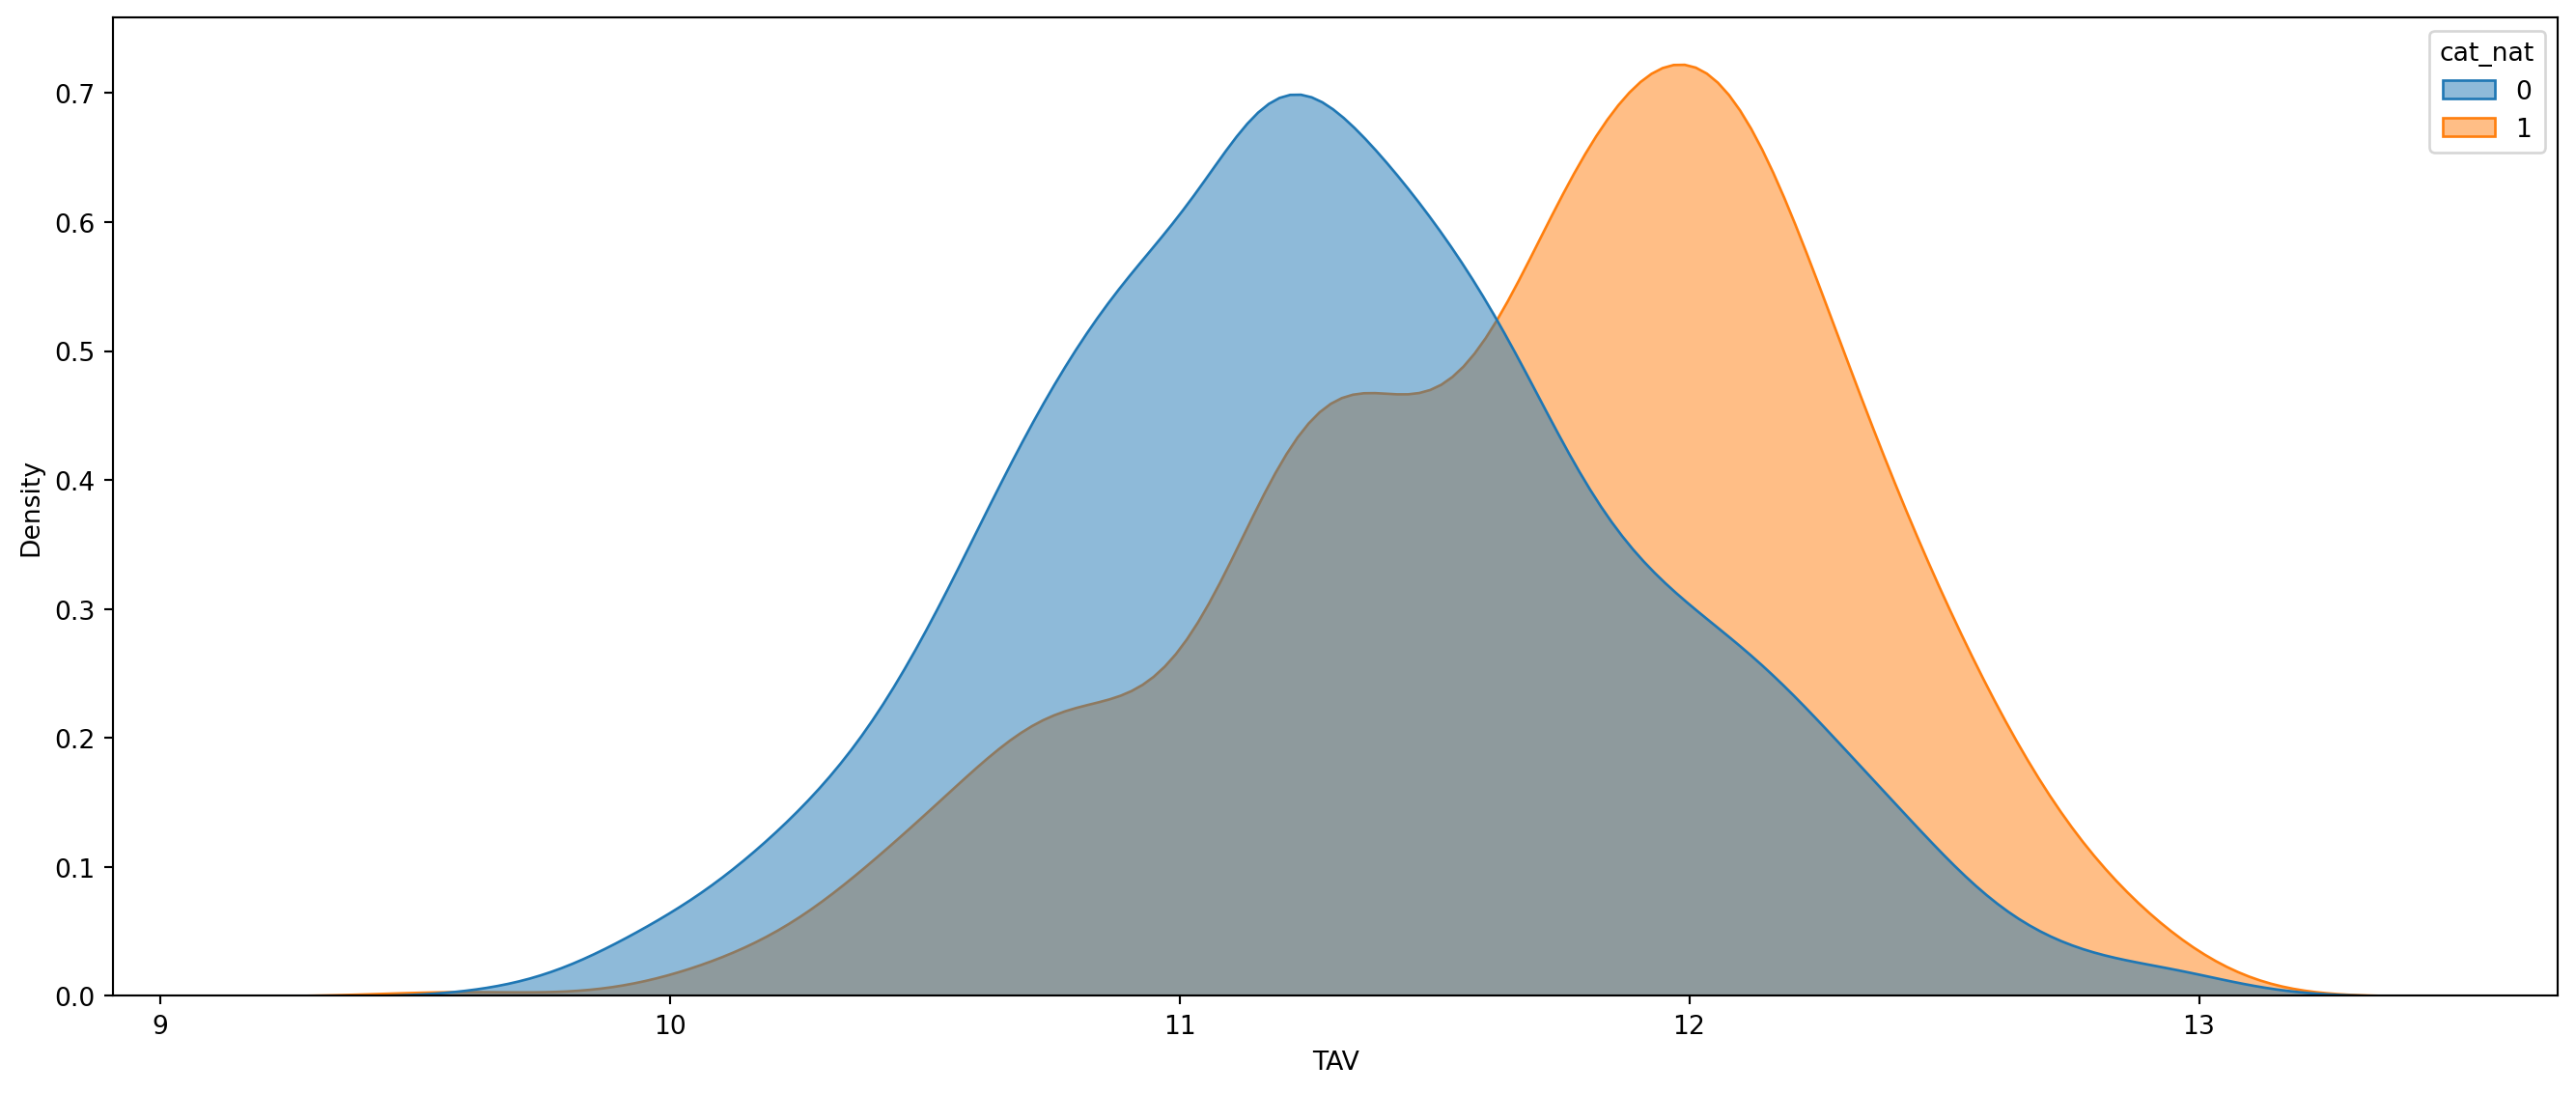

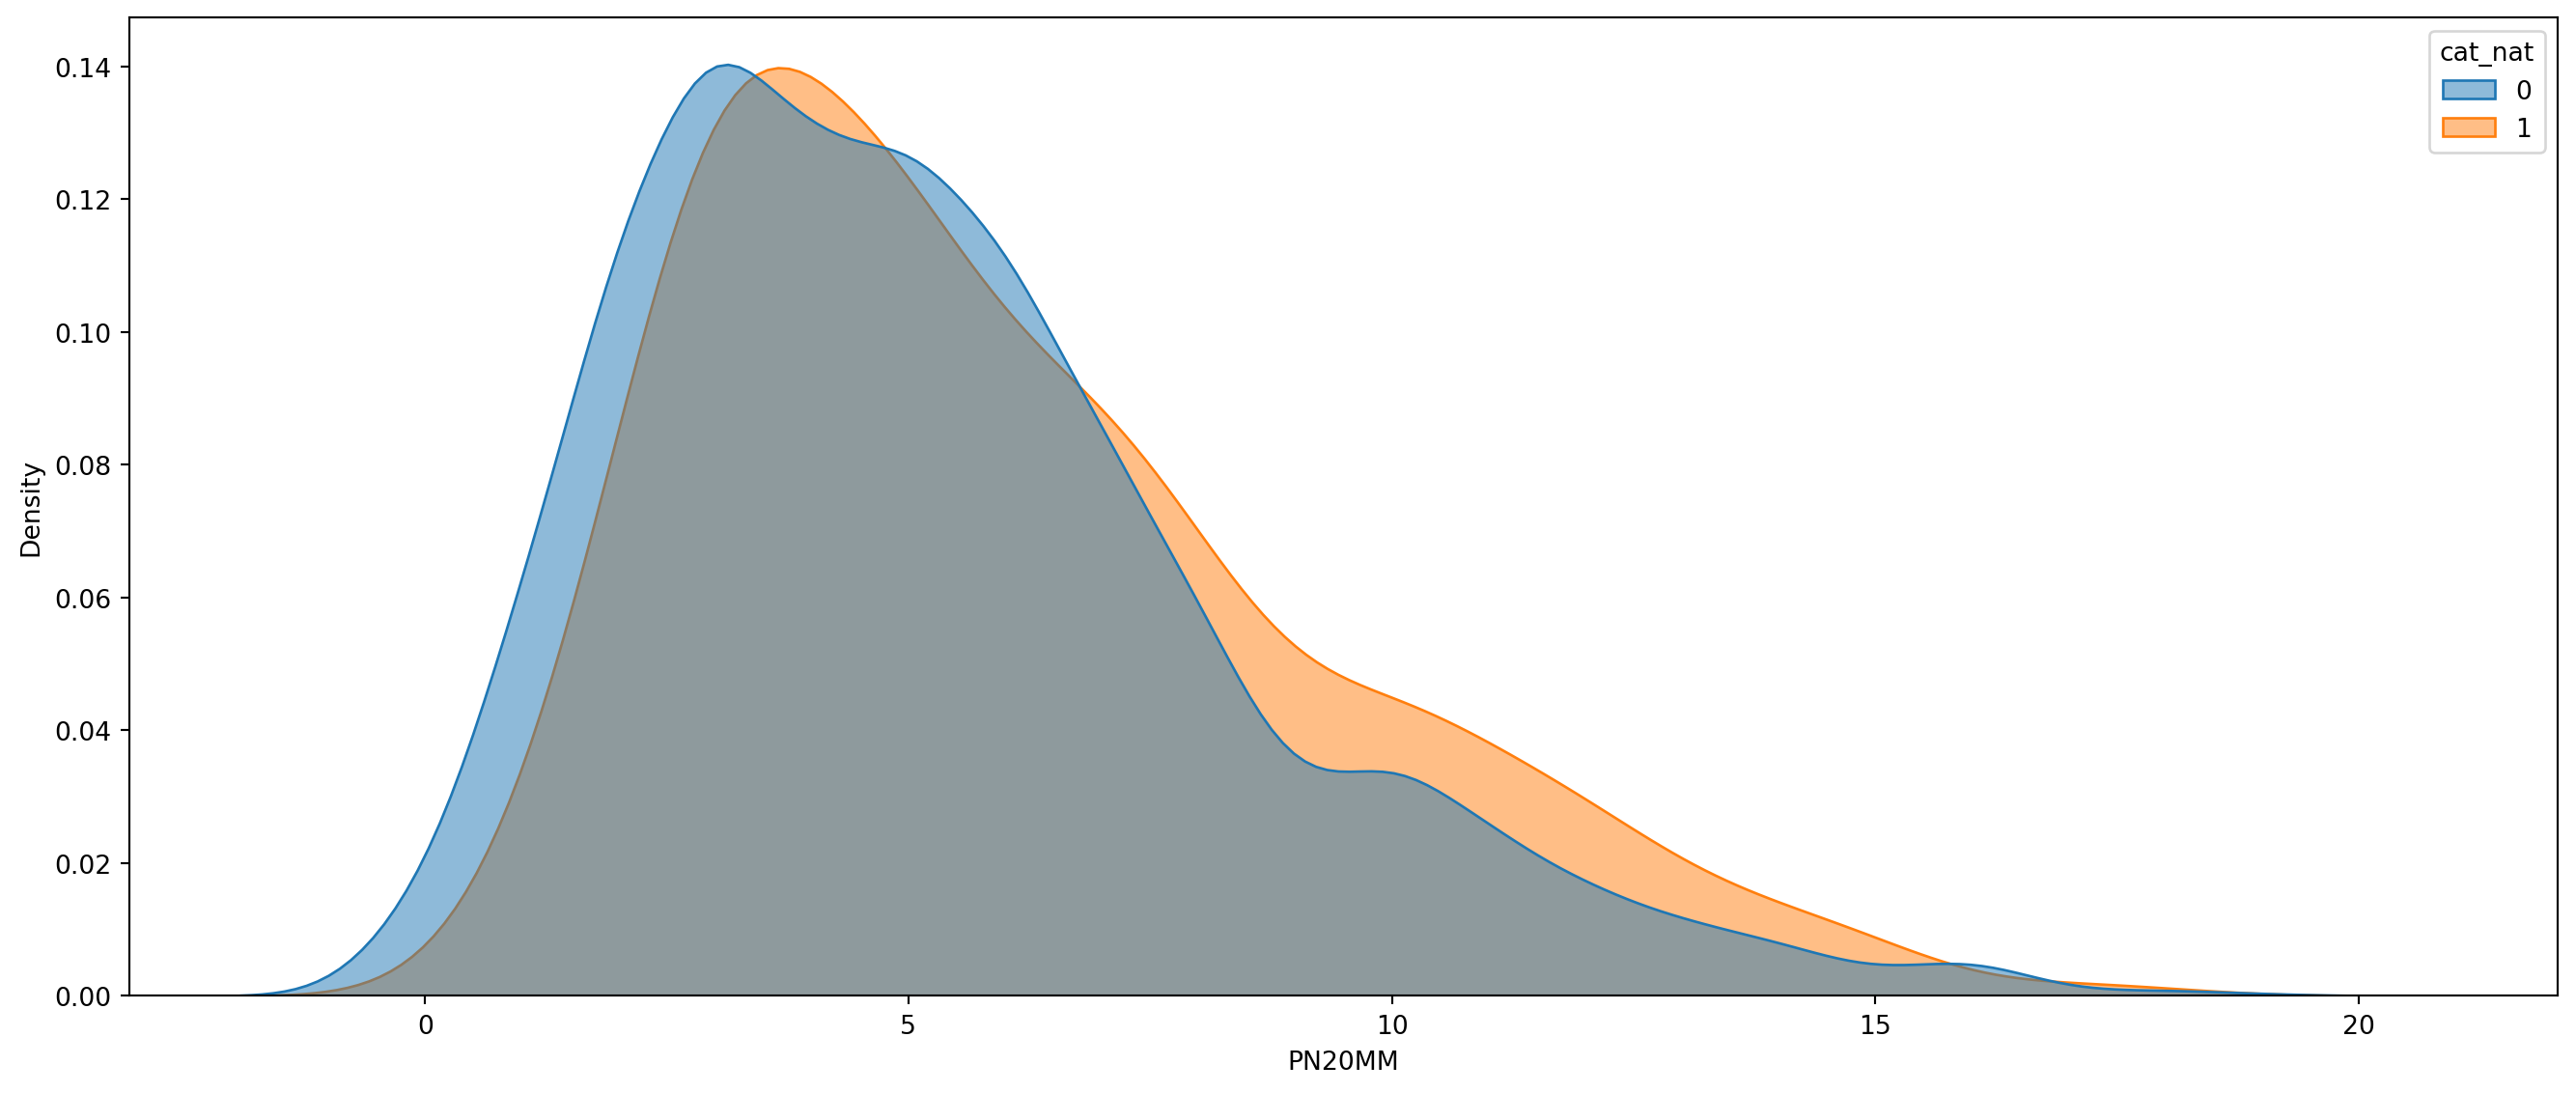

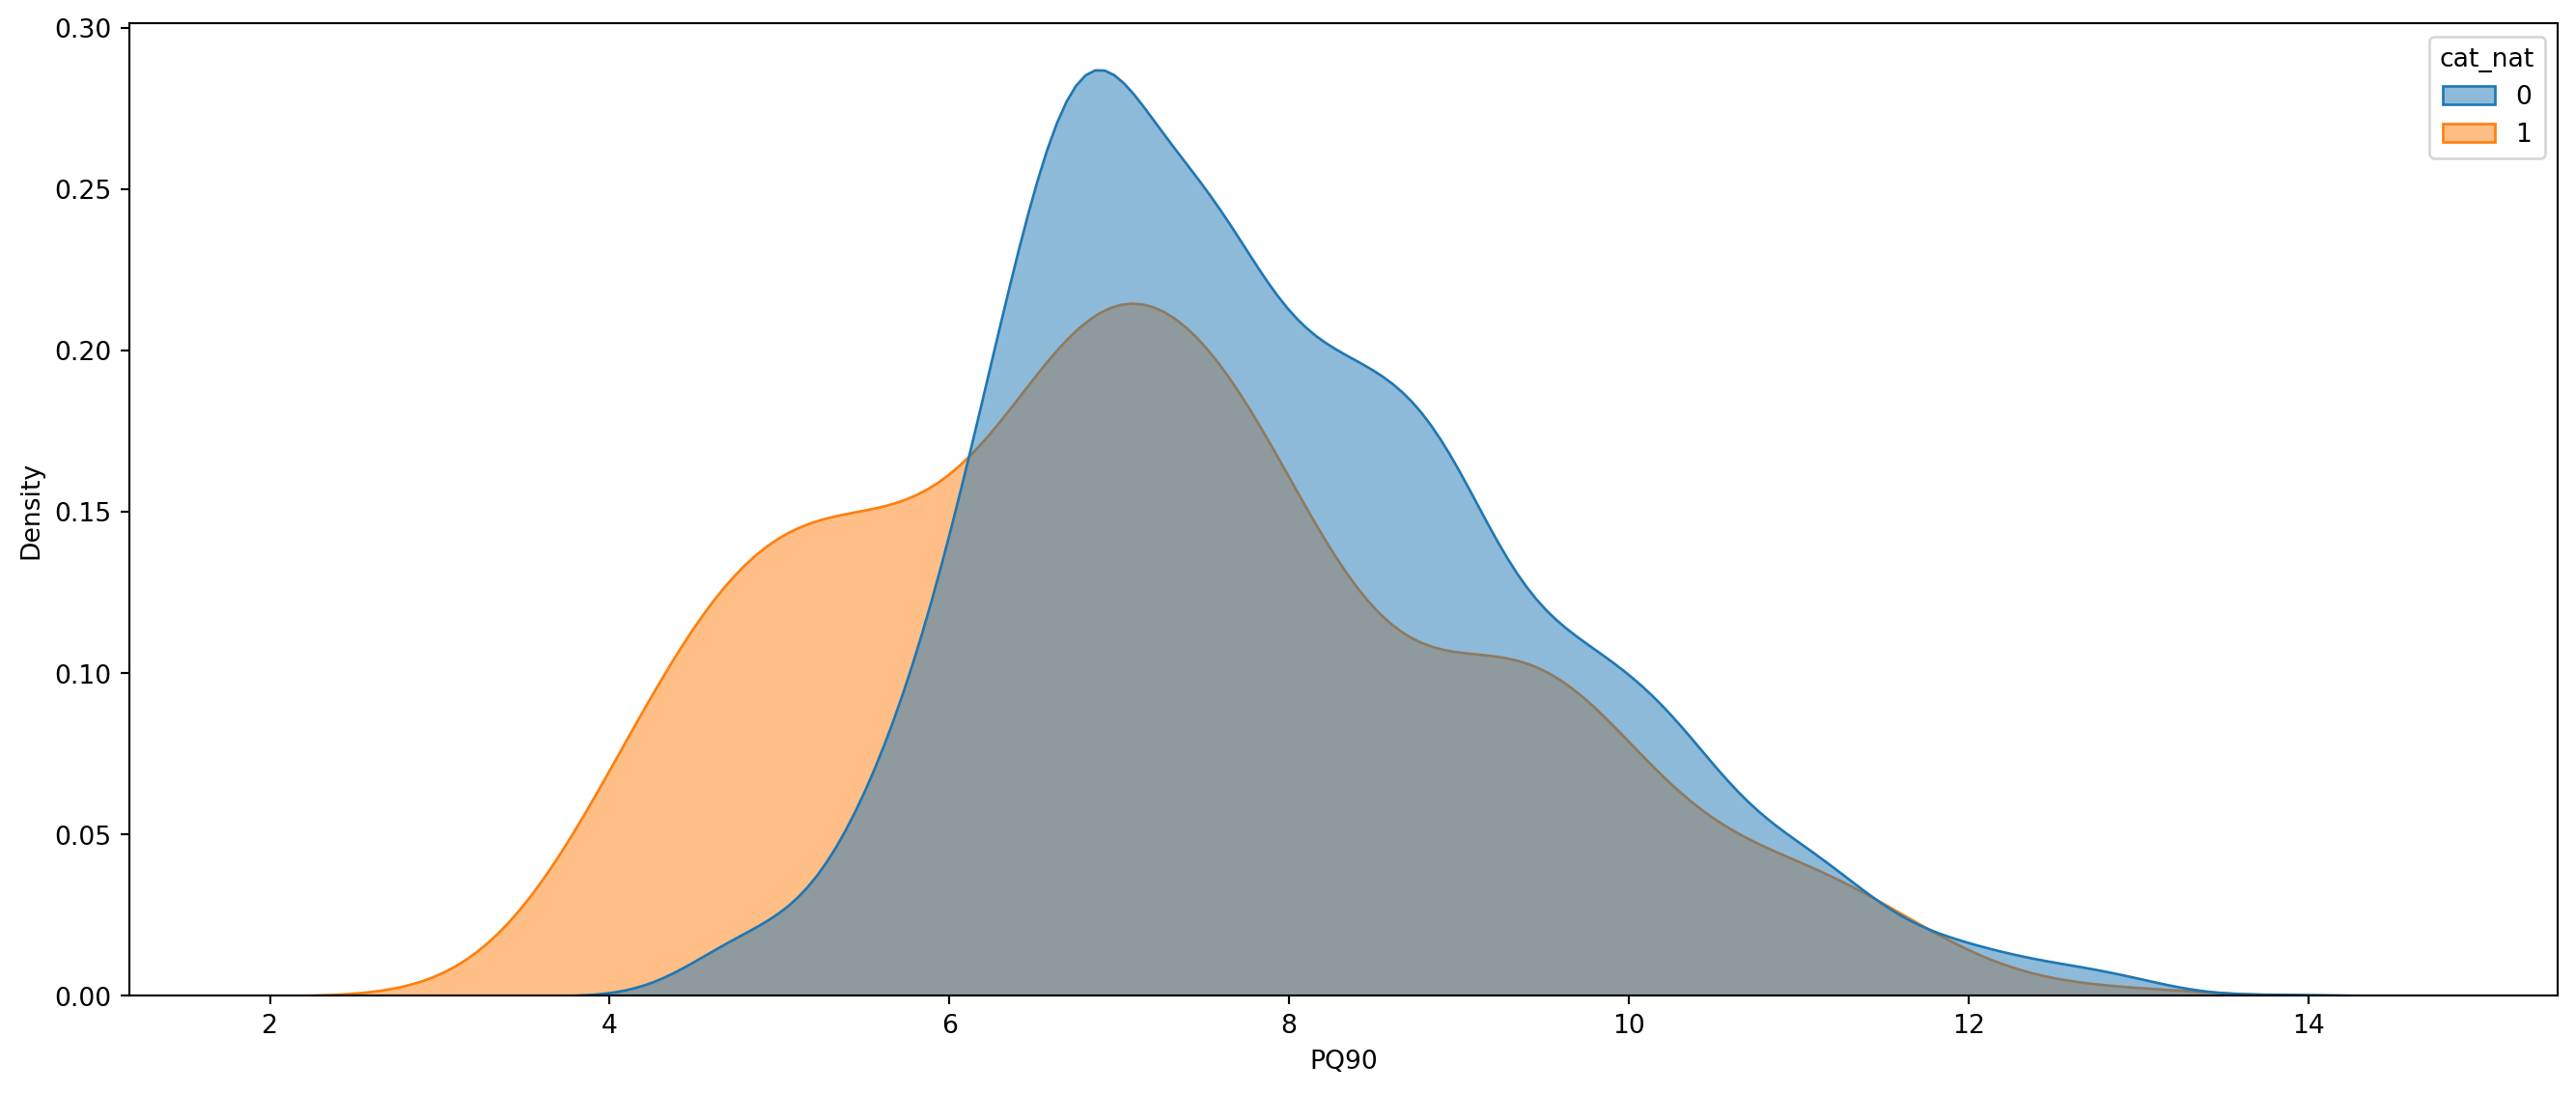

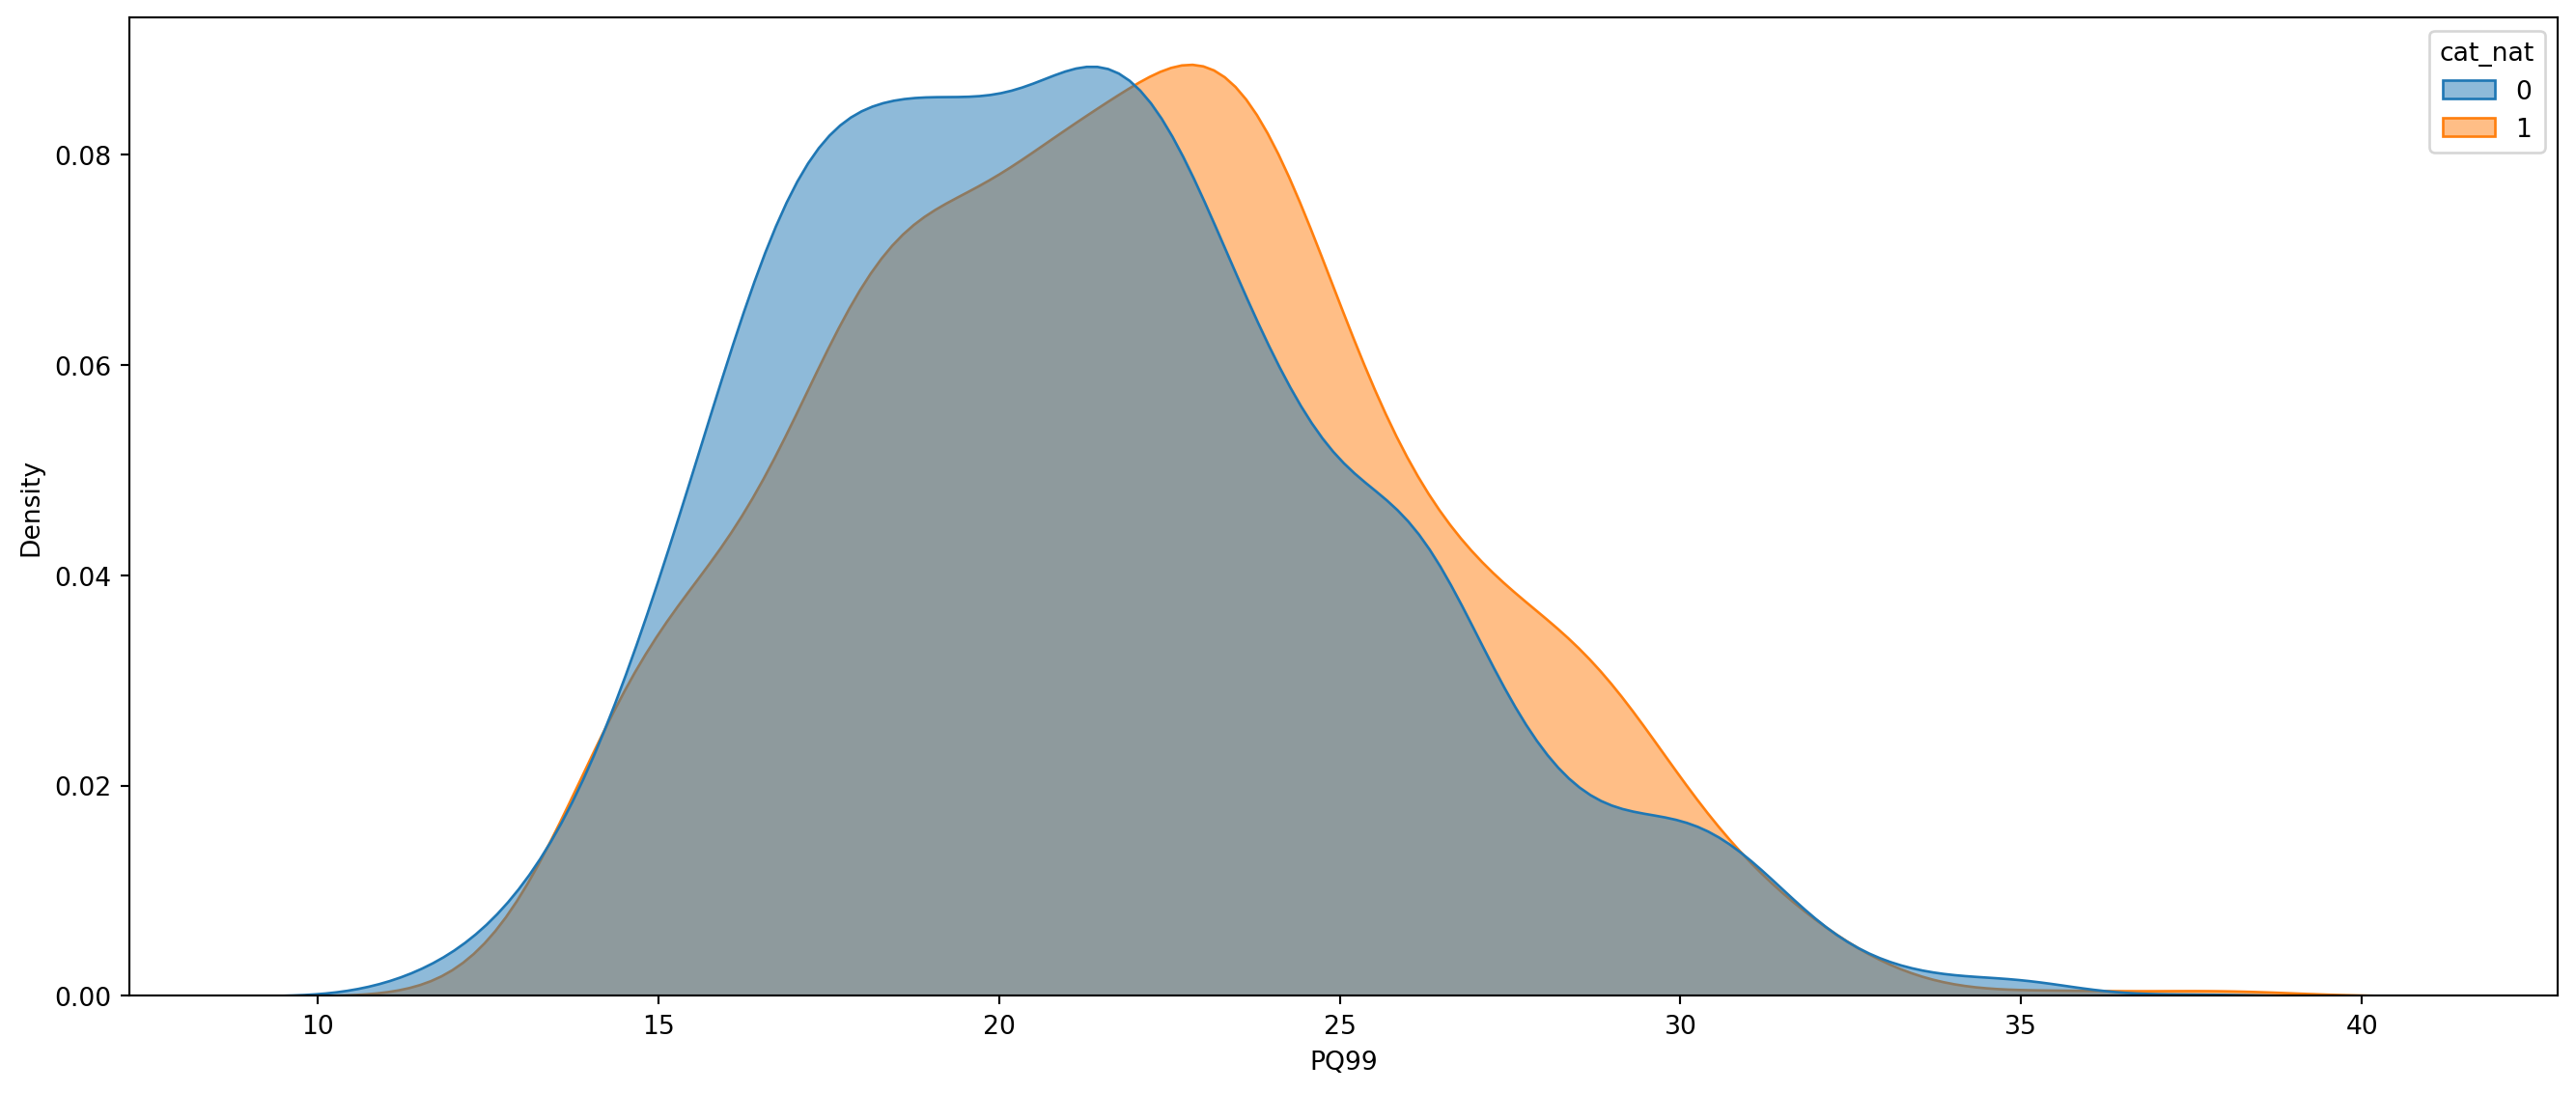

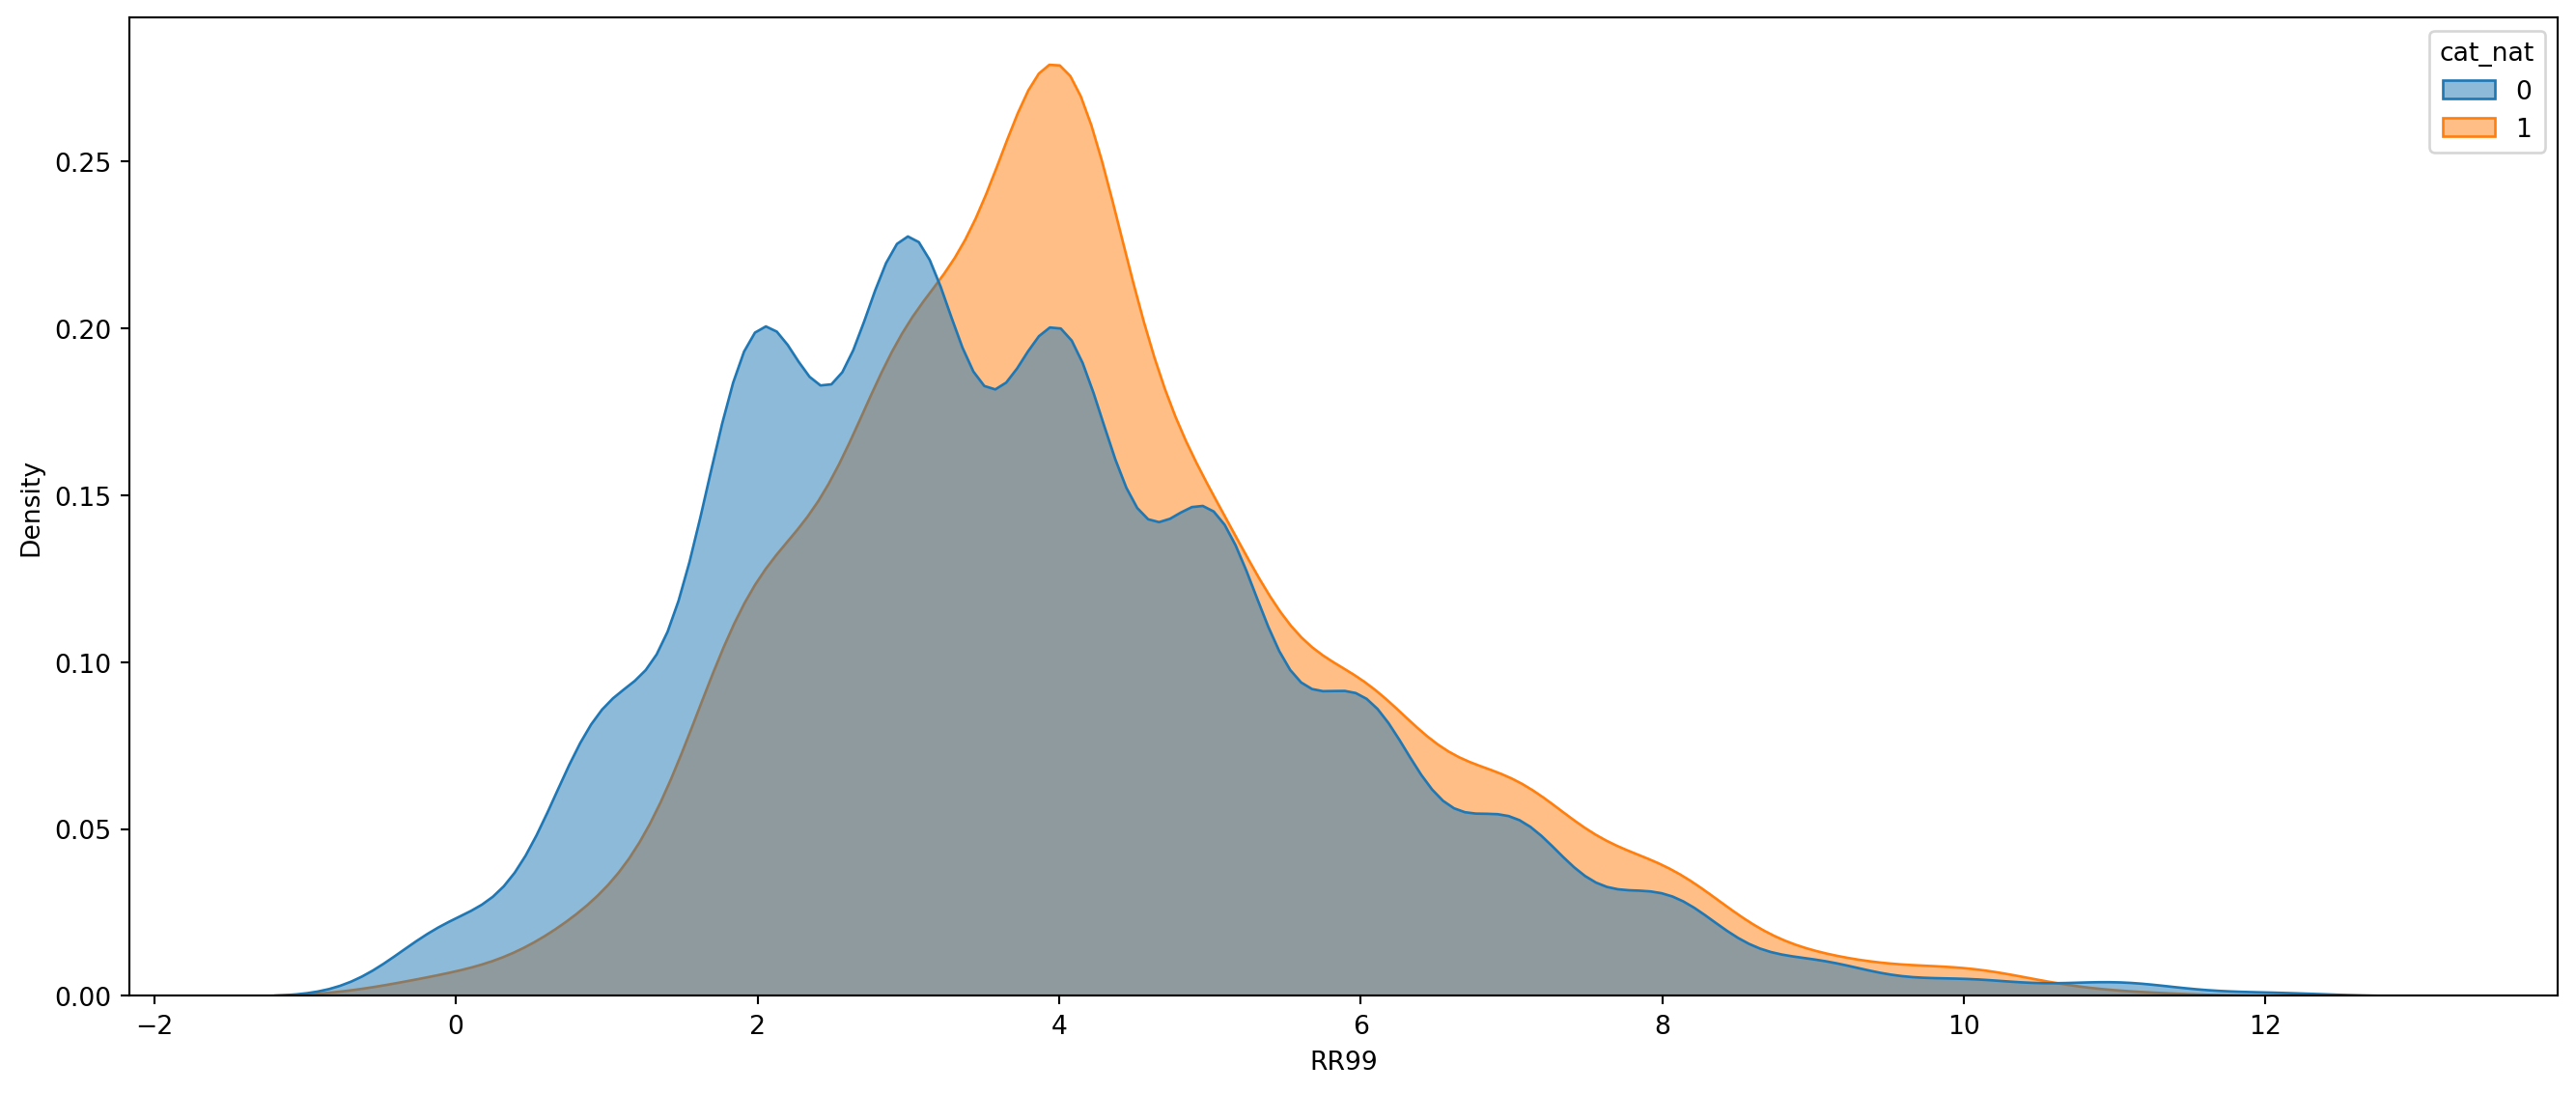

In [41]:
for col in col_num:
    plt.figure(figsize=(14, 6))
    sns.kdeplot(
    data=data_train,  # Dataframe containing the data
    x=col,  # Column to be plotted on the x-axis
    hue='cat_nat',  # Column to define categories/colors
    fill=True,  # Fill the area under the KDE curve
    common_norm=False,  # Normalize separately for each hue level
    alpha=0.5 # Transparency of the fill
    )
    plt.tight_layout()
    plt.show()

In [42]:
def concentration_plot(data, hcr, target, date_column, label="HCR concentration through issue date", save_figures=False, output_dir="./"):
    """
    Plots volume concentration and default rate over time, with an option to save the figures.

    Parameters:
    data (pd.DataFrame): Input DataFrame.
    hcr (str): Column name for the risk class (e.g., 'CHR').
    target (str): Target column (e.g., default indicator).
    date_column (str): Column containing date/time information.
    label (str): Plot label.
    save_figures (bool): Whether to save the figures.
    output_dir (str): Directory to save the figures.
    """
    df_score = data.copy()

    # Ensure the date column is in datetime format
    df_score[date_column] = pd.to_datetime(df_score[date_column].astype(str) + '-01-01')
    
    # Group by year and category, then calculate proportions
    df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(
        part_defaut=(target, 'sum'), 
        volume=(target, 'count')
    ).reset_index()
    
    # Compute correct default rate per risk class per year
    df_score['part_defaut'] = df_score['part_defaut'] * 100 / df_score['volume']

    # Compute correct volume share per year
    df_score['volume'] = df_score.groupby(date_column)['volume'].transform(lambda x: x / x.sum()) * 100

    # Handle NaNs (if any)
    df_score.fillna(0, inplace=True)

    # First Figure: Improved Volume Concentration (Combined)
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_score, x=df_score[date_column].dt.strftime('%Y'), y='volume', hue=hcr, ax=ax1, palette='coolwarm')

    ax1.set_xlabel('Issue Year')
    ax1.set_ylabel('Concentration (%)')
    ax1.set_title(f'Volume by {date_column} over years')
    ax1.legend(title=hcr, bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside the plot

    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the first figure if requested
    if save_figures:
        output_path = f"{output_dir}volume_concentration_combined.png"
        fig1.savefig(output_path, bbox_inches='tight', dpi=300)
        print(f"Saved combined volume concentration plot to {output_path}")

    plt.show()

    # Separate Figure for Each Risk Class (HCR)
    for cl_chr in df_score[hcr].unique():
        fig, ax1 = plt.subplots(figsize=(12, 6))  # Create a new figure for each risk class
        seg_score = df_score[df_score[hcr] == cl_chr]  # Filter data for this class
        
        # Improved Bar Plot (Concentration)
        sns.barplot(data=seg_score, x=seg_score[date_column].dt.strftime('%Y'), y='volume', ax=ax1, color='blue', alpha=0.6, label='Concentration')

        # Improved Line Plot for Default Rate (on secondary y-axis)
        ax2 = ax1.twinx()  # Create a secondary y-axis for default rate
        sns.lineplot(data=seg_score, x=seg_score[date_column].dt.strftime('%Y'), y='part_defaut', ax=ax2, color='red', marker='o', linestyle='-', linewidth=2, label='Default Rate')
        
        # Add labels to the bars (Volume)
        for i, (date, value) in enumerate(zip(seg_score[date_column].dt.strftime('%Y'), seg_score.volume)):
            ax1.text(i, value, f'{value:.1f}%', color='blue', ha='center', va='bottom')

        # Add labels to the points (Default Rate)
        for i, (date, value) in enumerate(zip(seg_score[date_column].dt.strftime('%Y'), seg_score.part_defaut)):
            ax2.text(i, value, f'{value:.1f}%', color='red', ha='center', va='bottom')

        # Labels & Title
        ax1.set_xlabel('Issue Year')
        ax1.set_ylabel('Concentration (%)')
        ax2.set_ylabel('Default Rate (%)')
        ax1.set_title(f'Volume and Default Rate for HRC_{cl_chr} through {date_column}')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc='upper left')

        plt.xticks(rotation=45)
        plt.tight_layout()

        # Save the individual figure if requested
        if save_figures:
            output_path = f"{output_dir}volume_default_rate_HRC_{cl_chr}.png"
            fig.savefig(output_path, bbox_inches='tight', dpi=300)
            print(f"Saved plot for HRC_{cl_chr} to {output_path}")

        plt.show()

In [43]:
col_num

['TAV', 'PN20MM', 'PQ90', 'PQ99', 'RR99']

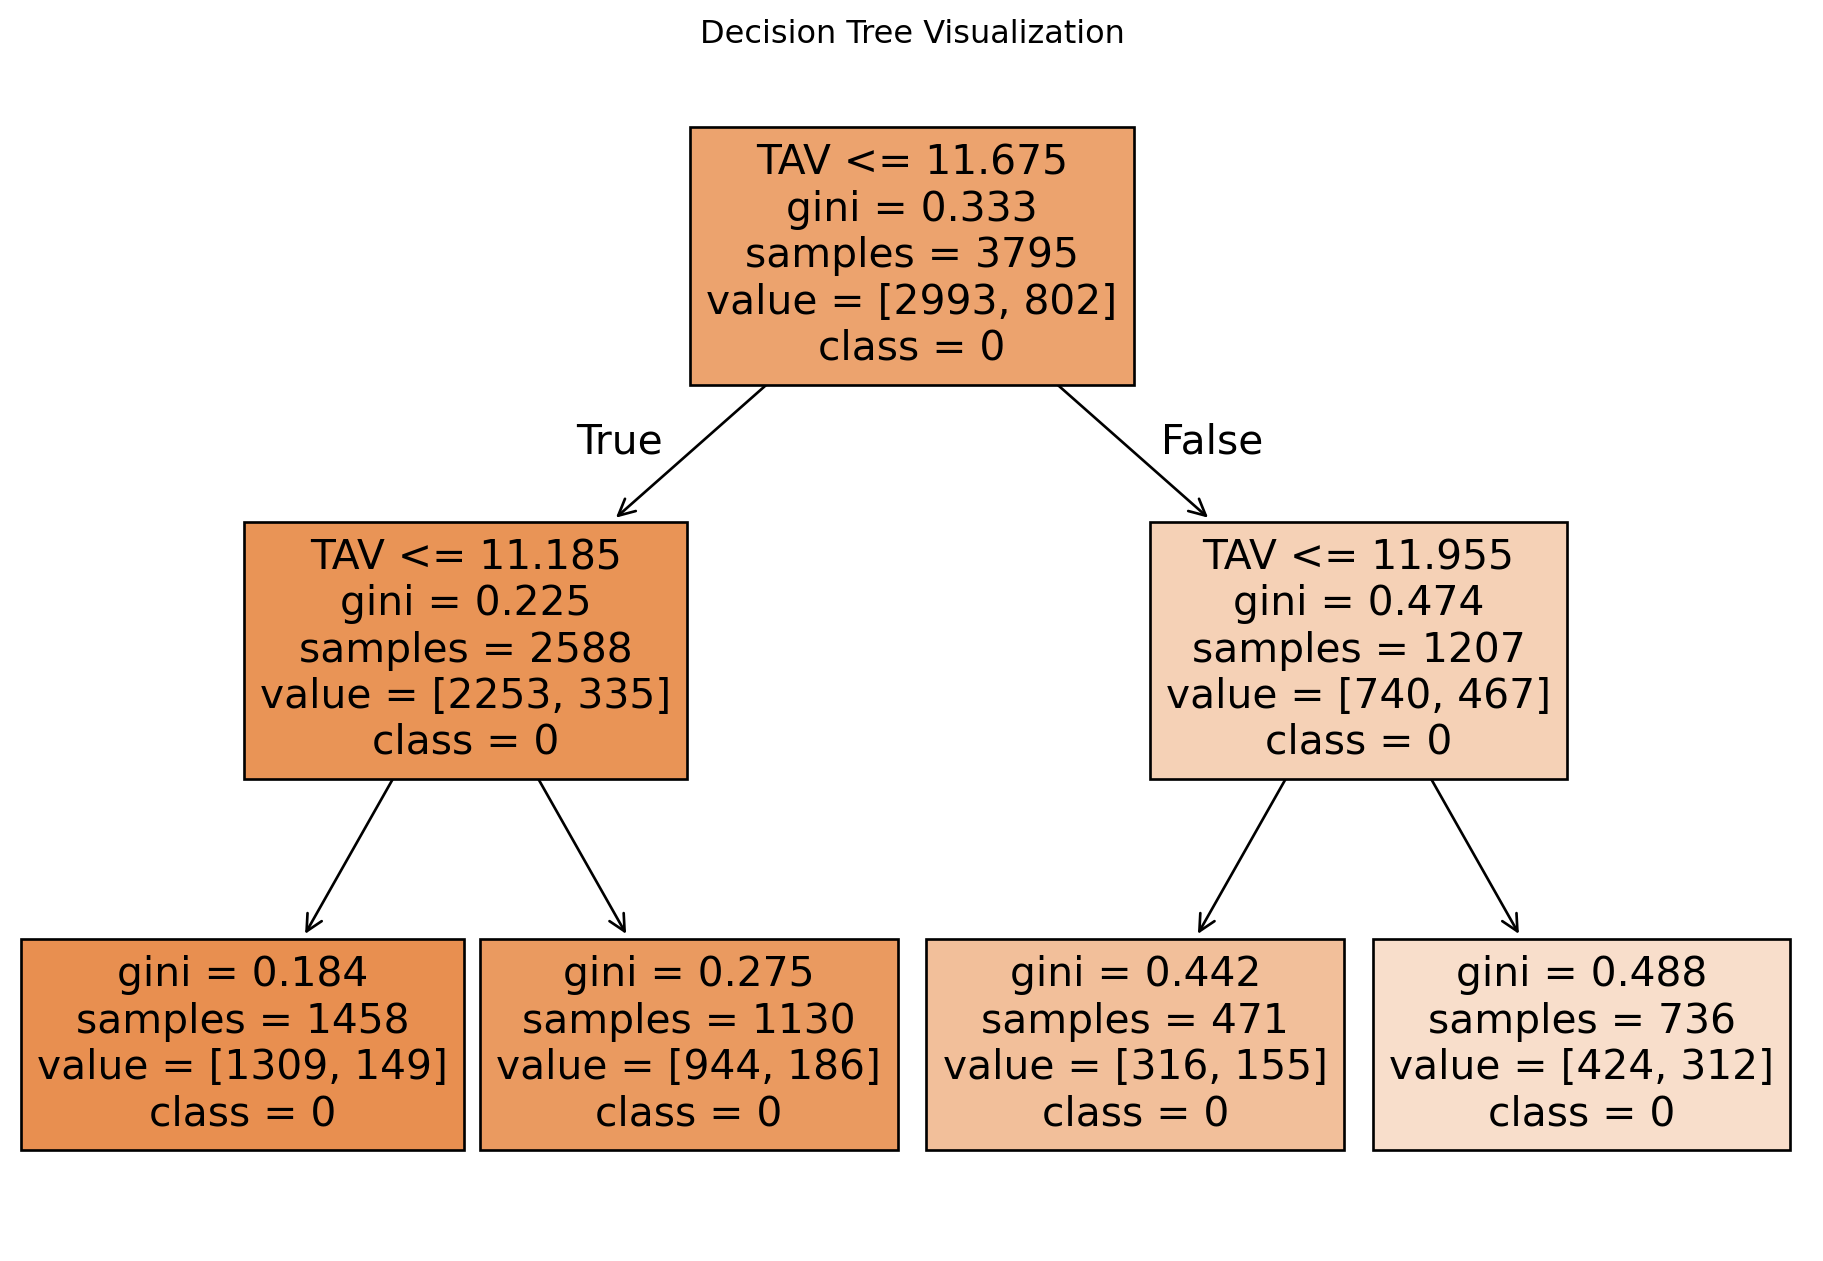

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3037785039.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(


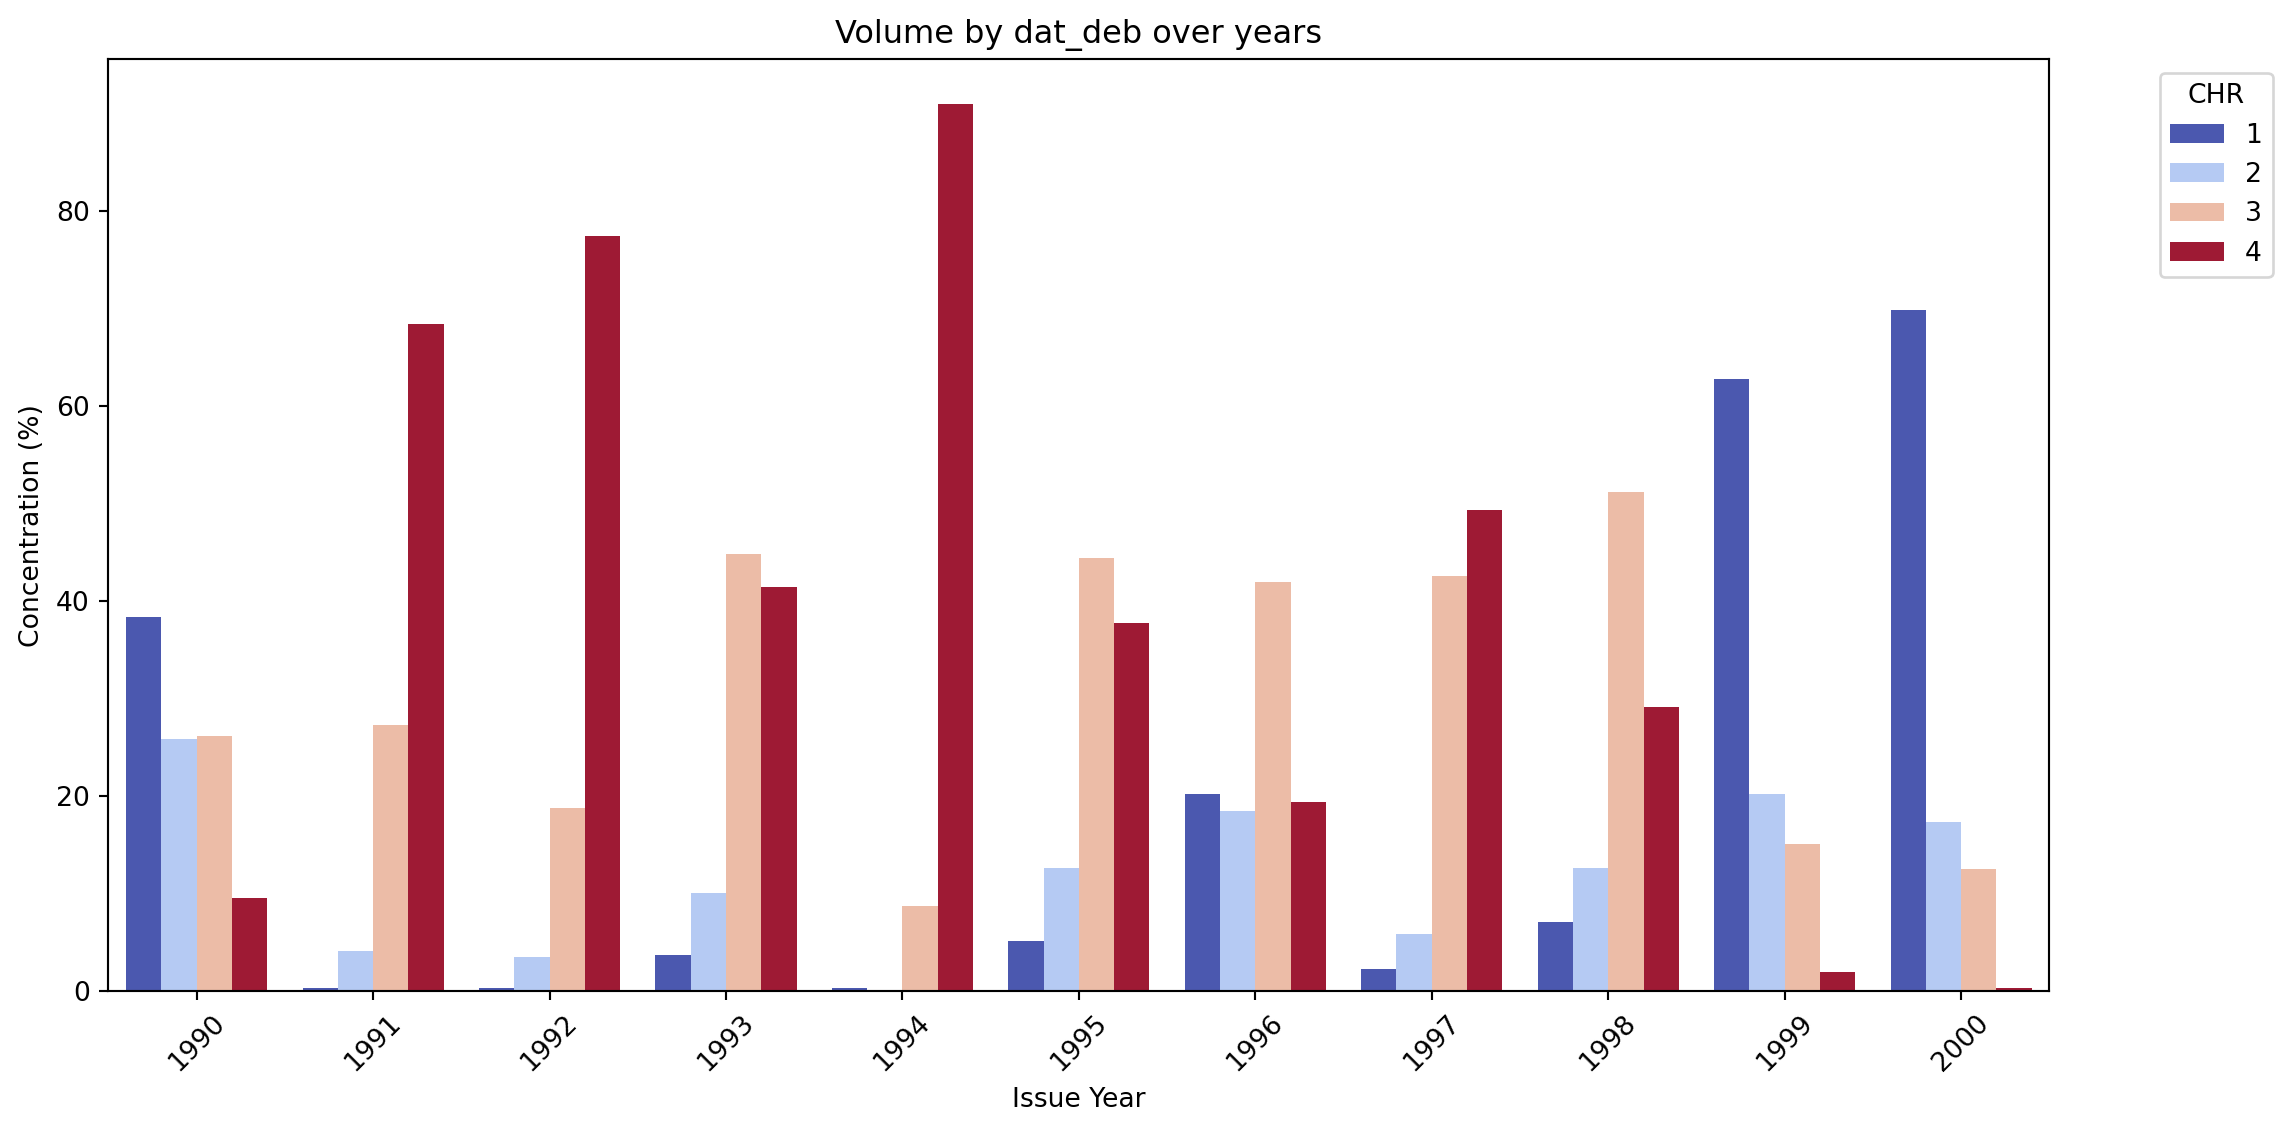

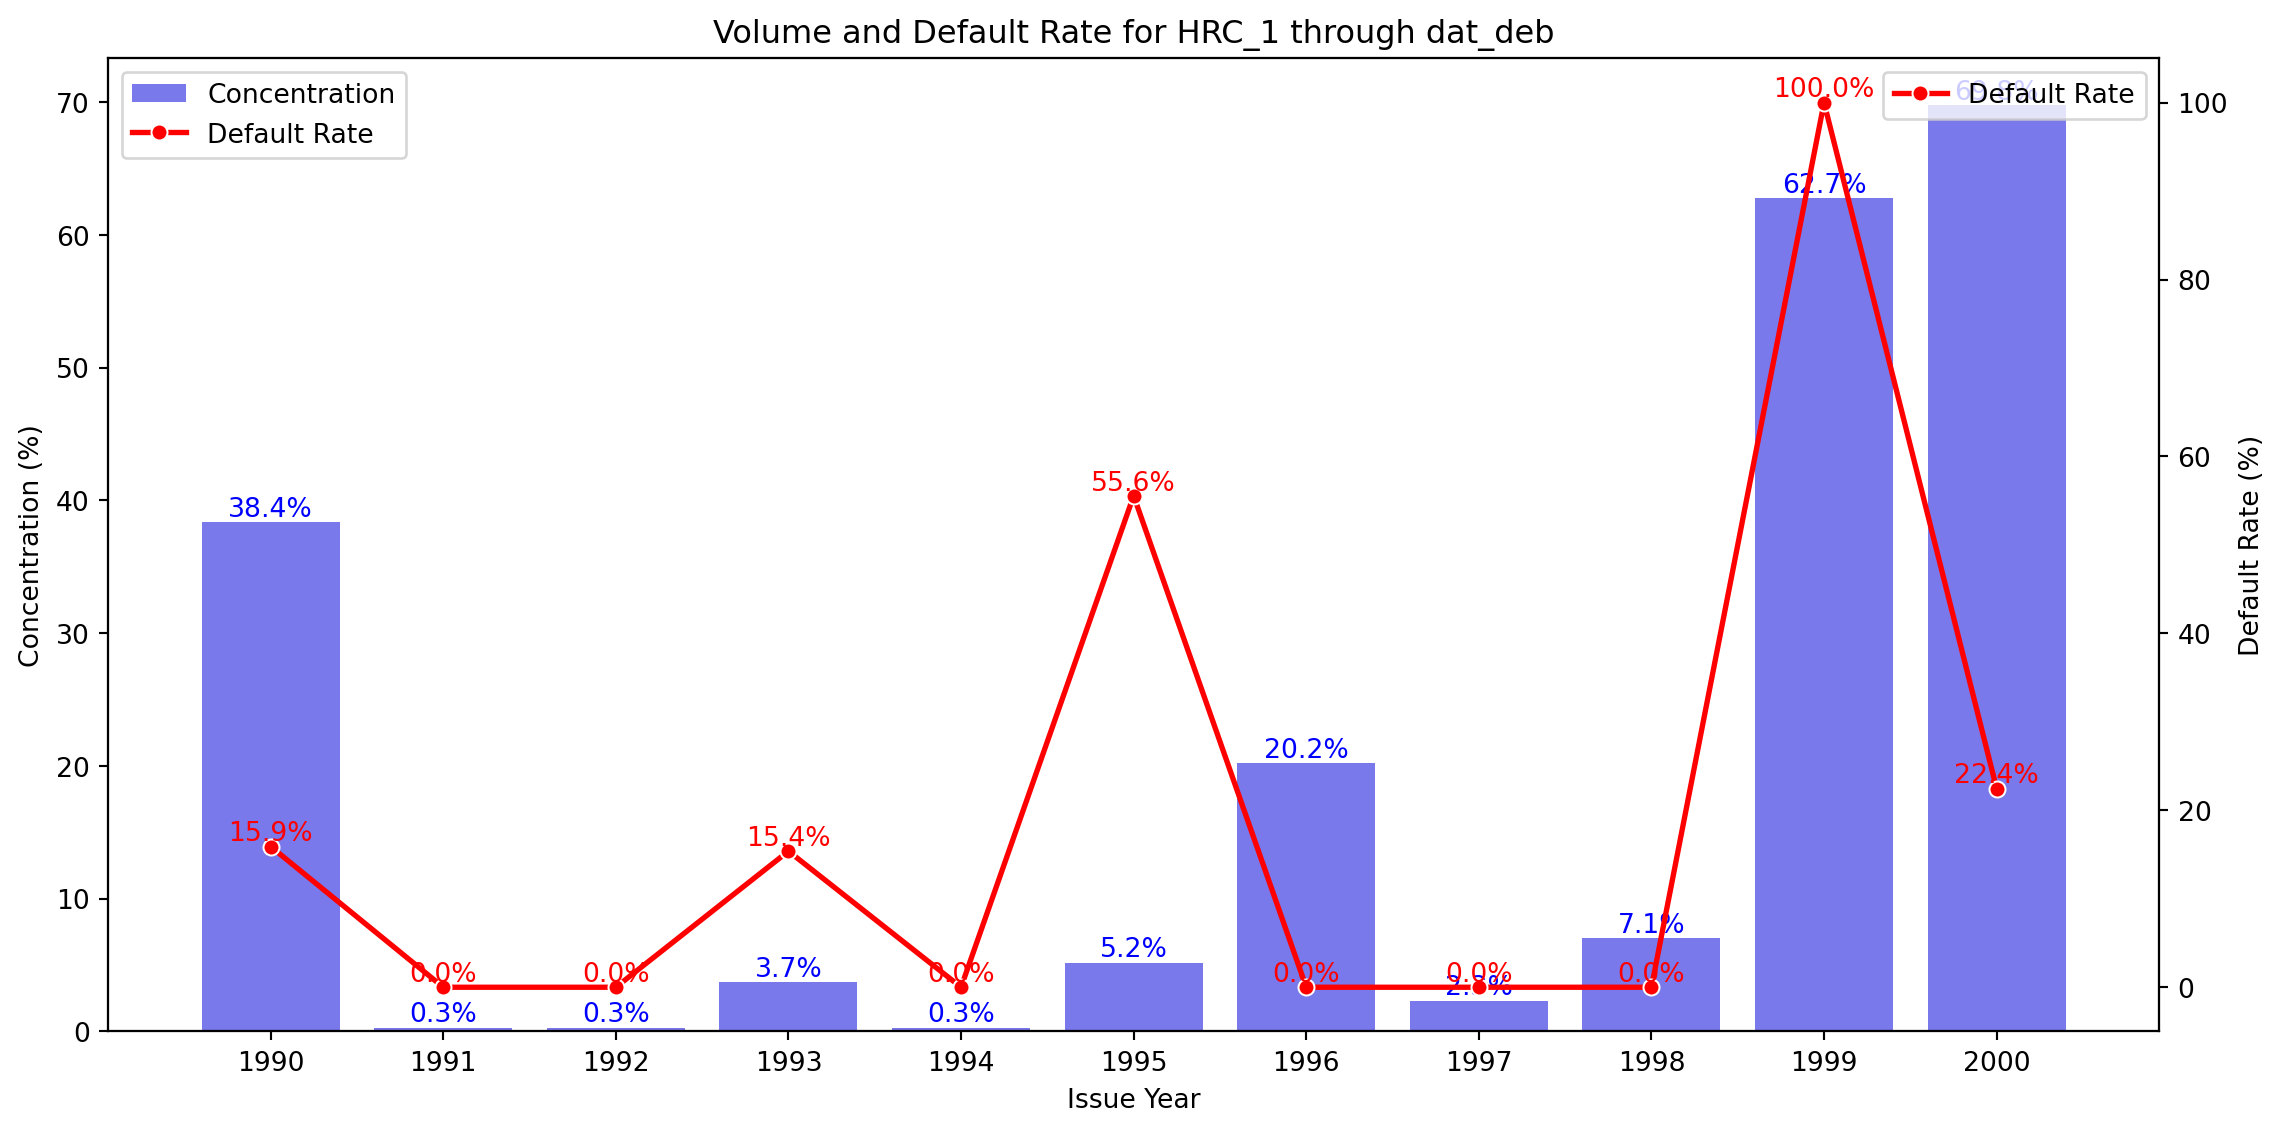

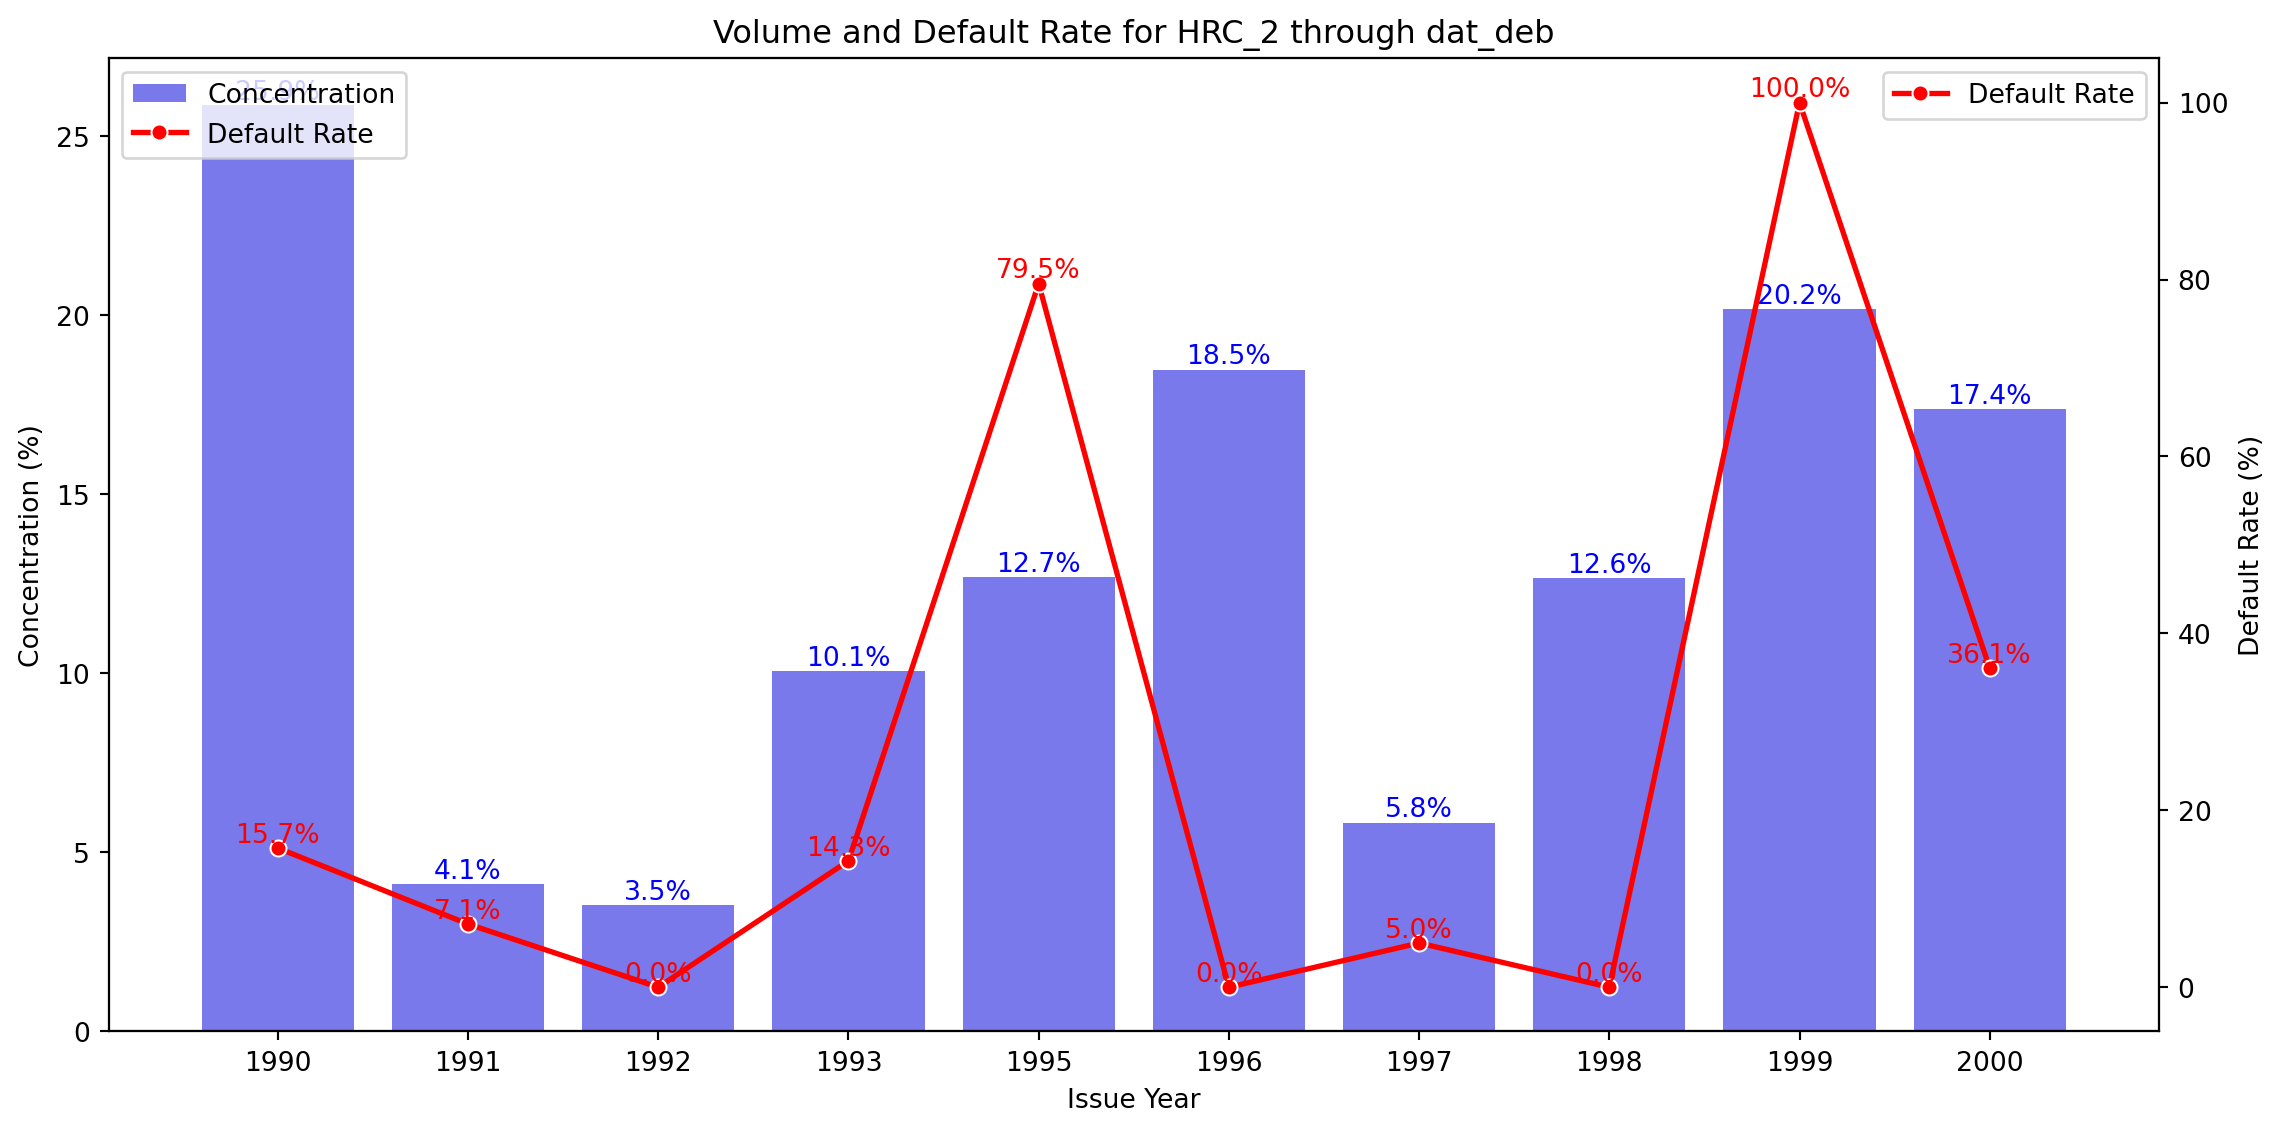

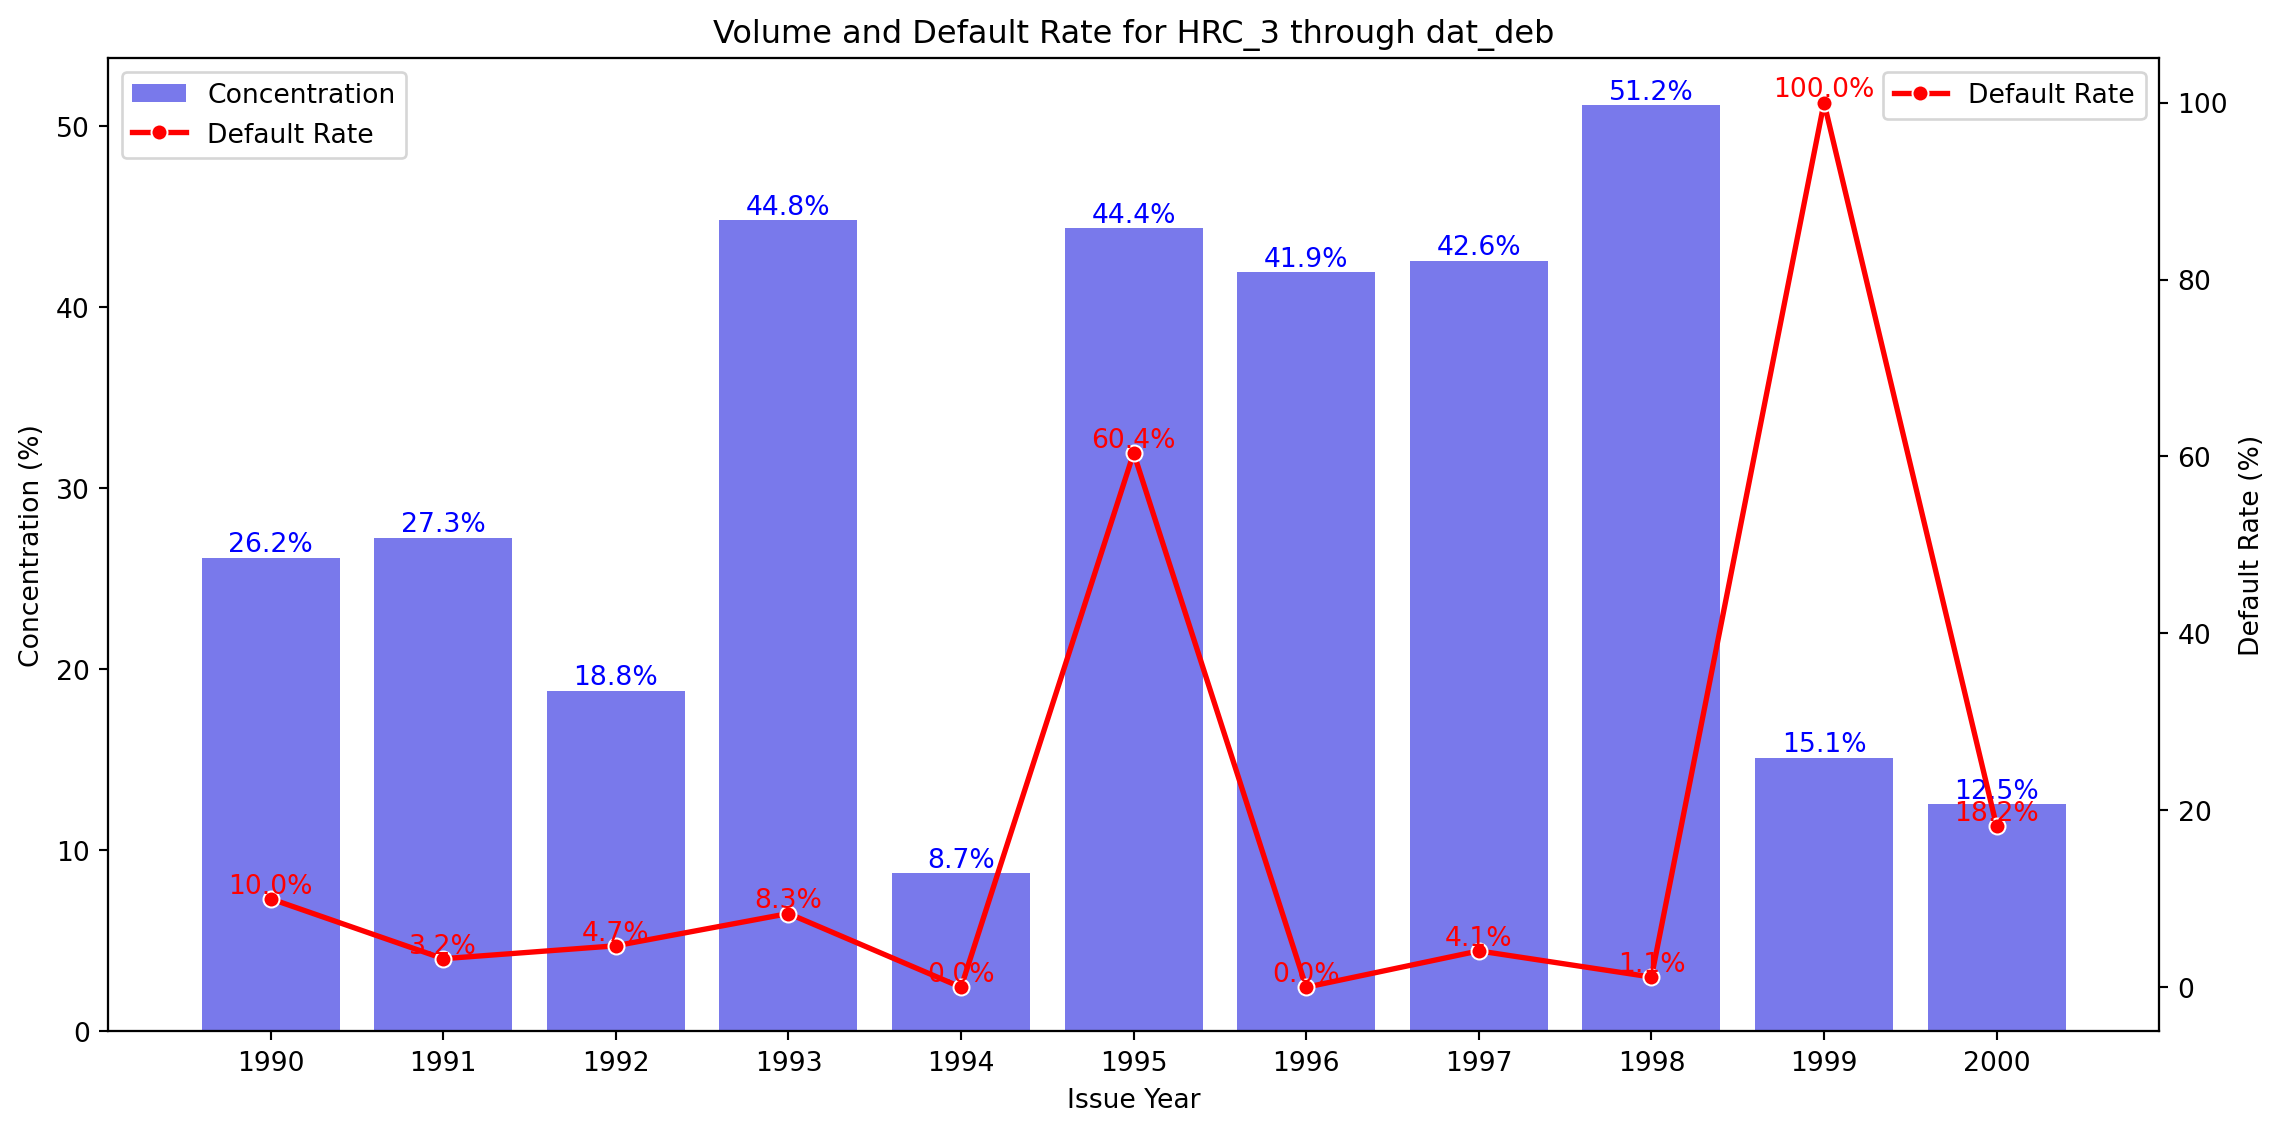

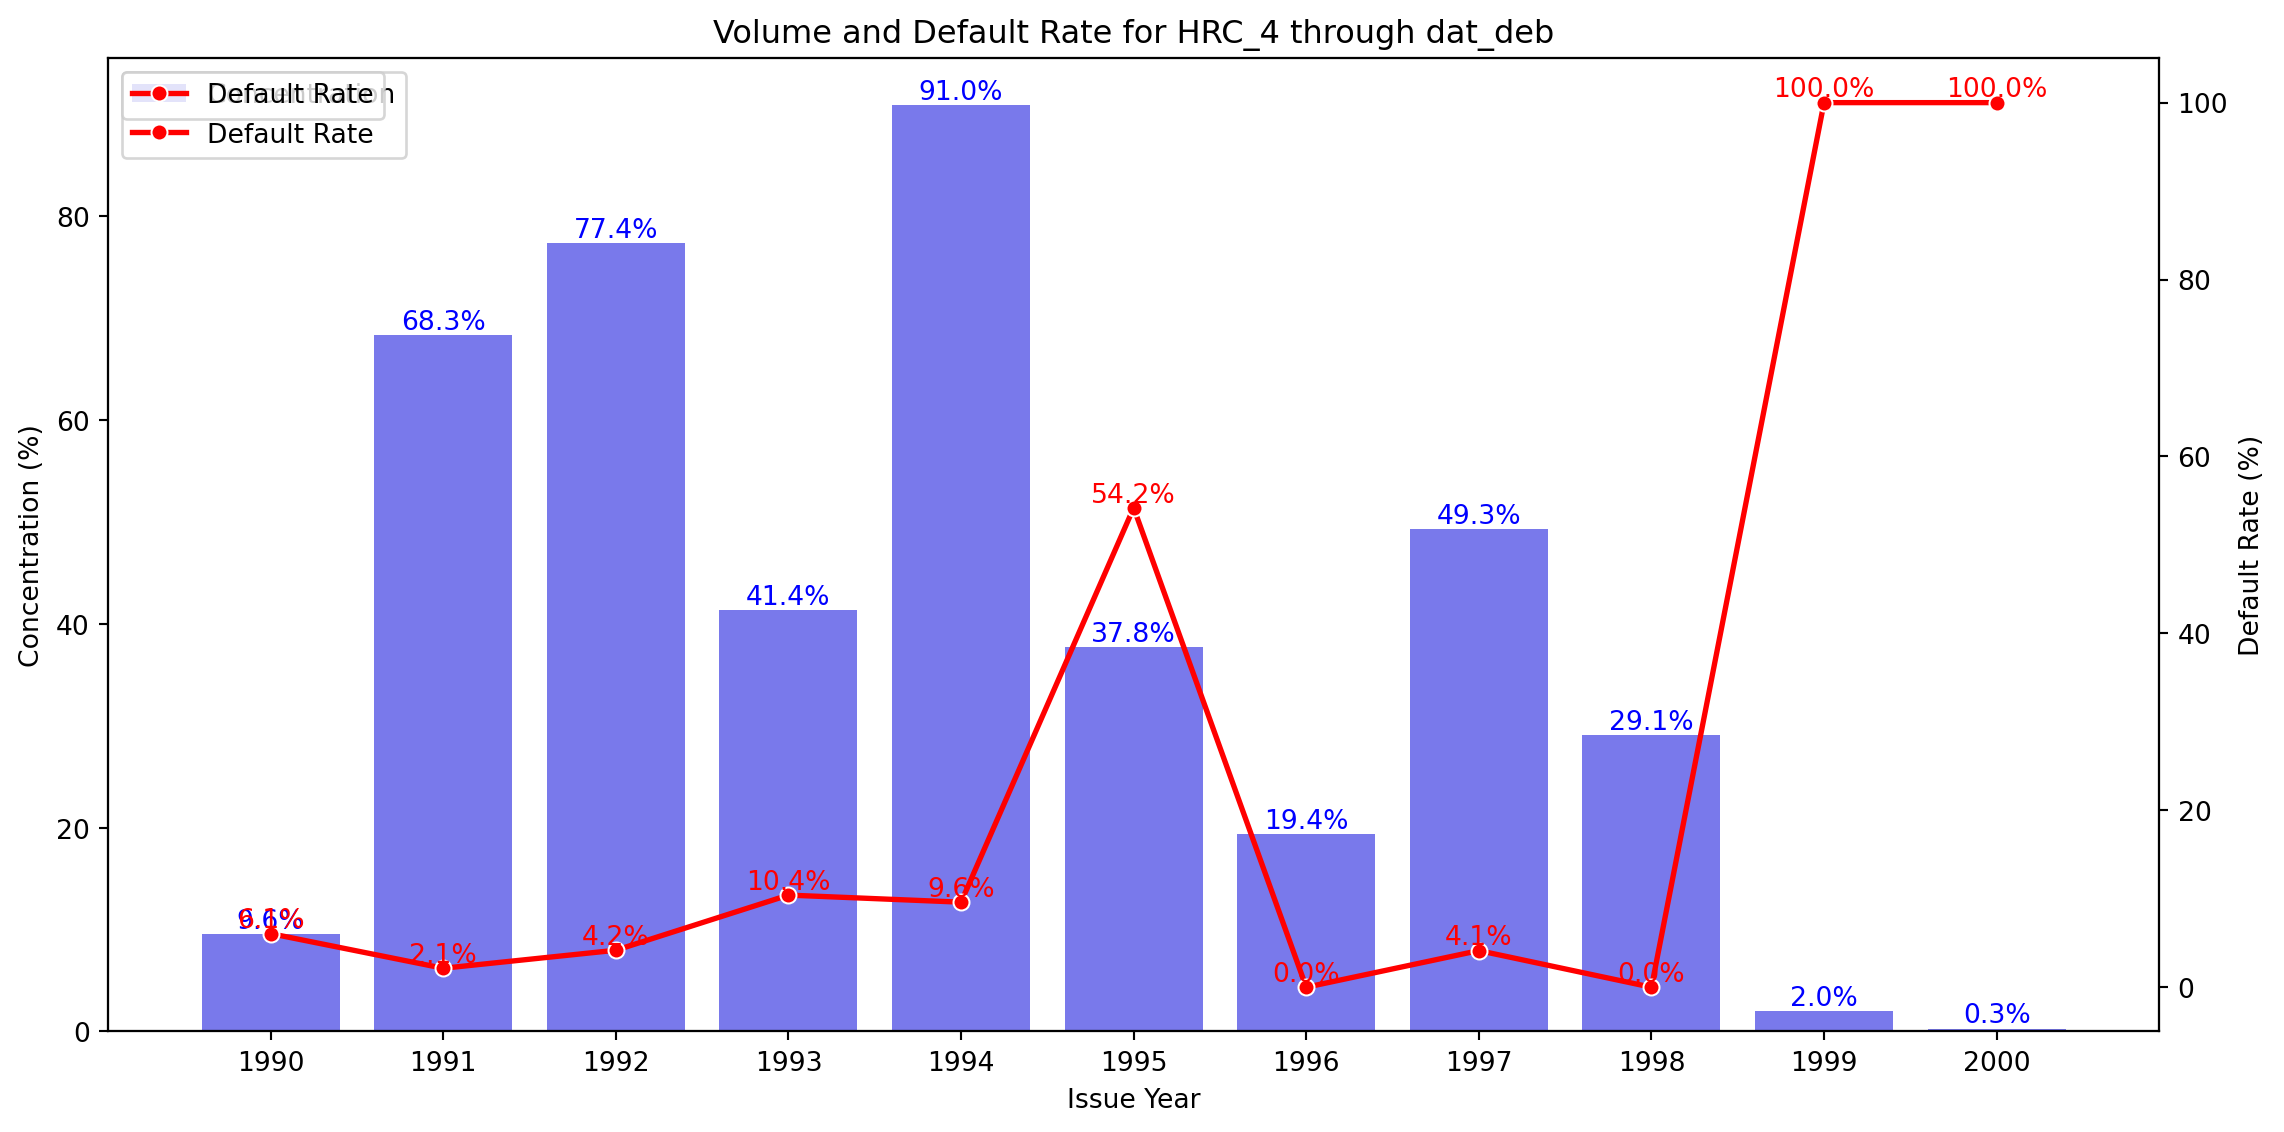

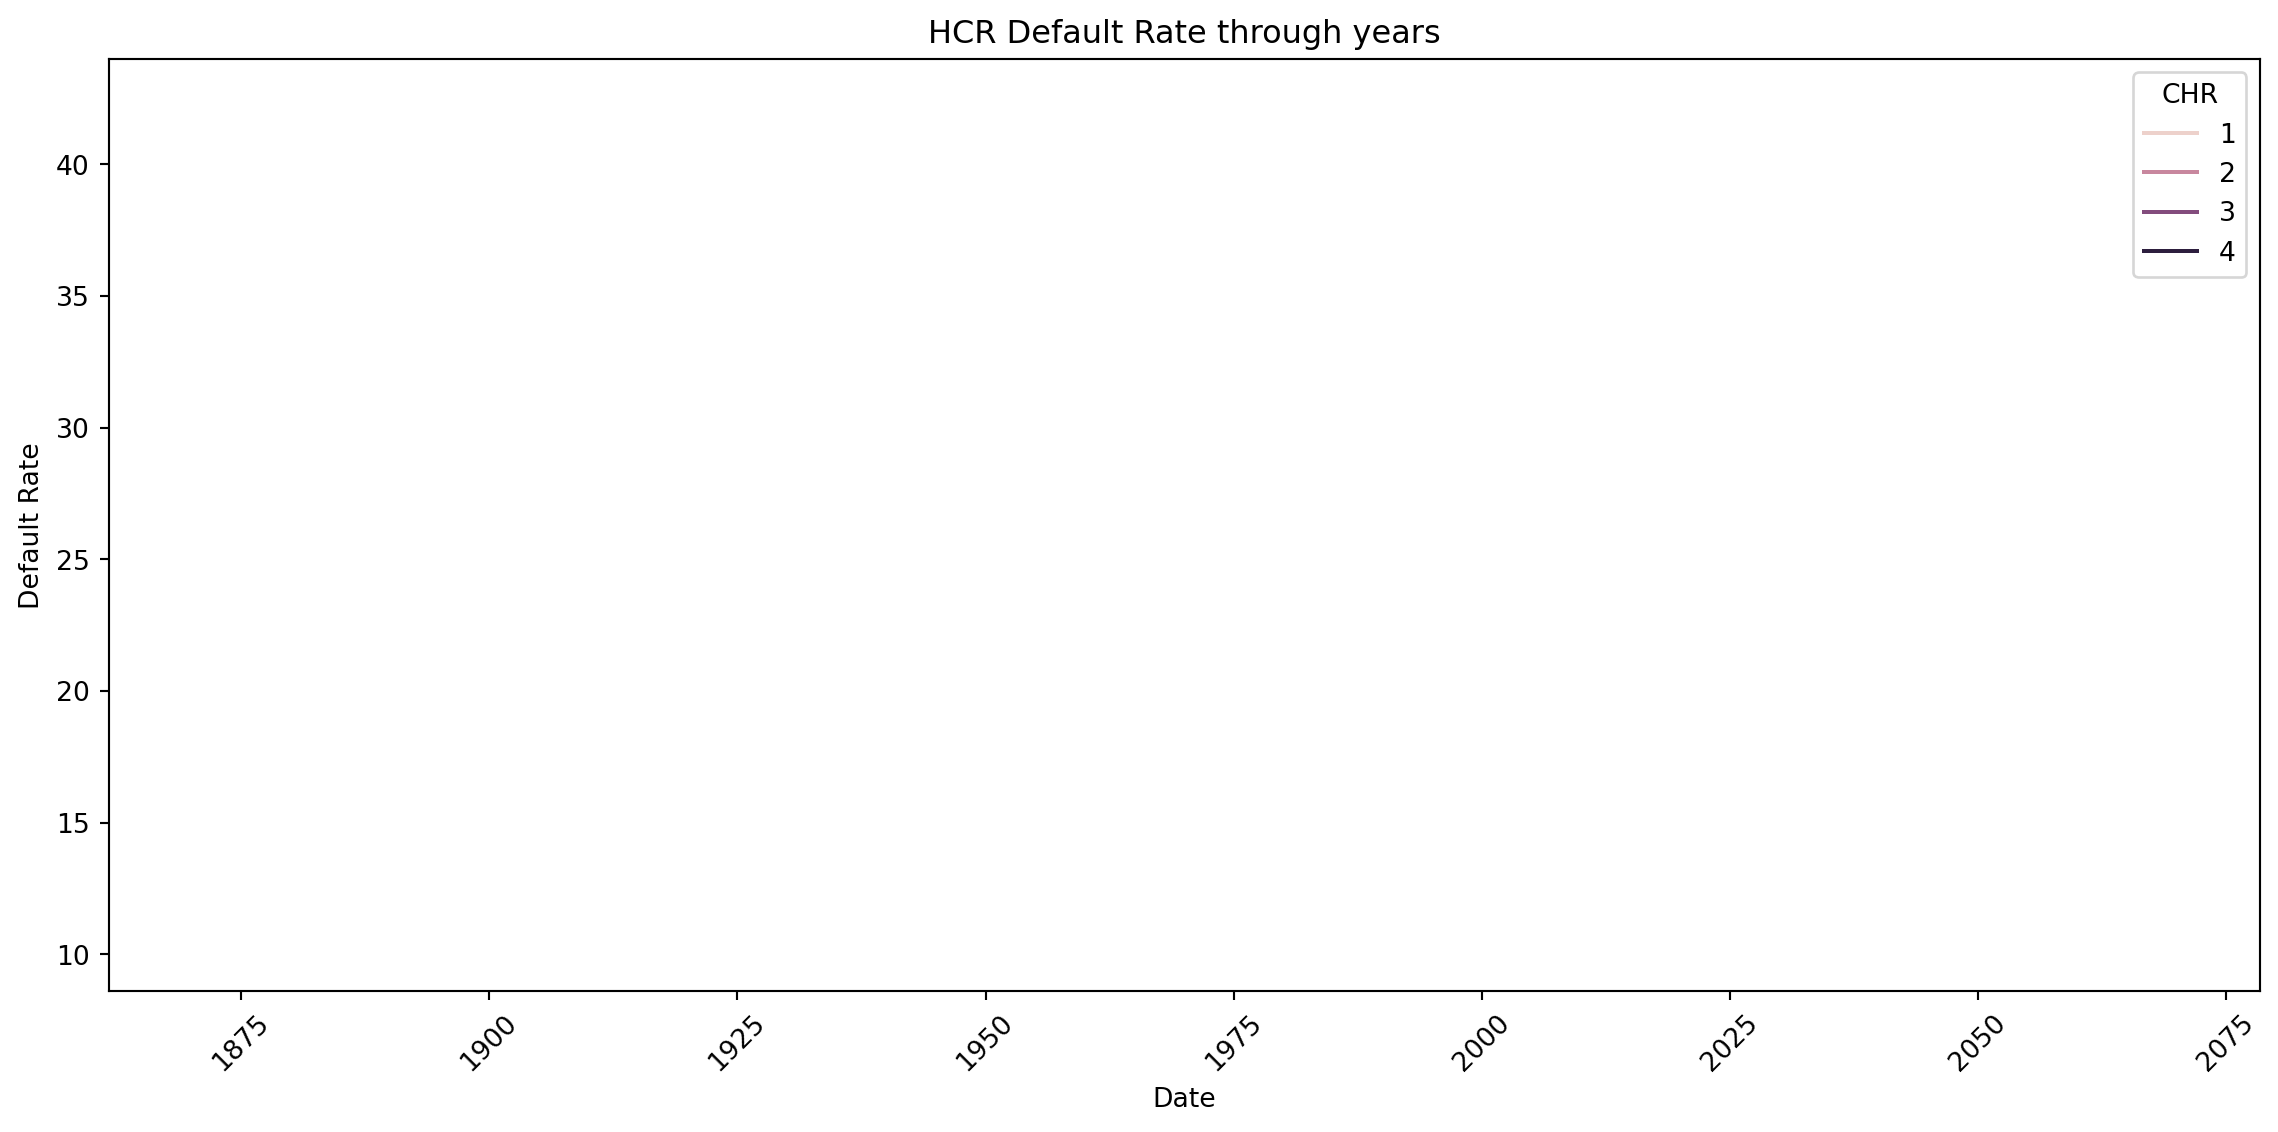

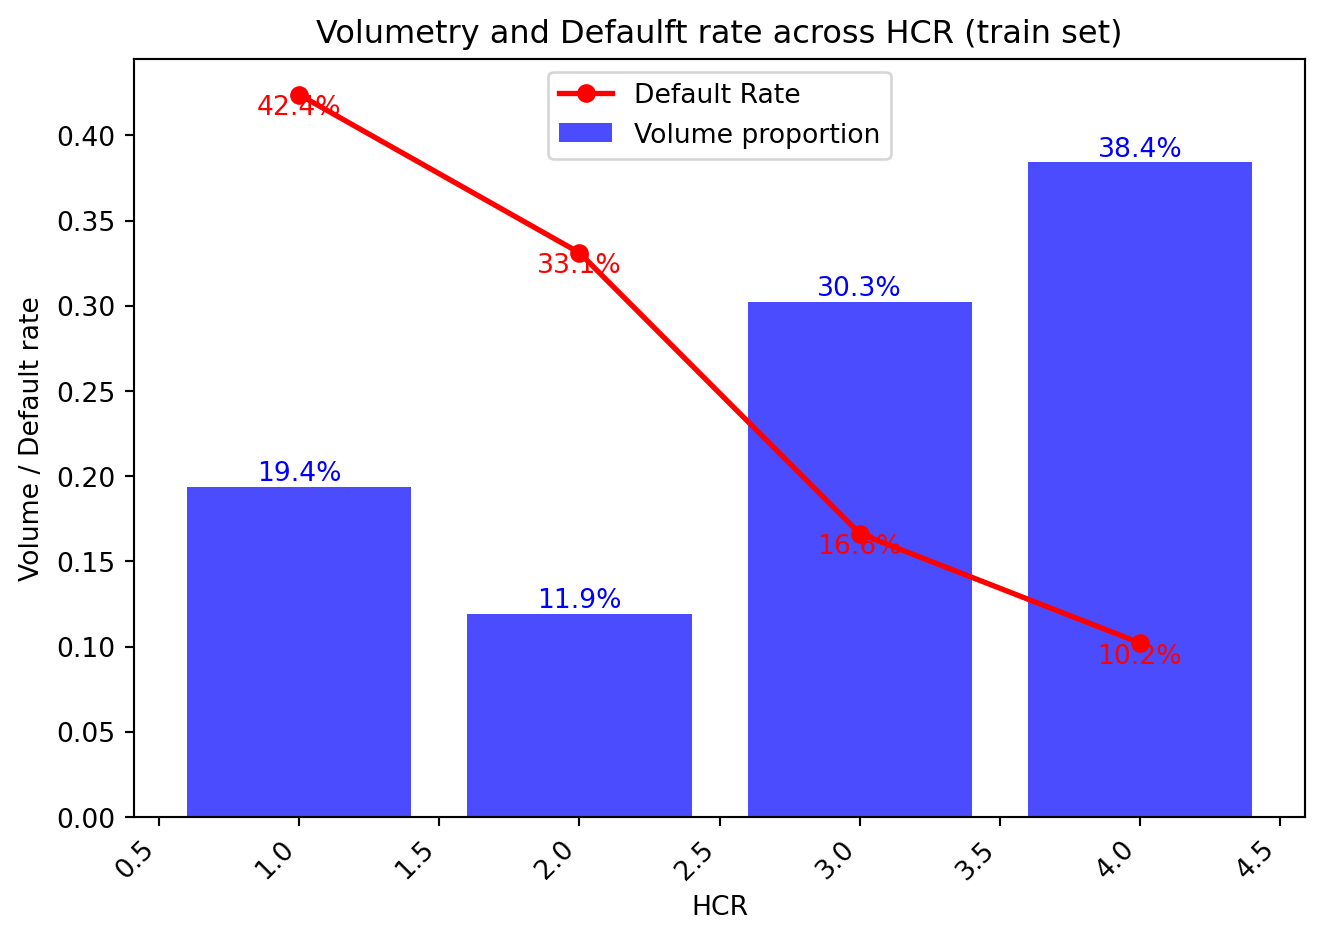

Optimal thresholds: 	[np.float64(7.415), 11.18, 11.68, 11.95, np.float64(15.375)]
     Default rate  Relatif deviation  Gini index  Shannon entropy
CHR                                                              
4        0.102195                NaN    0.183502         0.329879
3        0.166376          62.803124    0.277390         0.450094
2        0.331126          99.022225    0.442963         0.634973
1        0.423913          28.021739    0.488422         0.681524


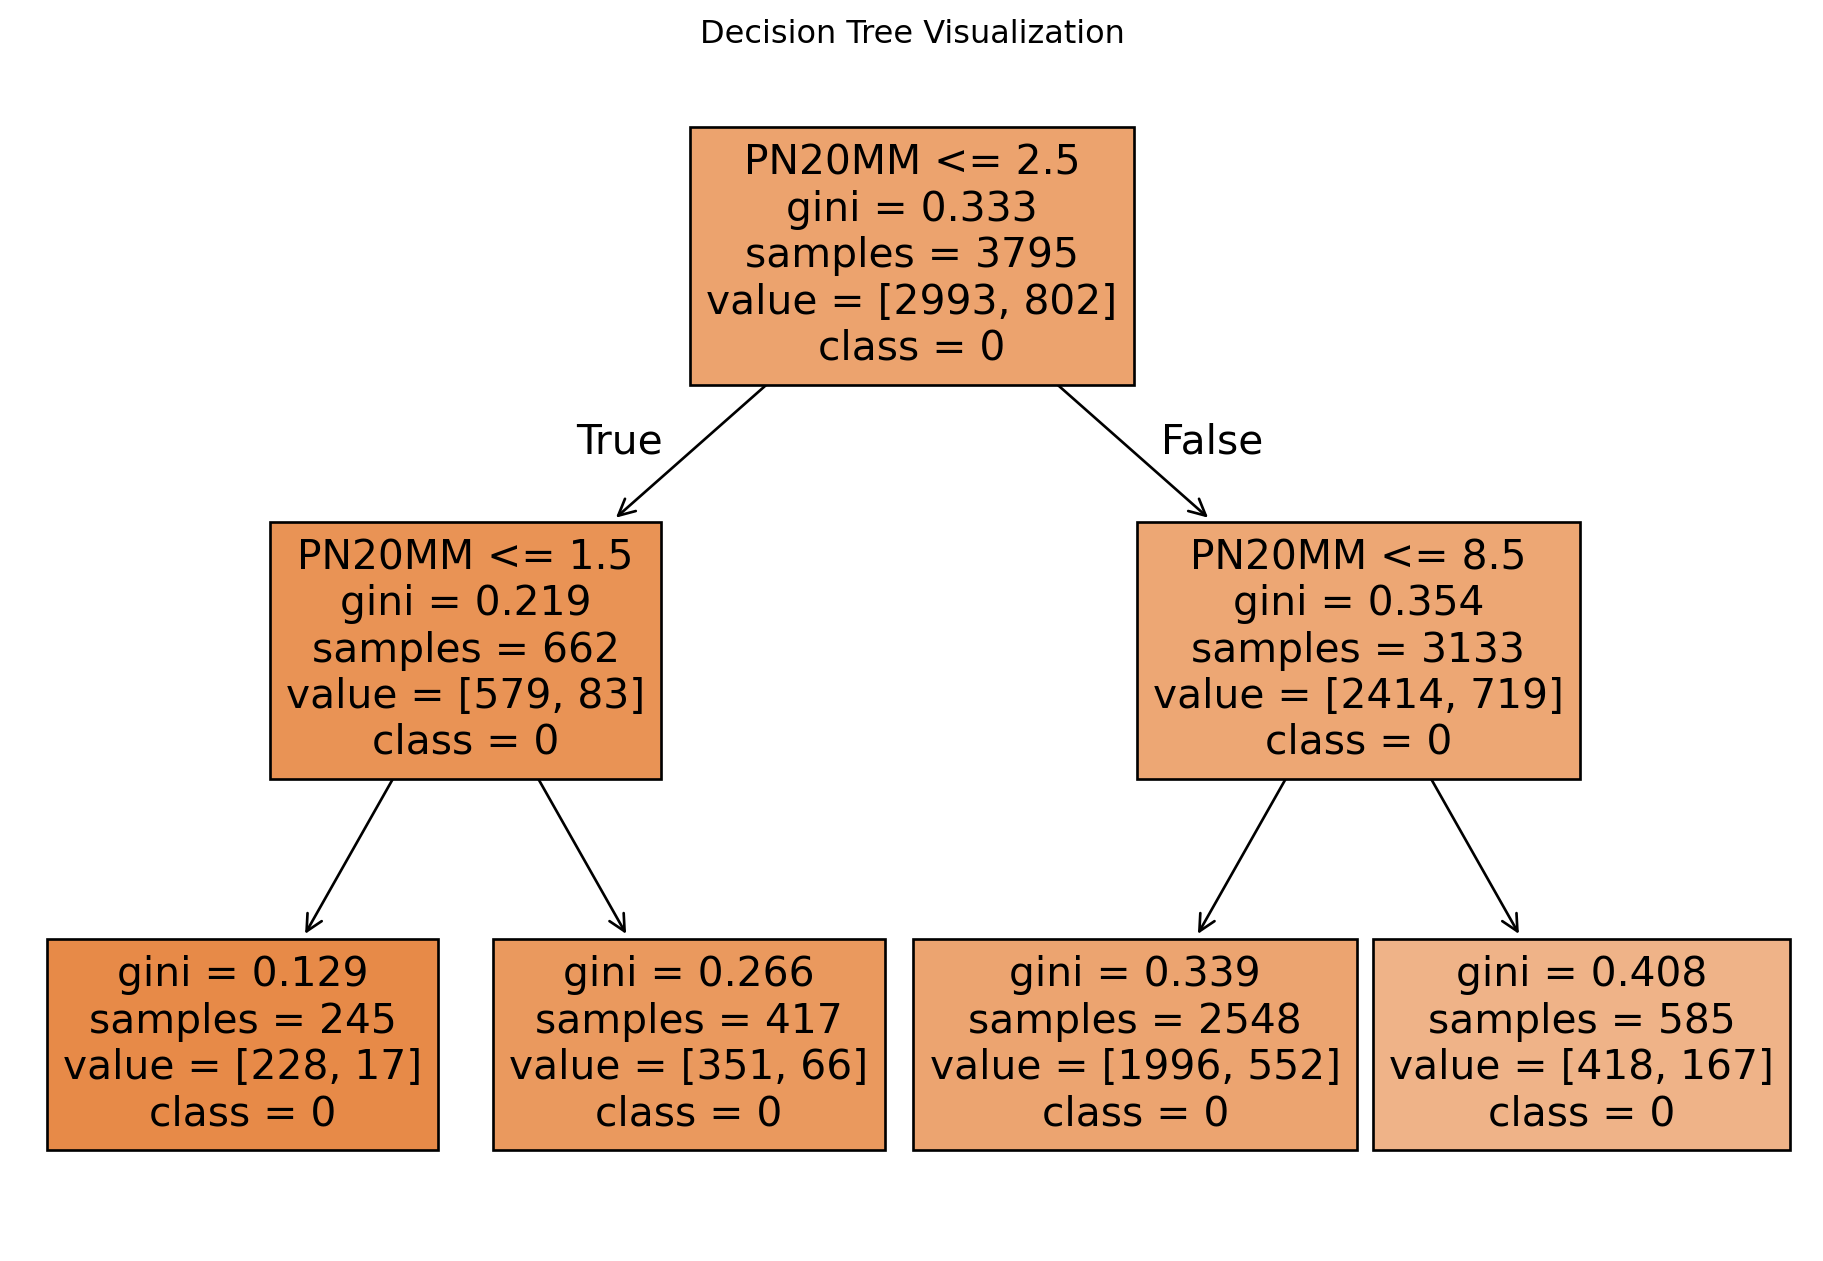

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3037785039.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(


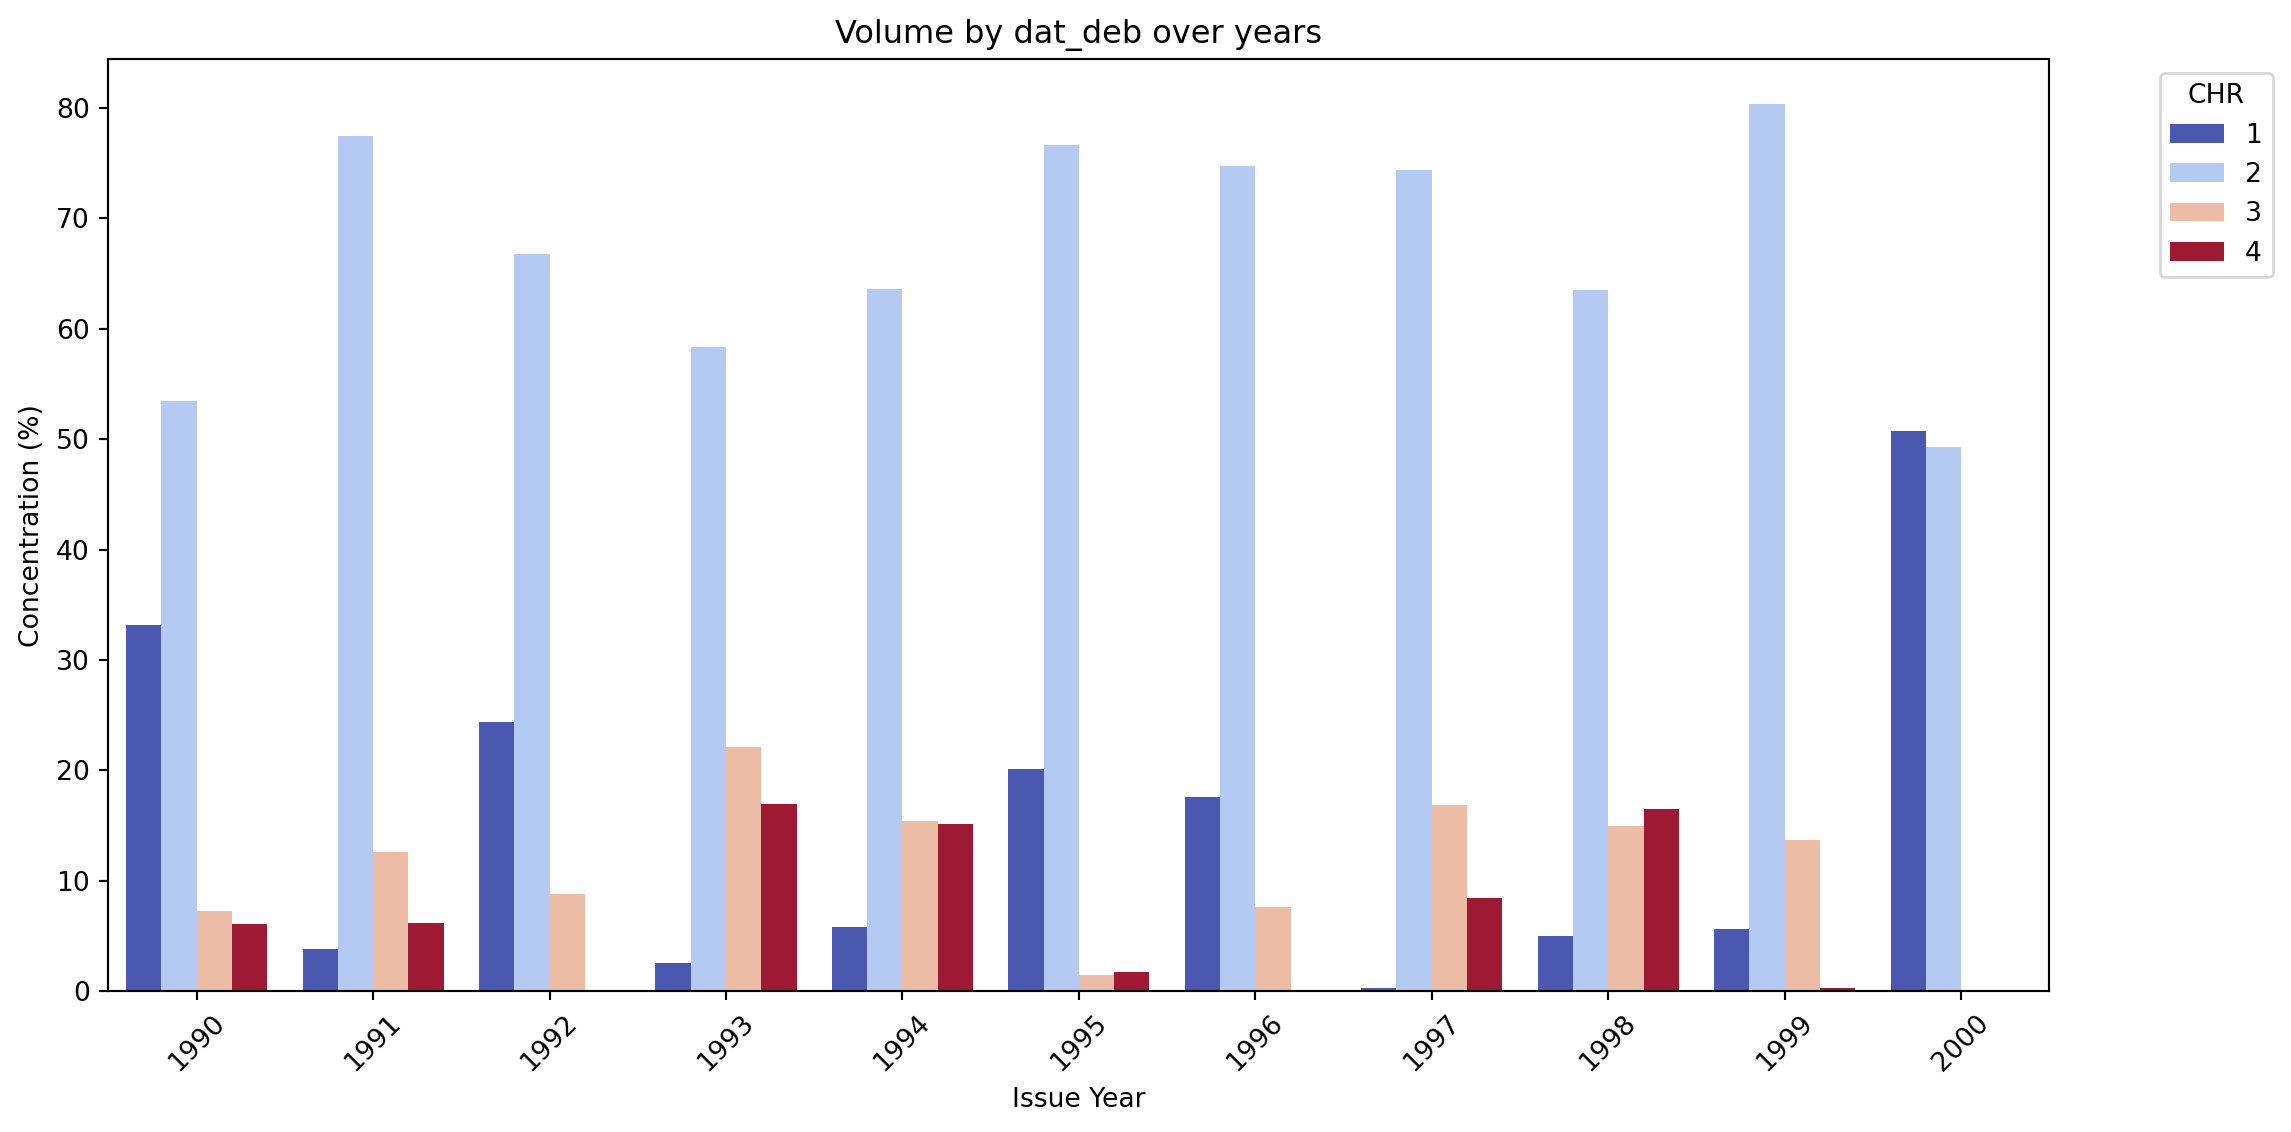

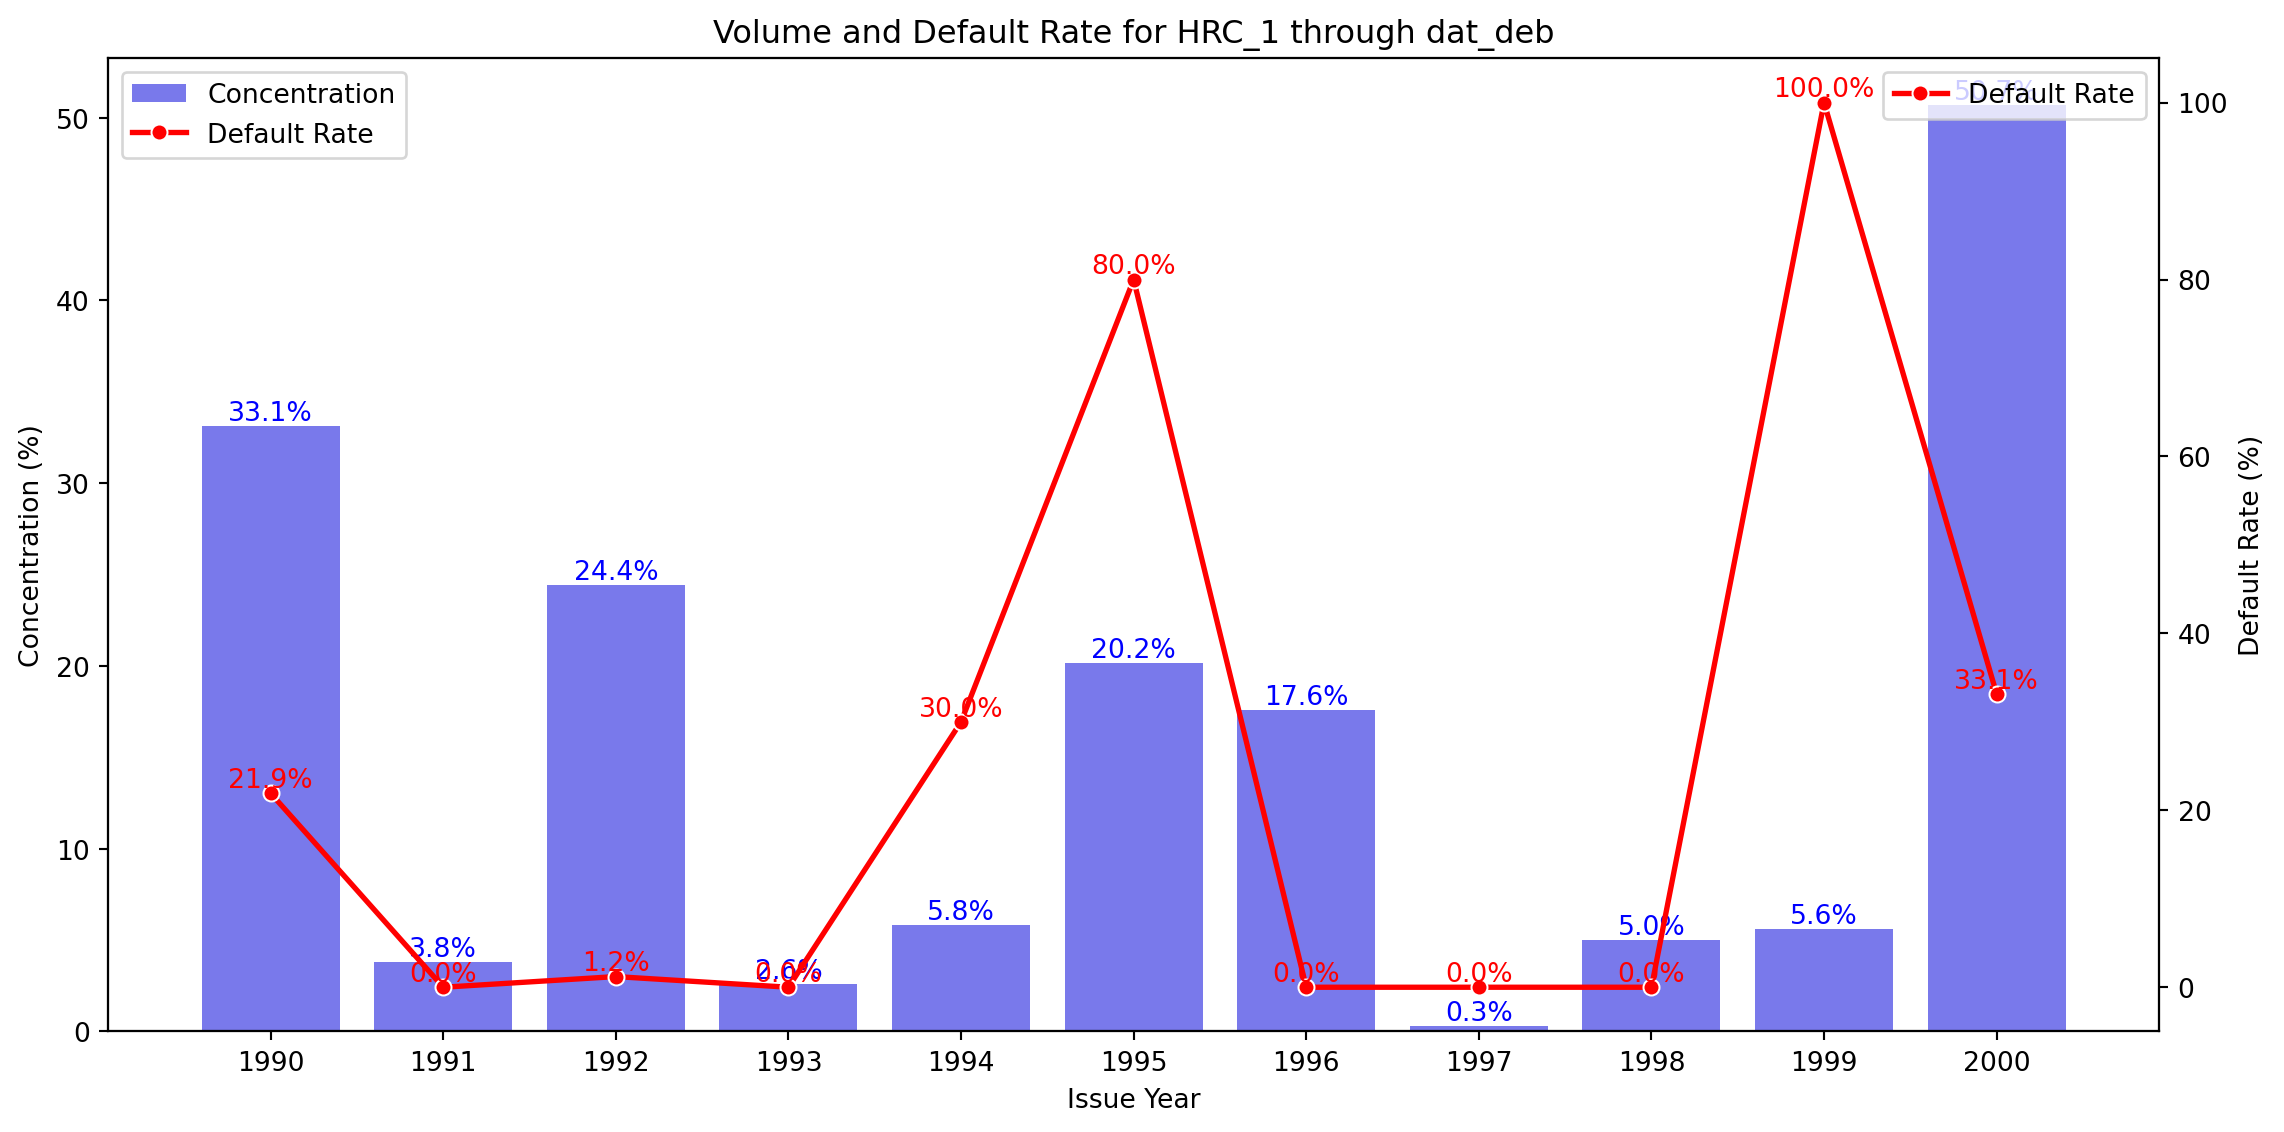

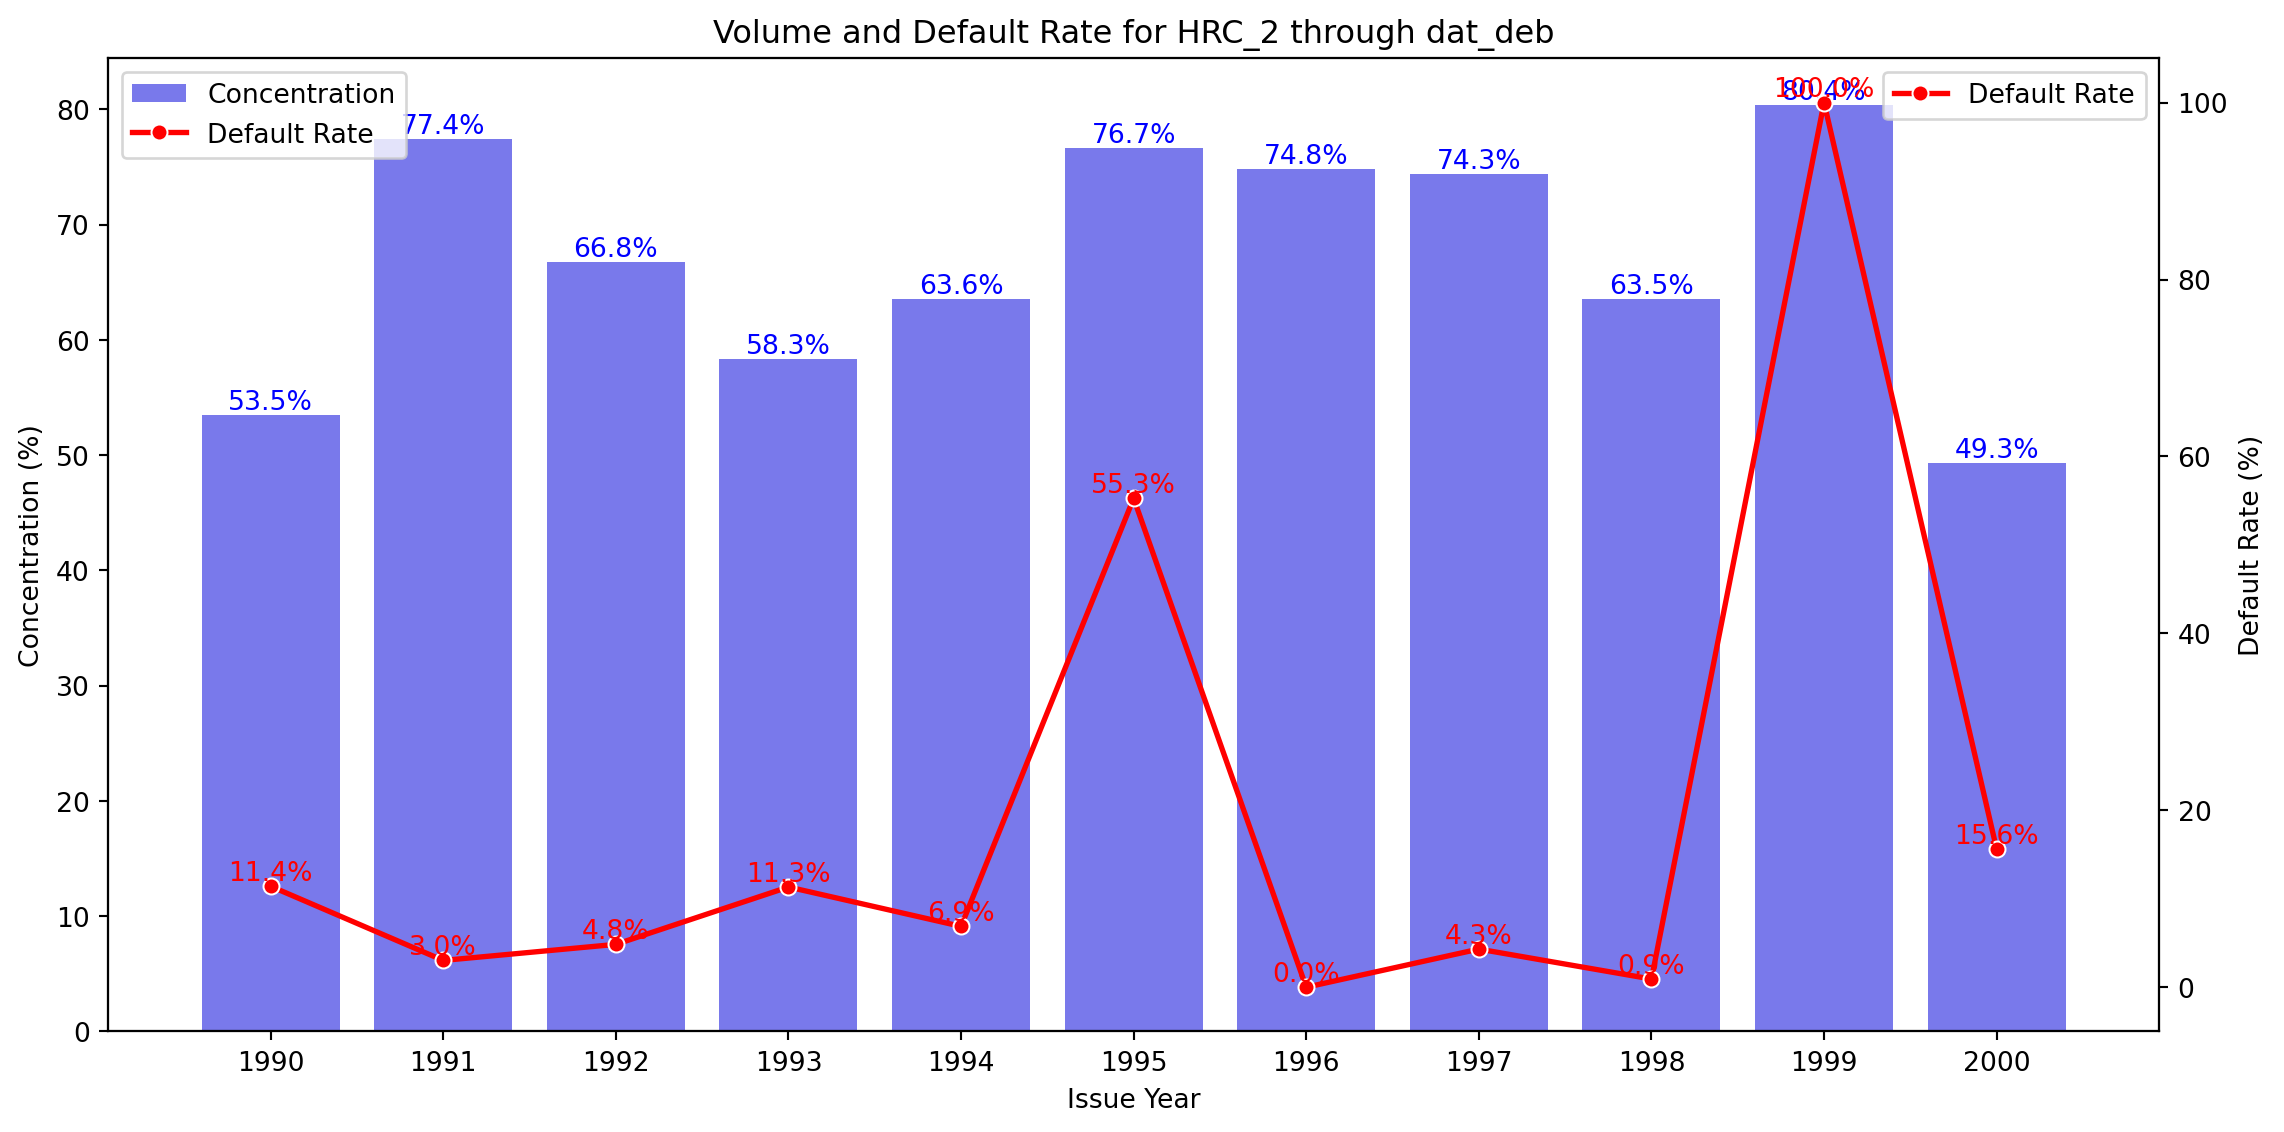

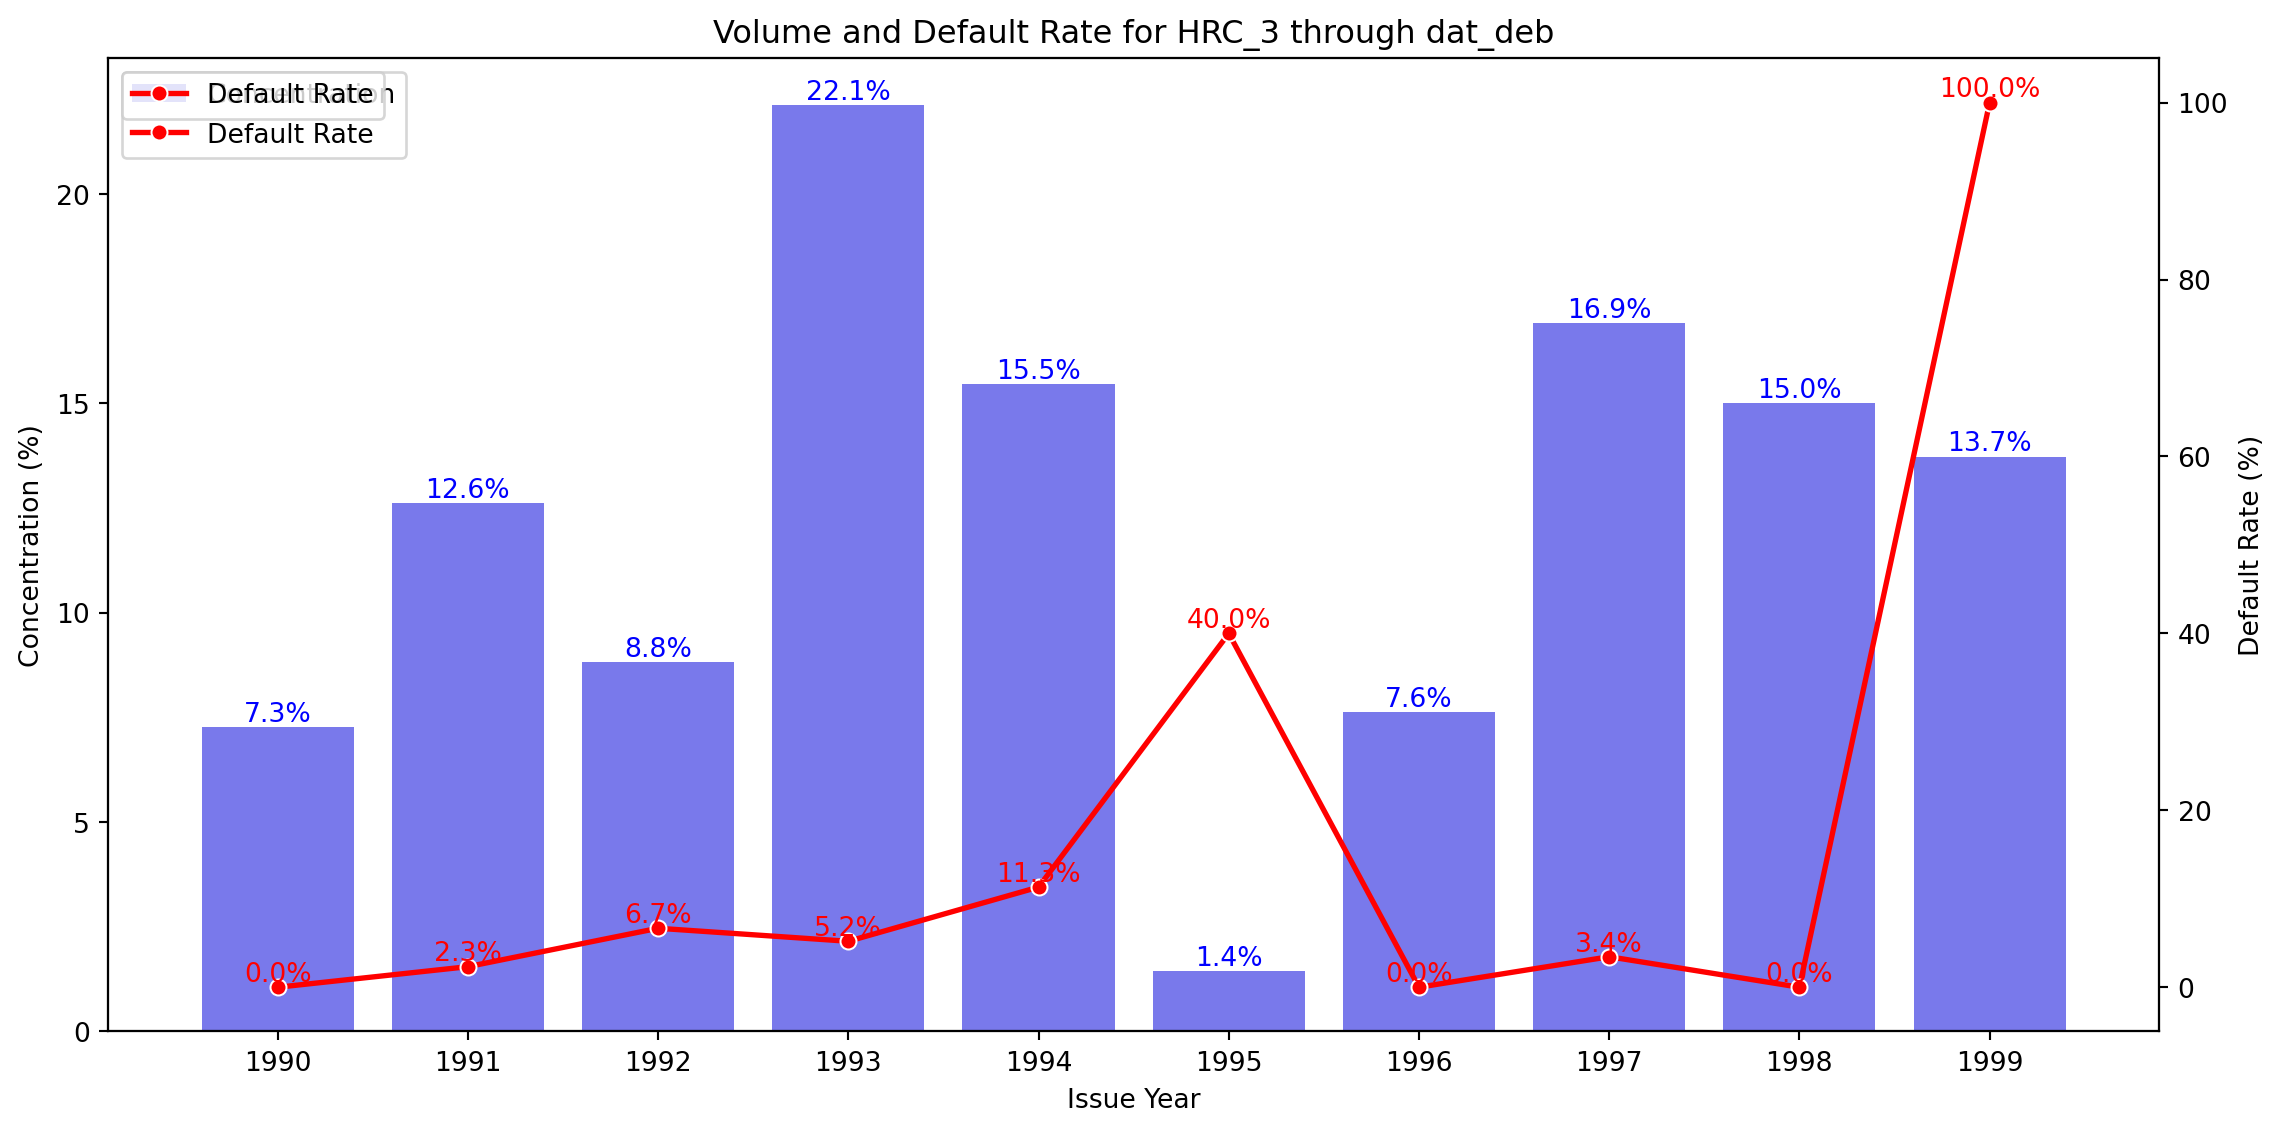

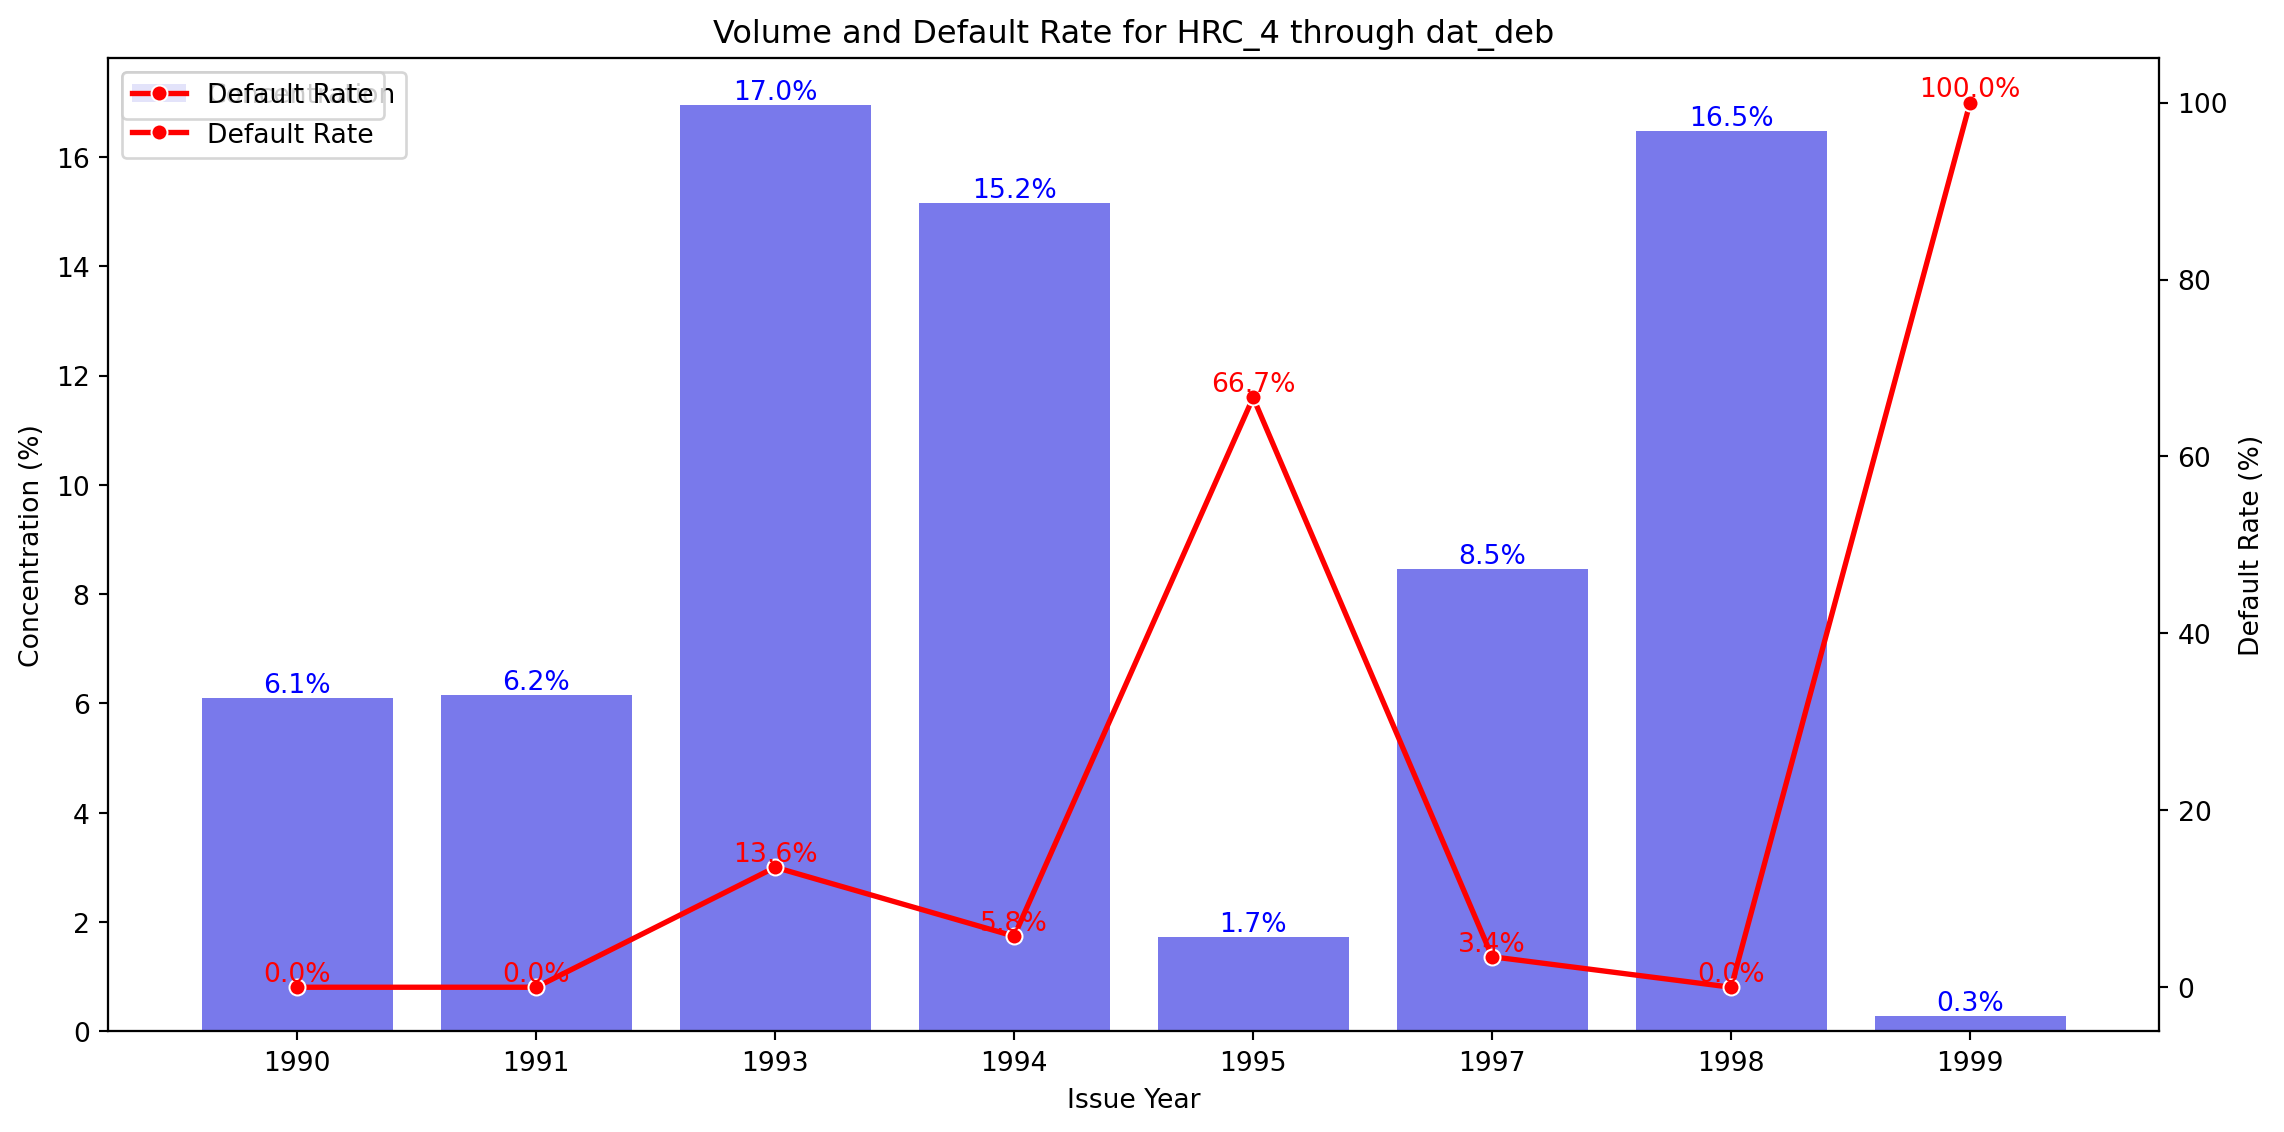

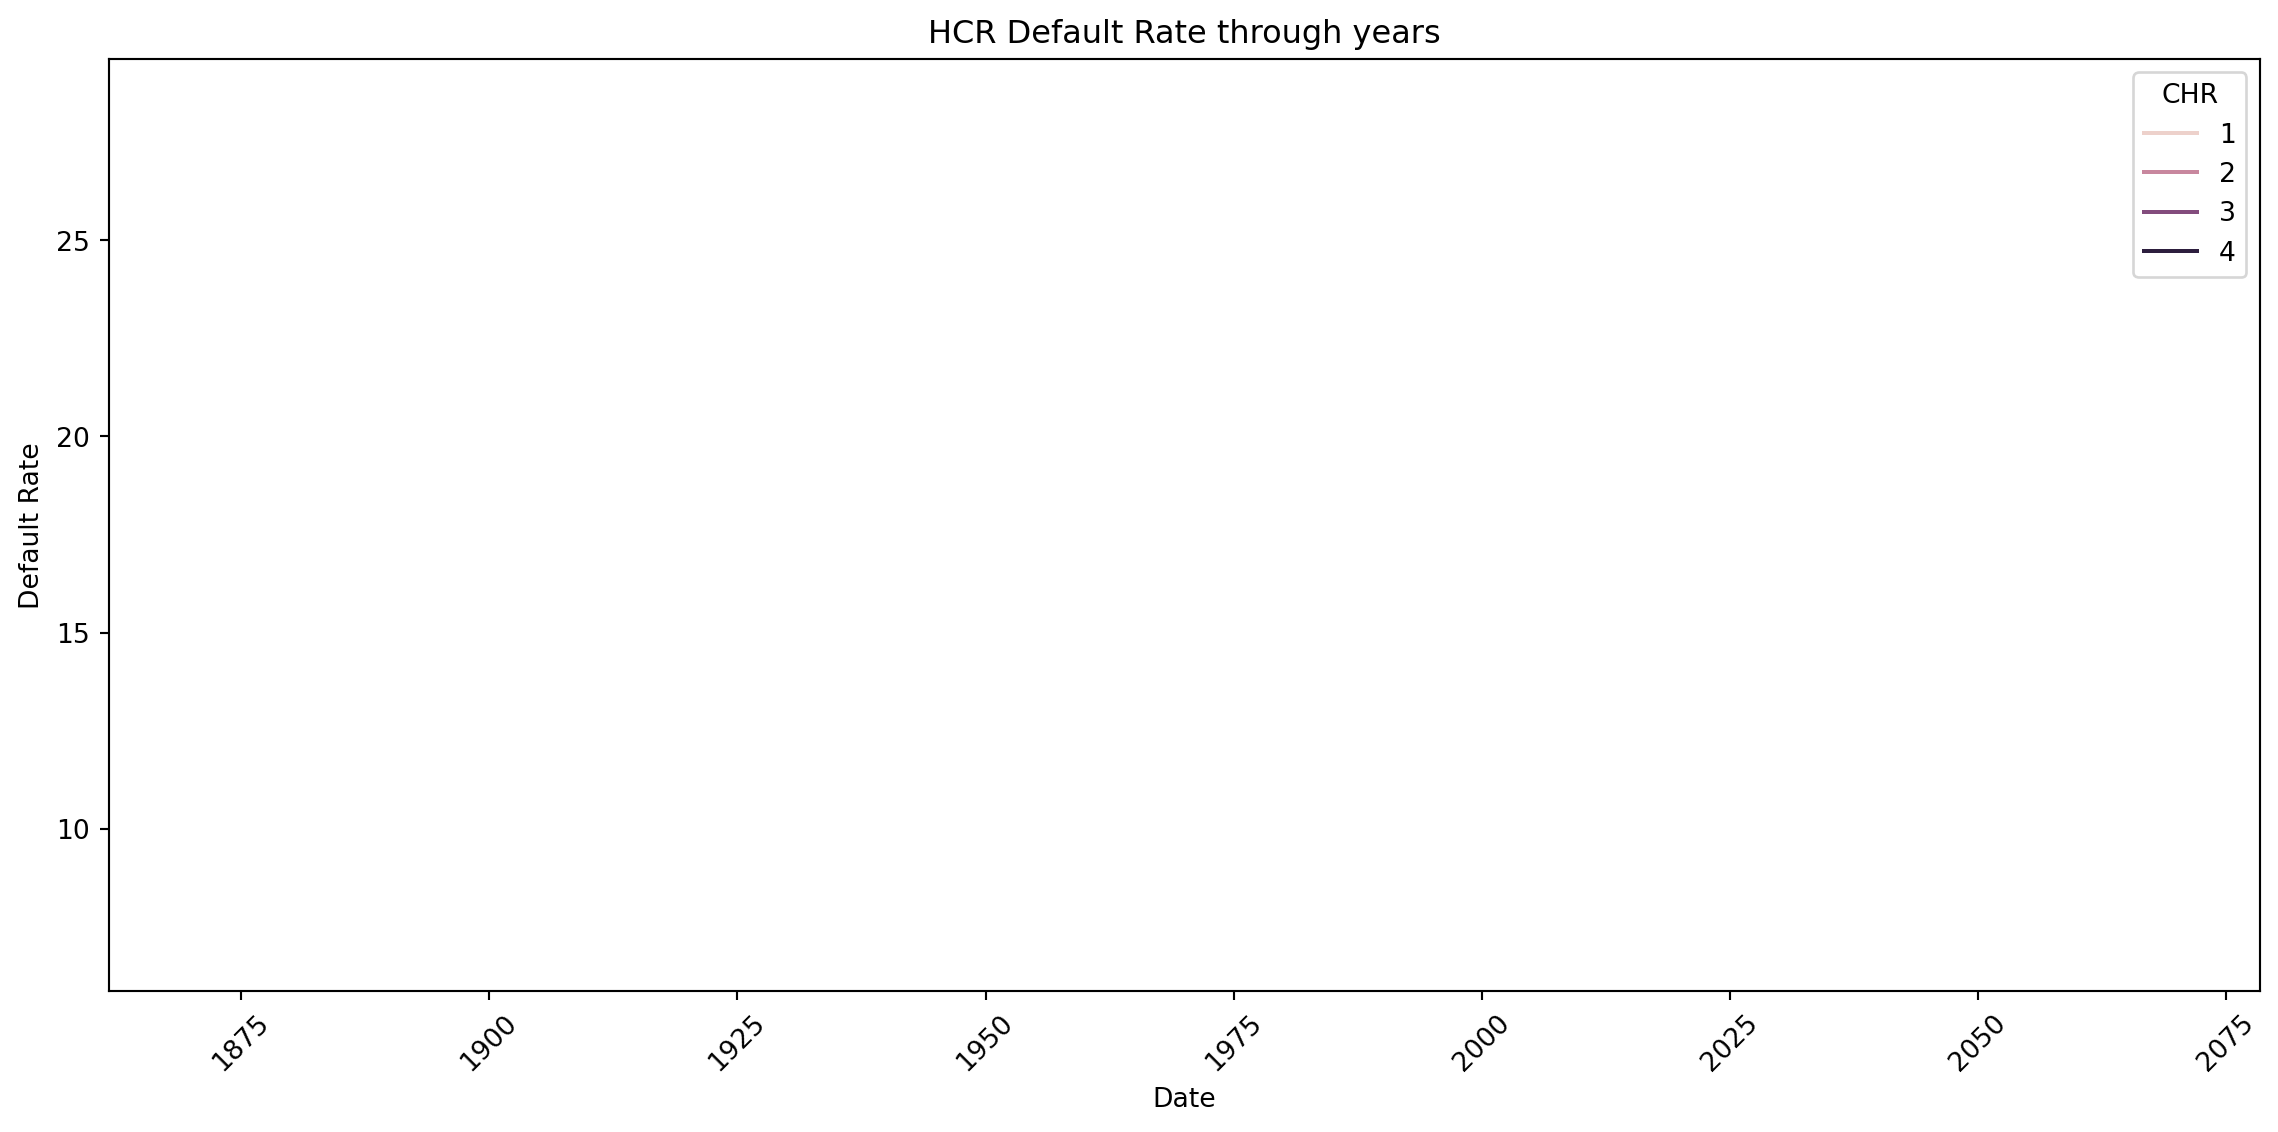

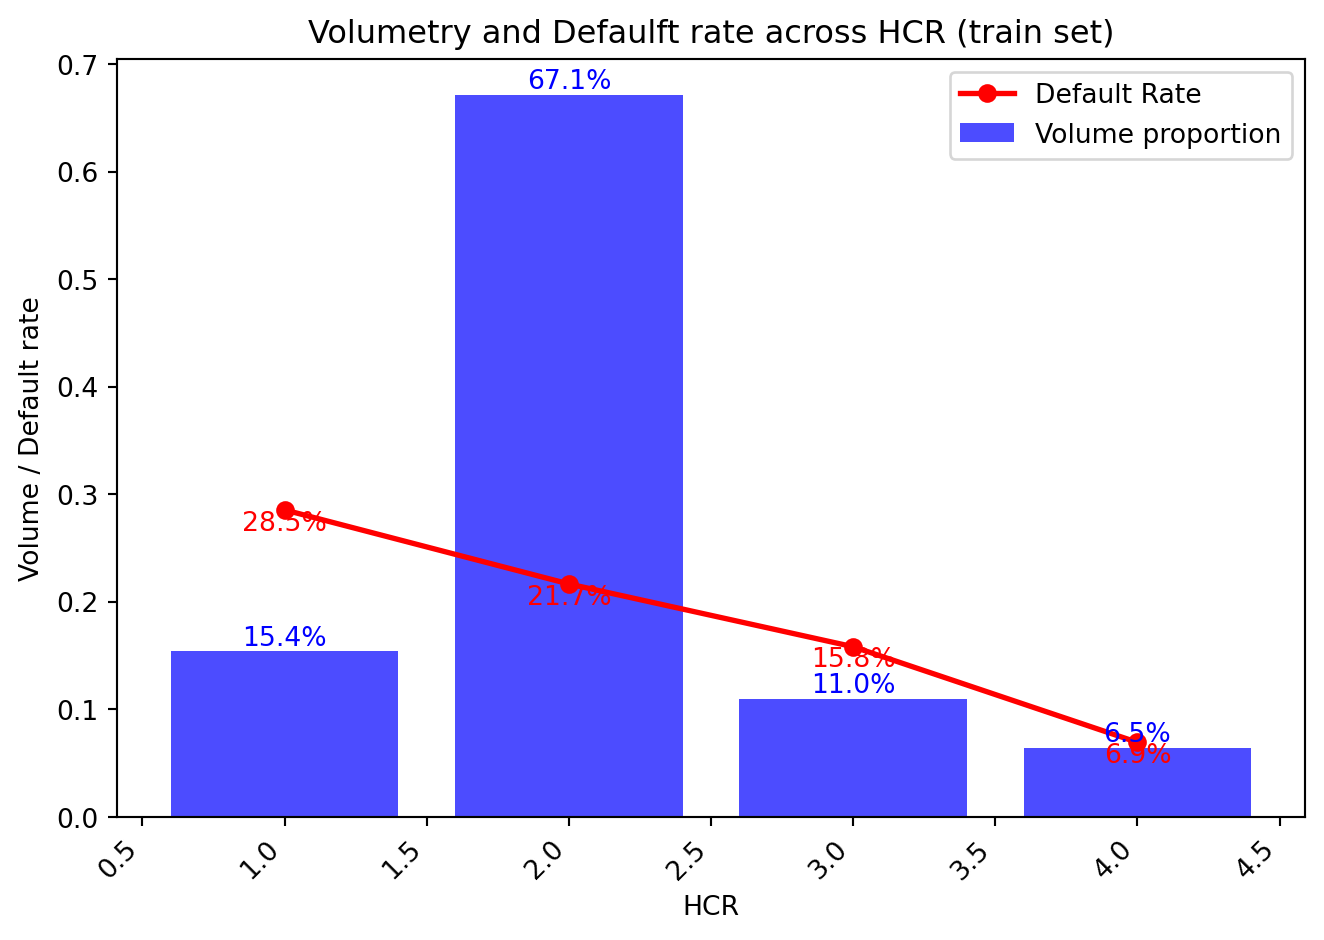

Optimal thresholds: 	[np.float64(-15.5), 1.5, 2.5, 8.5, np.float64(28.5)]
     Default rate  Relatif deviation  Gini index  Shannon entropy
CHR                                                              
4        0.069388                NaN    0.129146         0.252052
3        0.158273         128.099873    0.266446         0.436796
2        0.216641          36.877408    0.339415         0.522623
1        0.285470          31.771337    0.407954         0.598046


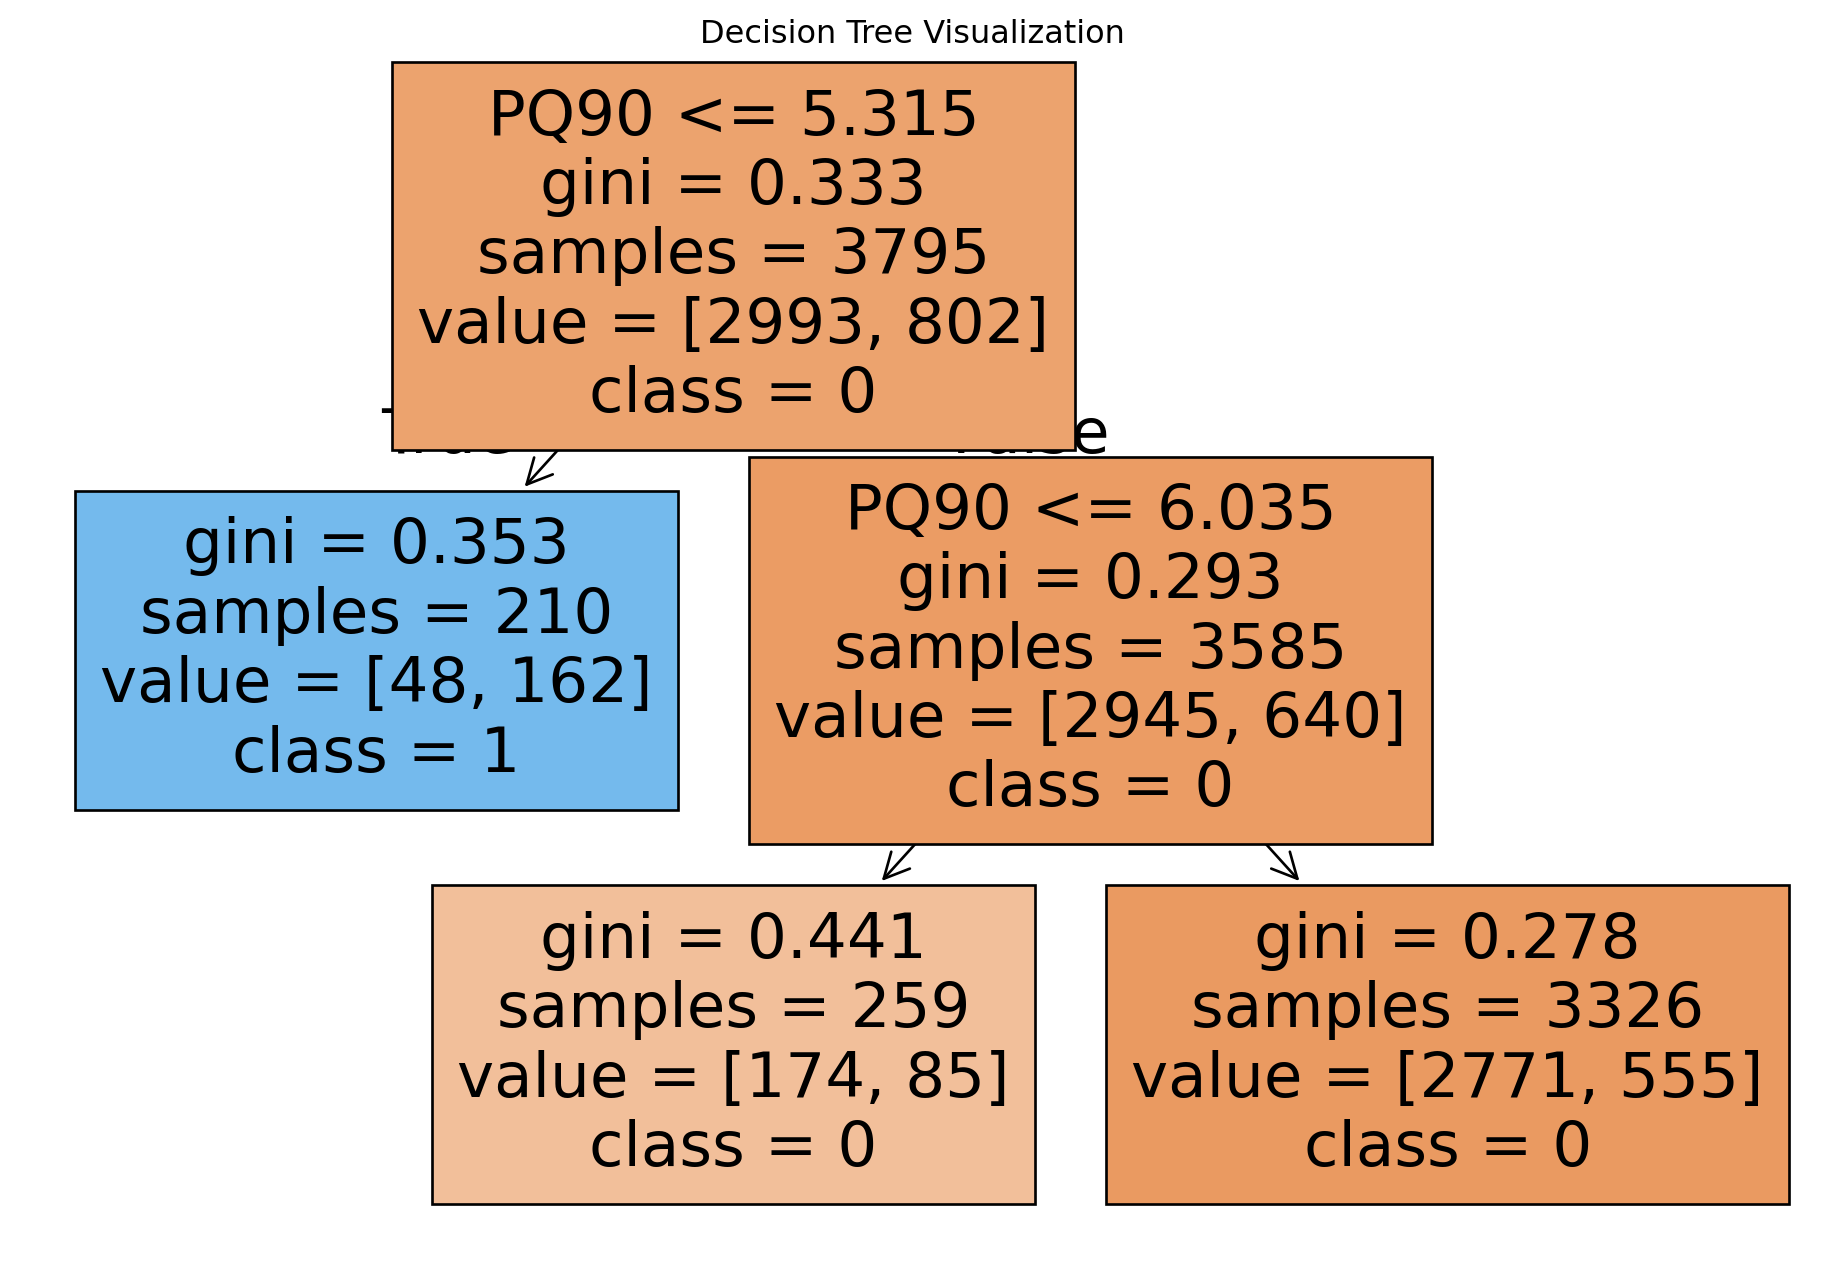

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3037785039.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(


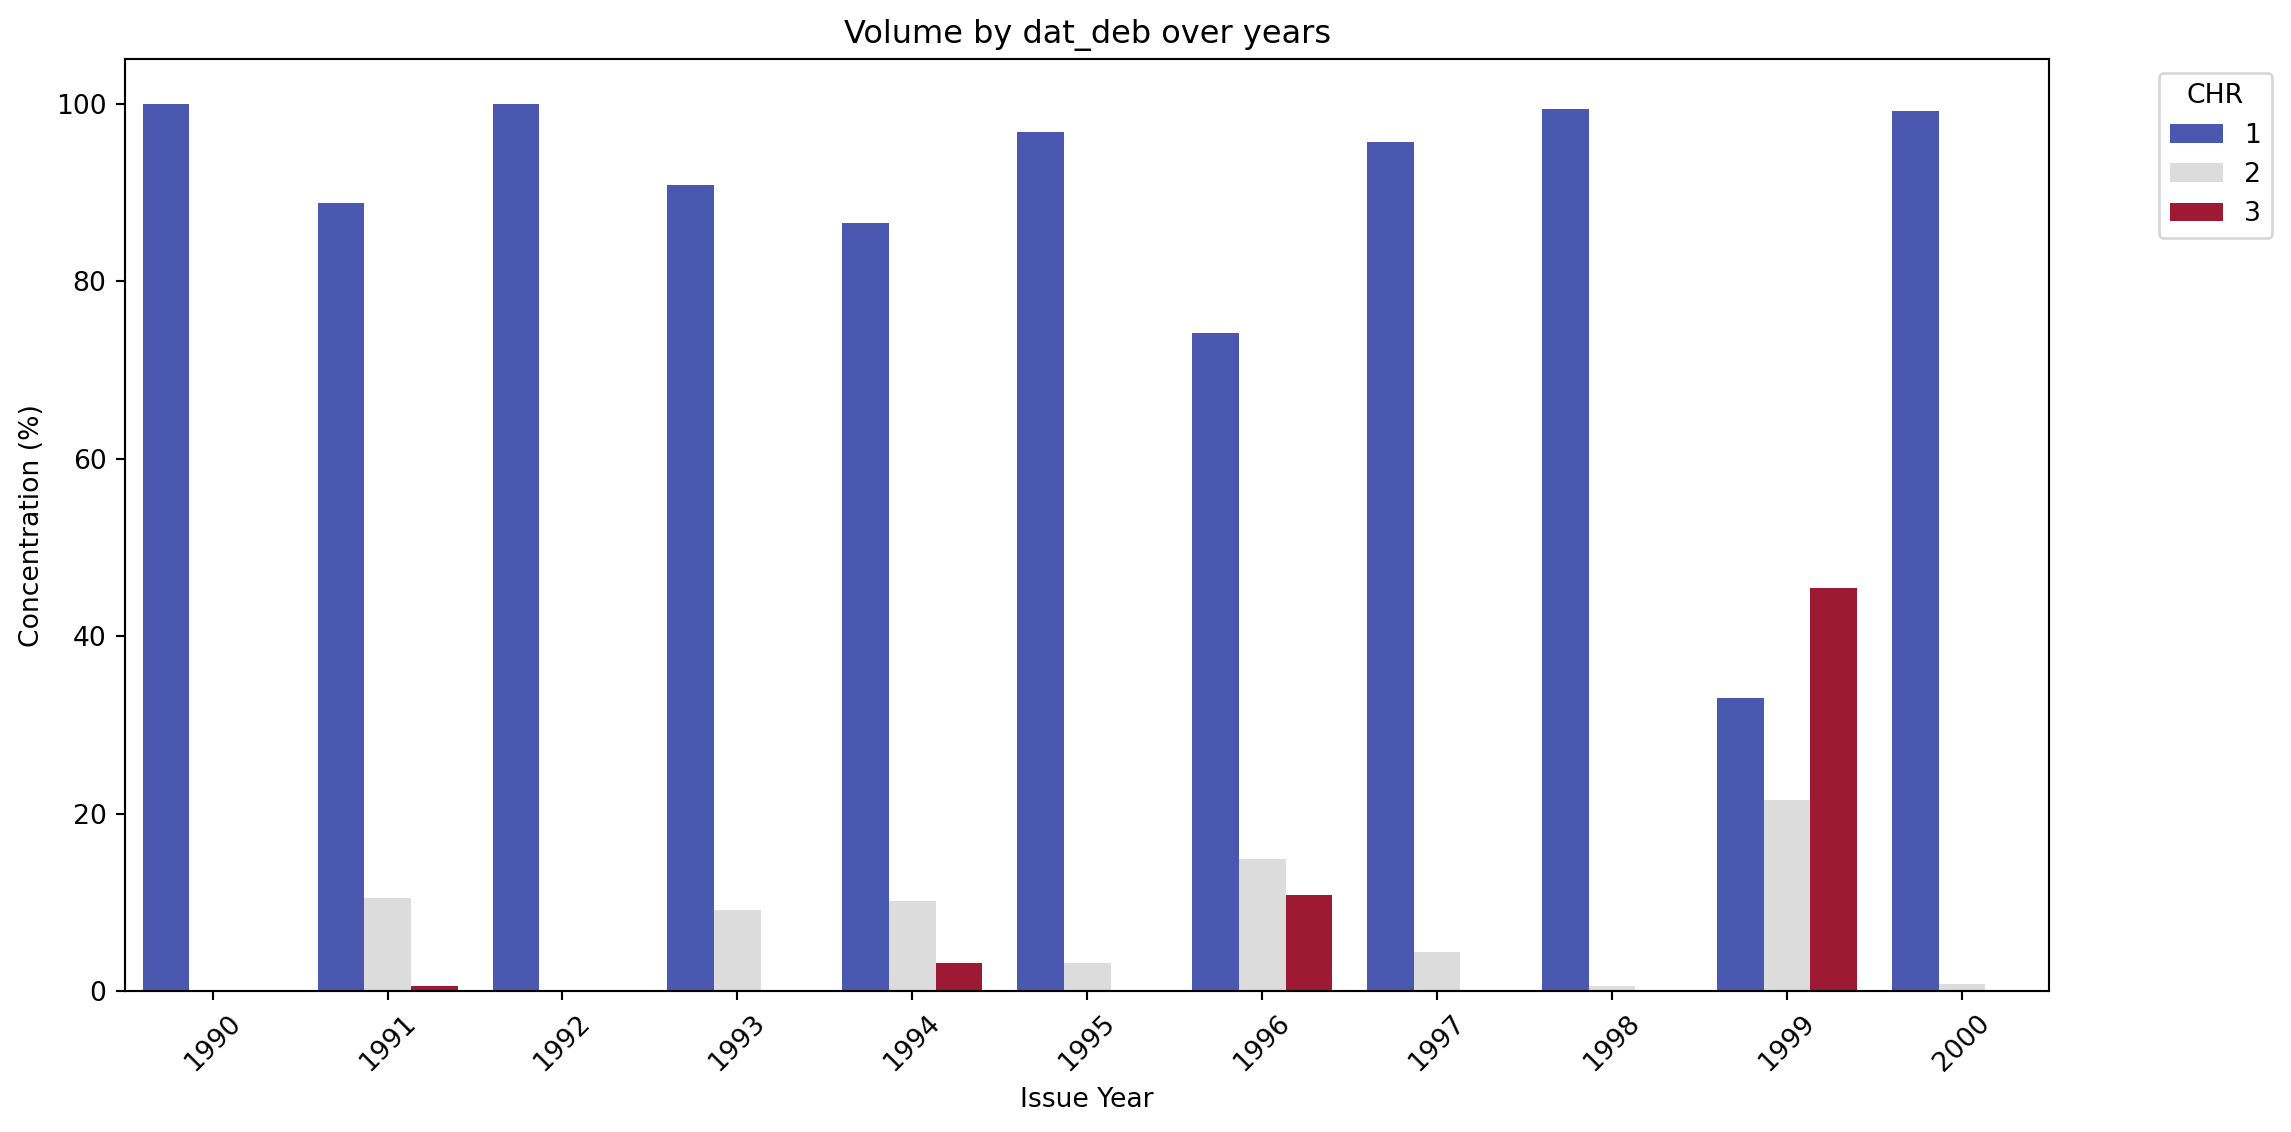

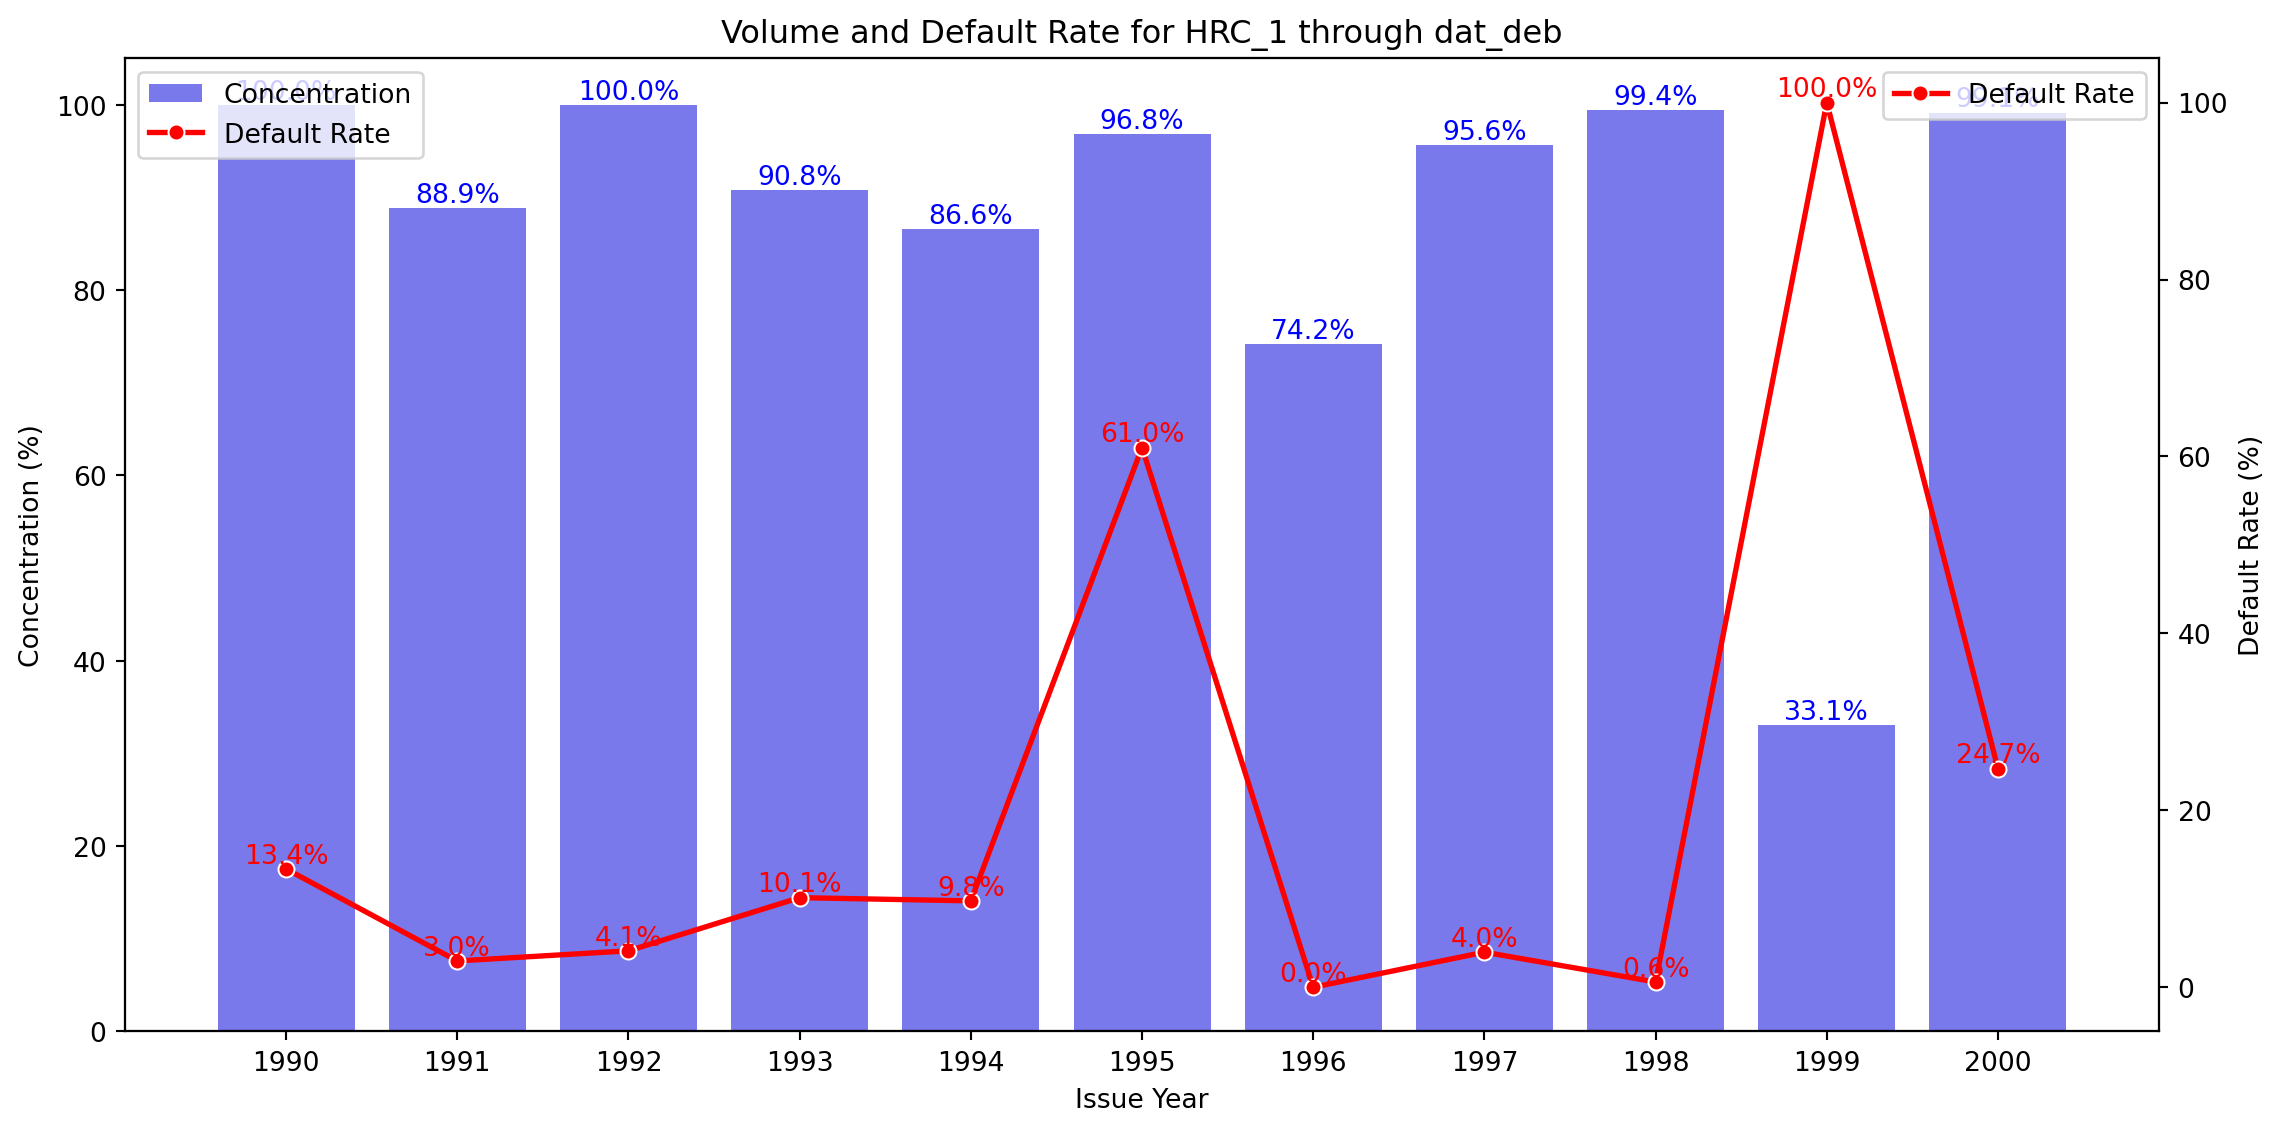

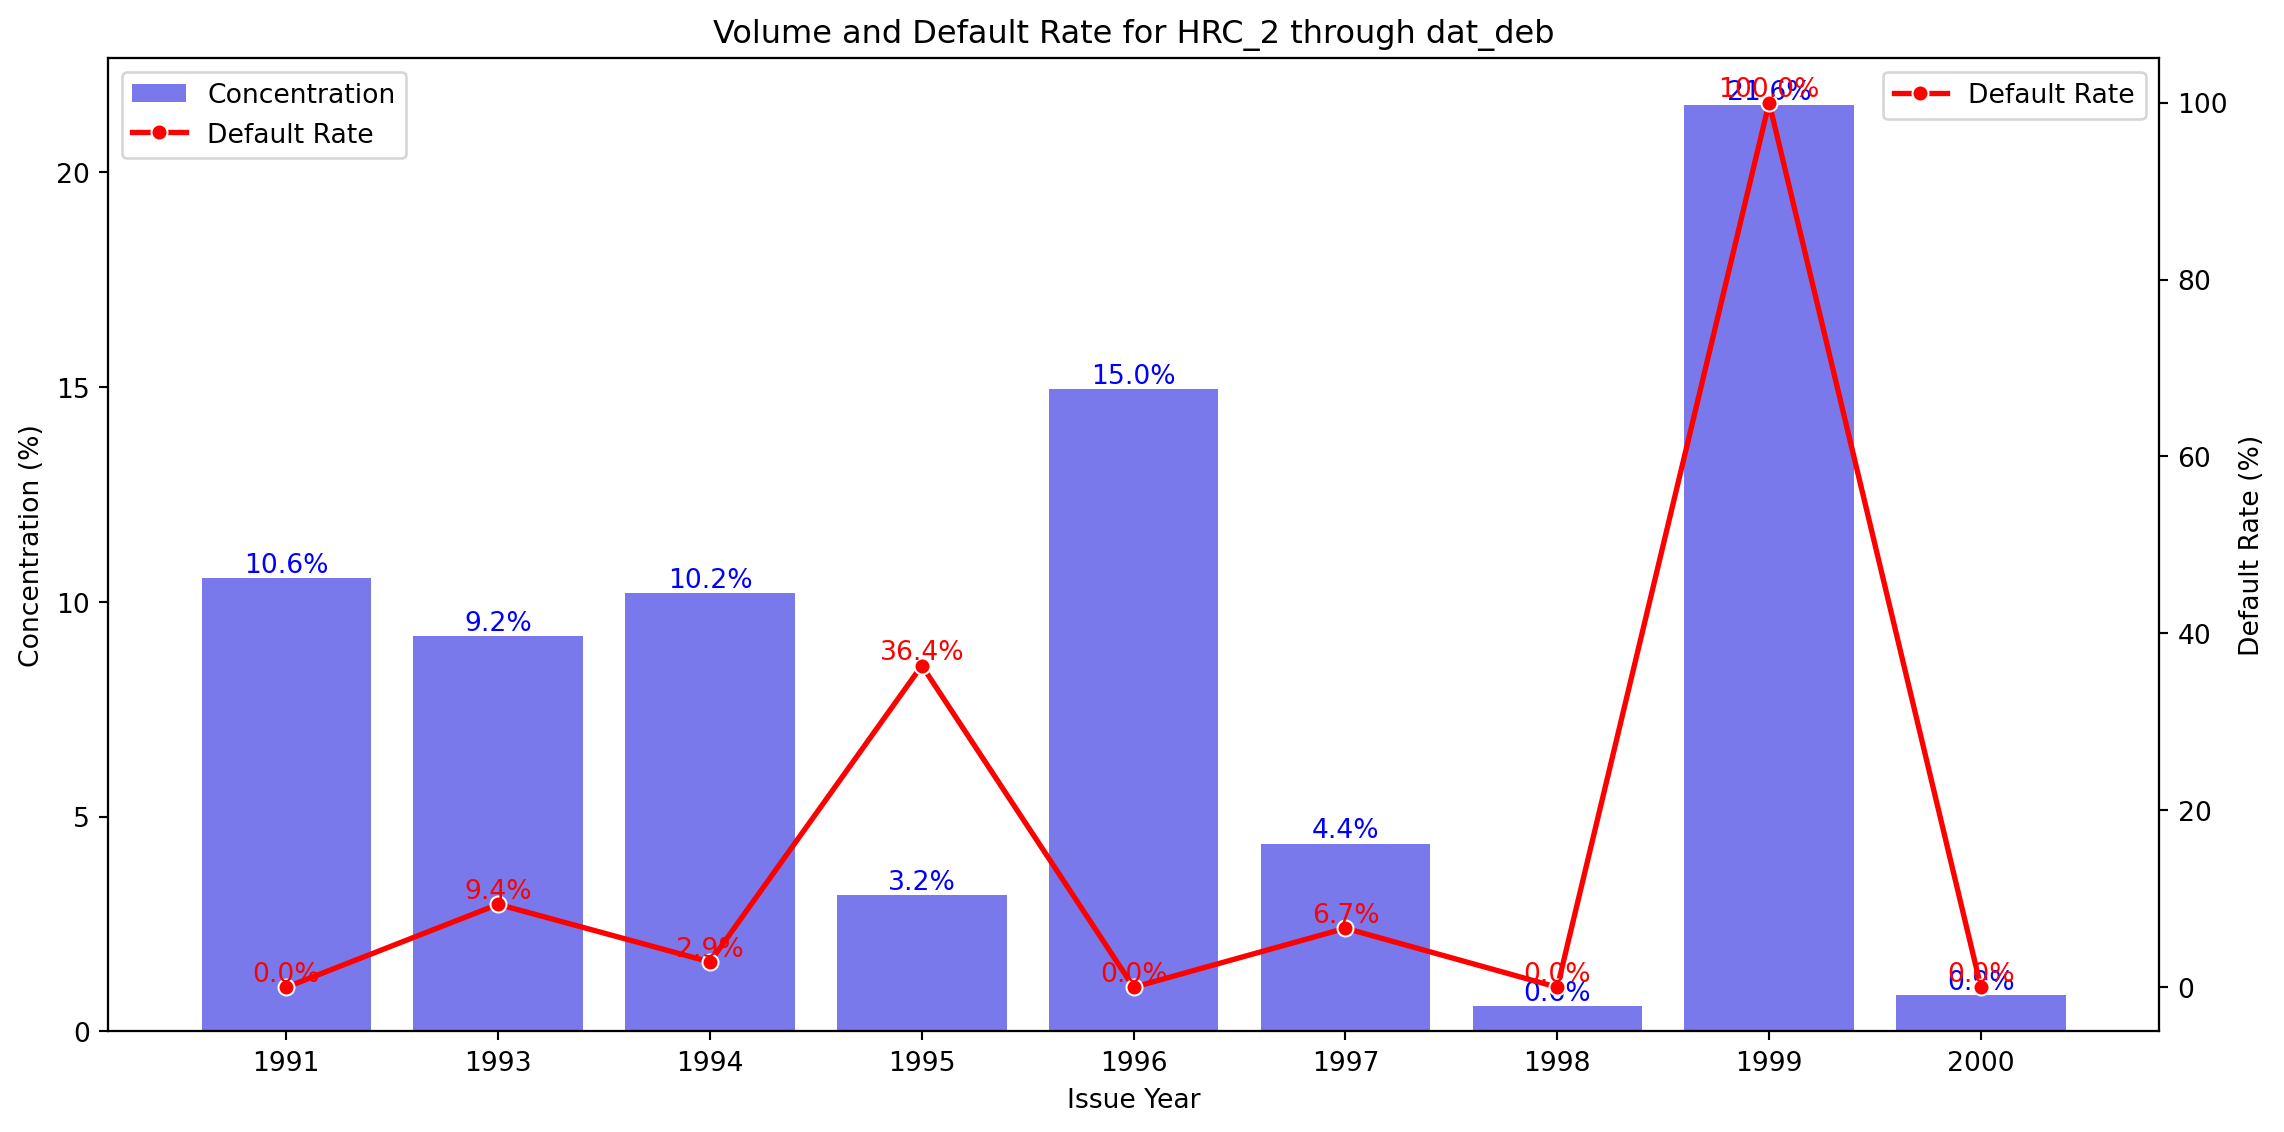

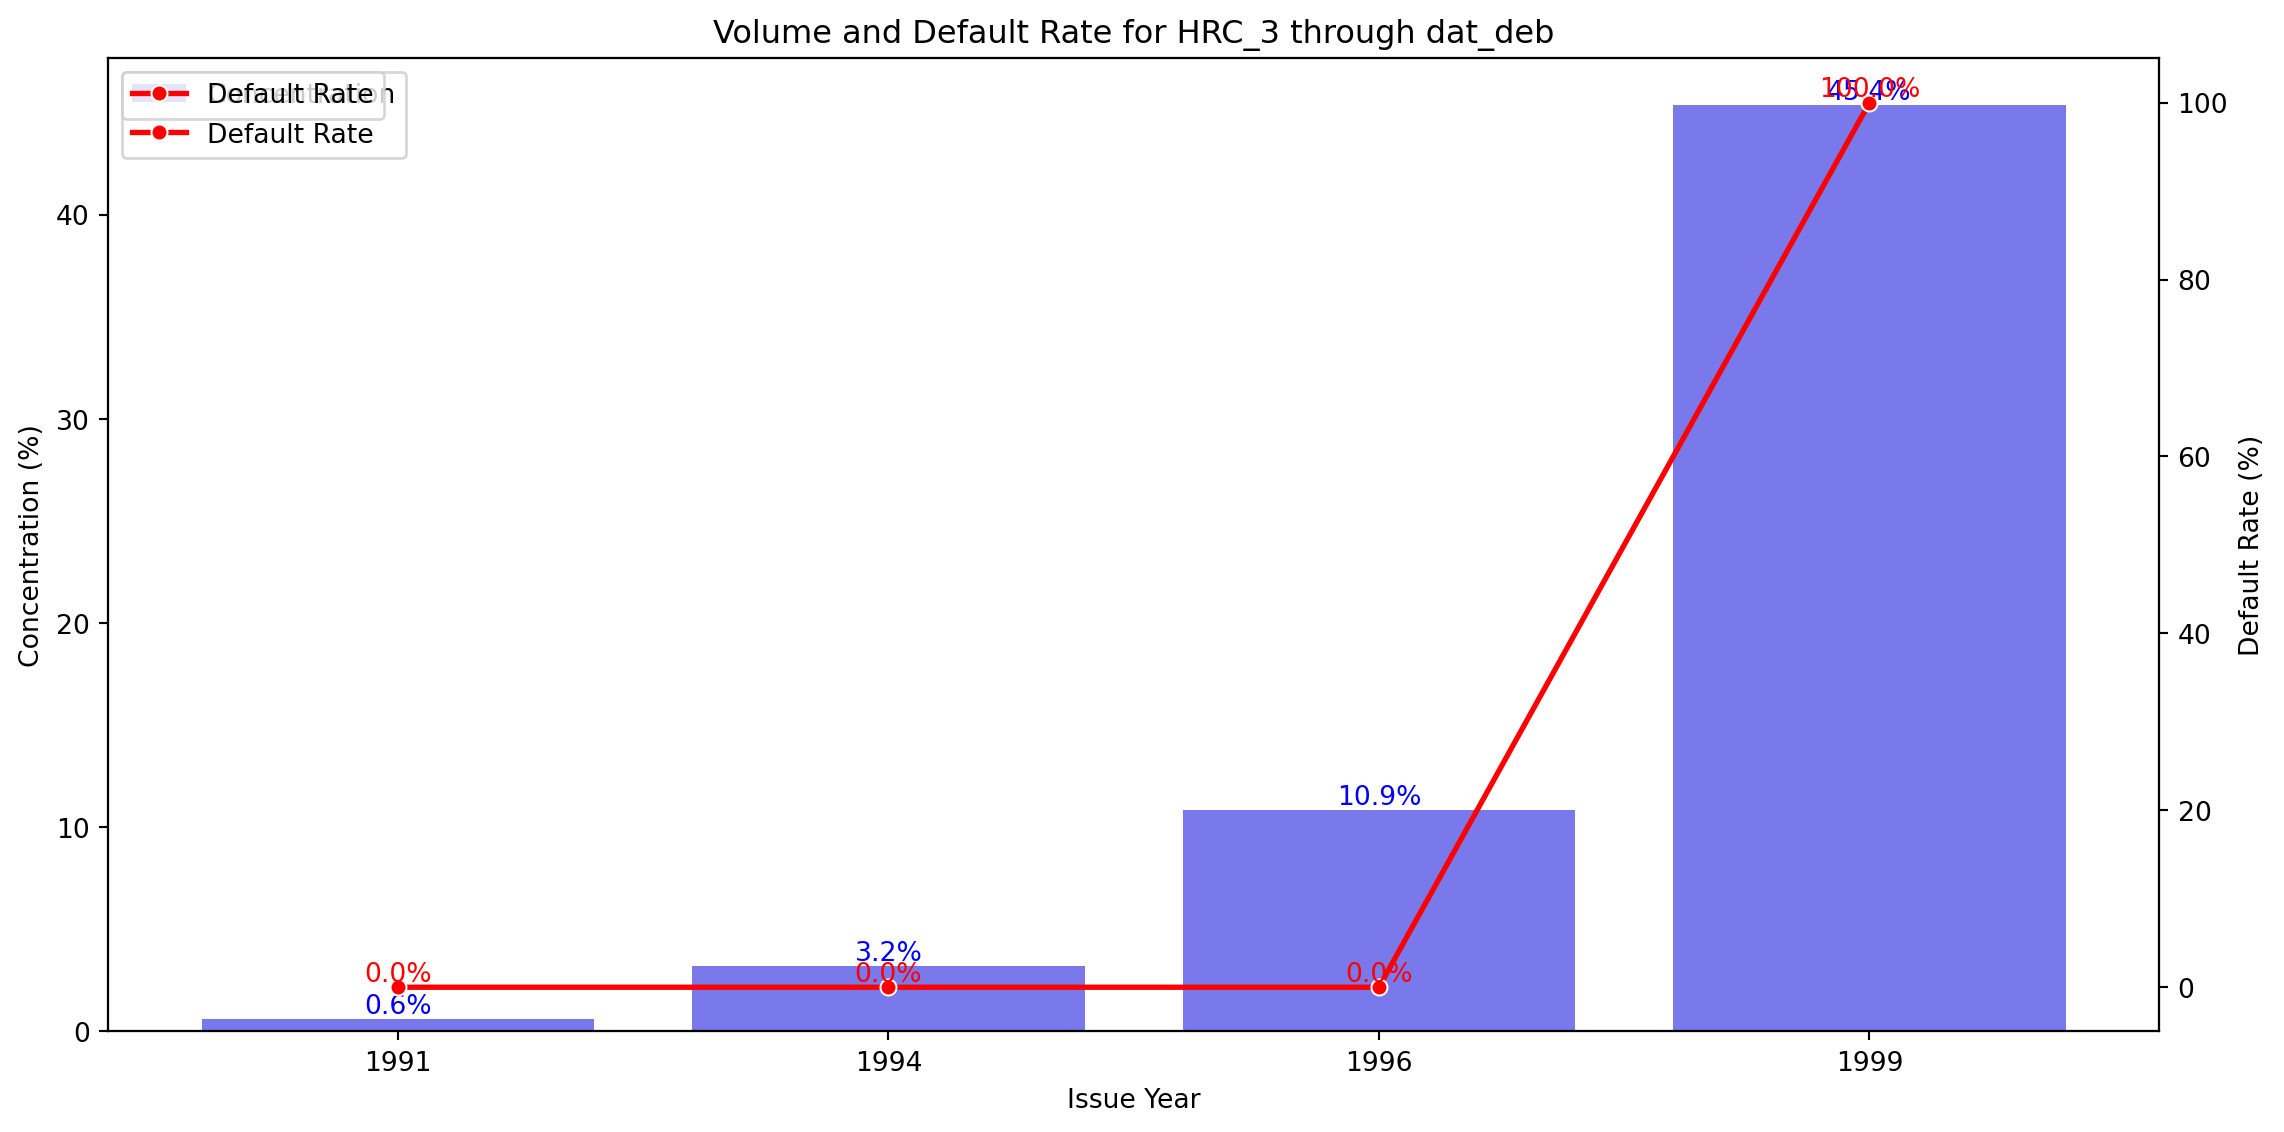

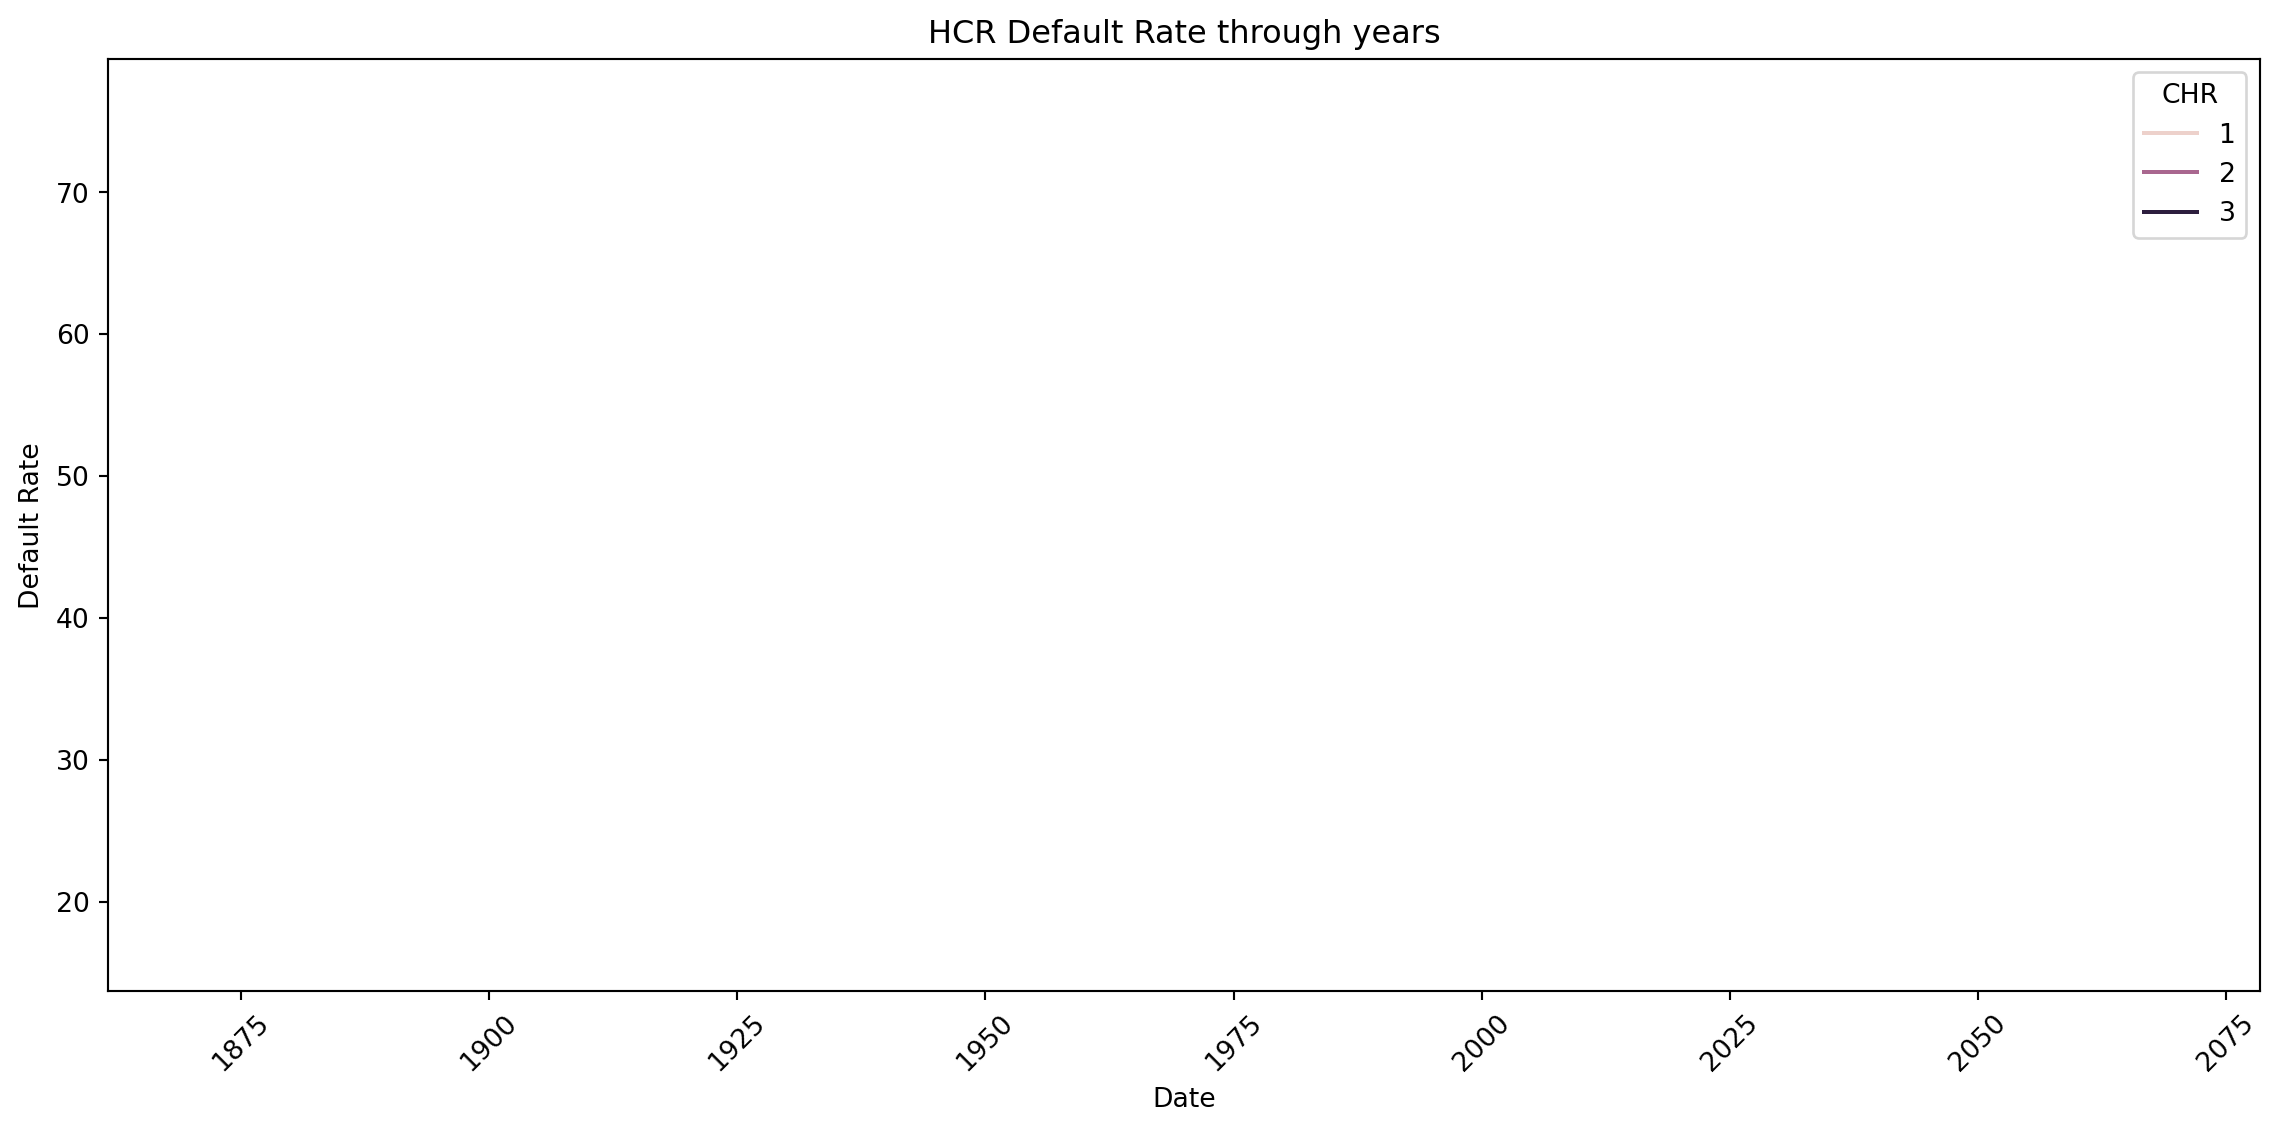

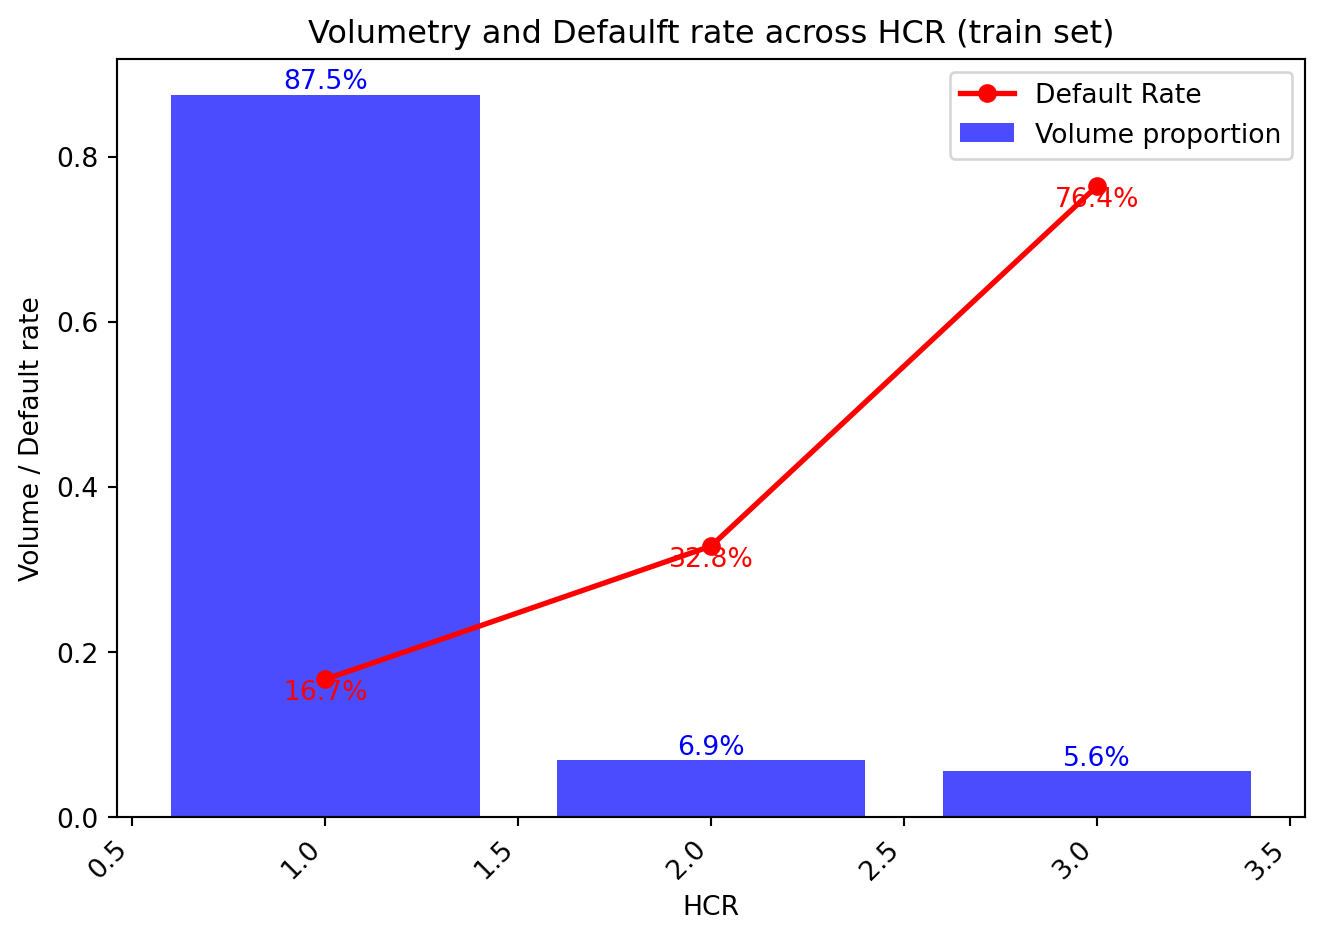

Optimal thresholds: 	[np.float64(-3.0524999999999984), 5.32, 6.04, np.float64(19.079499999999996)]
     Default rate  Relatif deviation  Gini index  Shannon entropy
CHR                                                              
1        0.166817                NaN    0.277978         0.450803
2        0.328244          96.768815    0.441000         0.632928
3        0.764151         132.799473    0.360449         0.546248


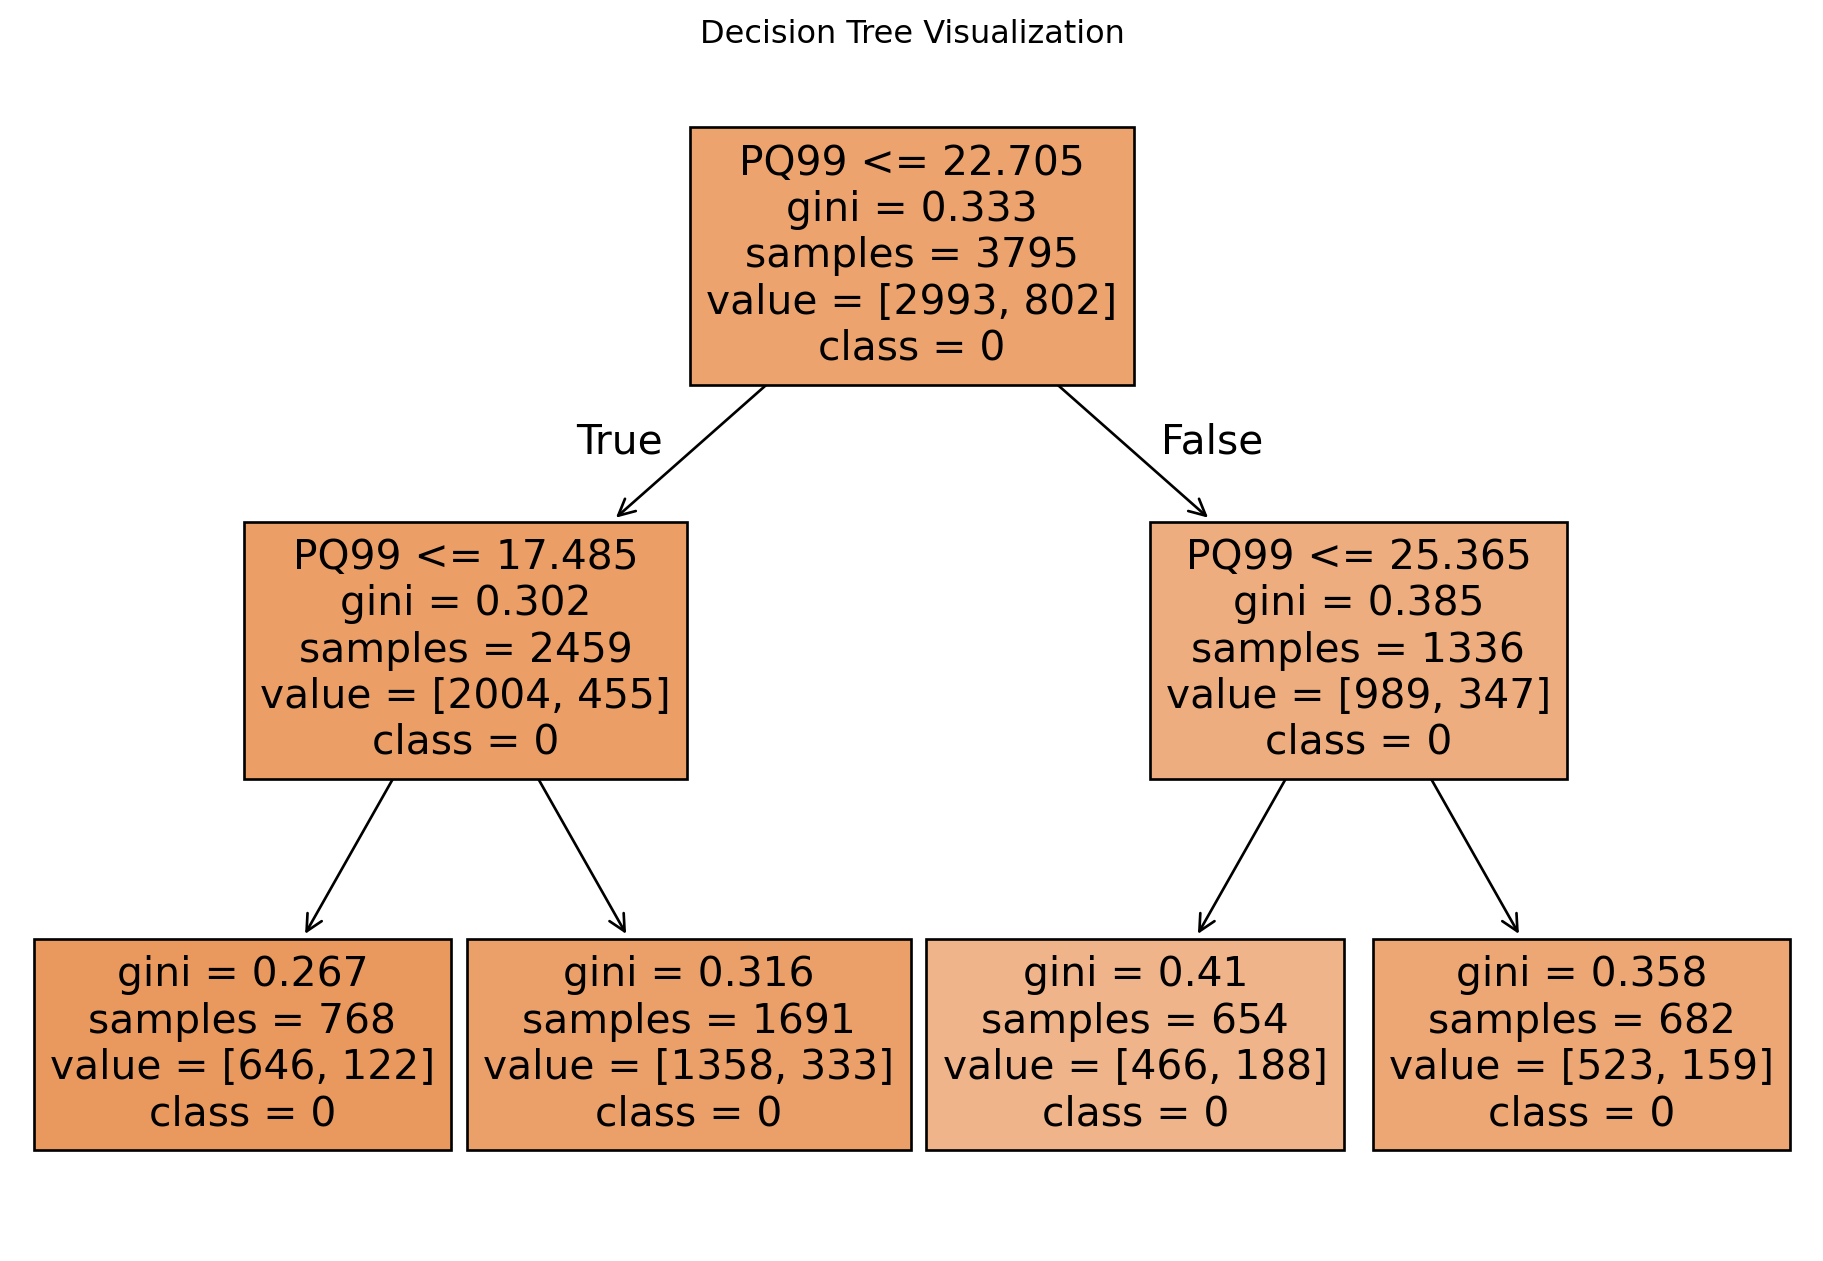

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3037785039.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(


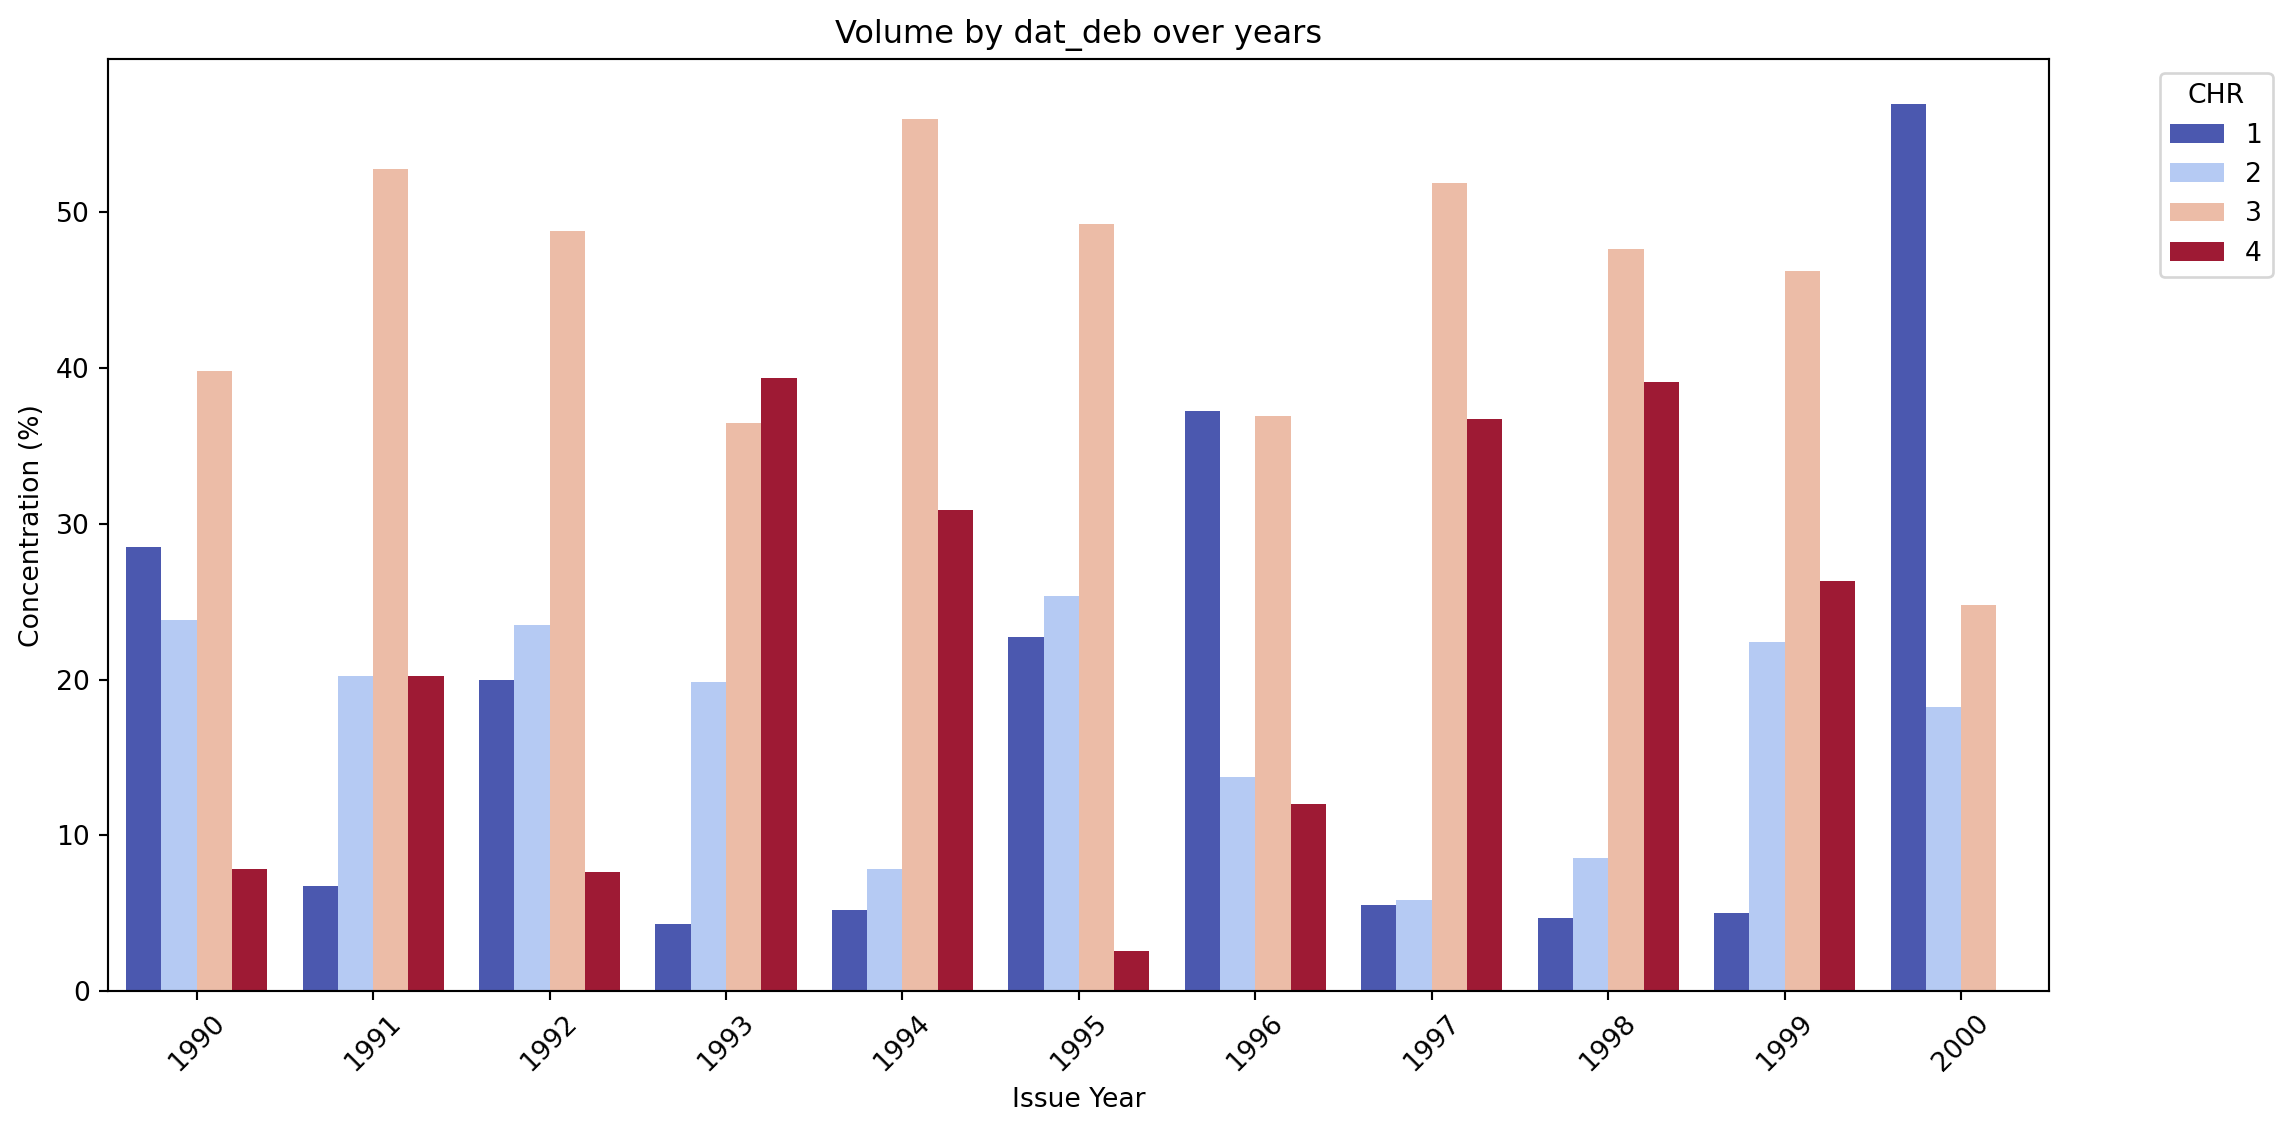

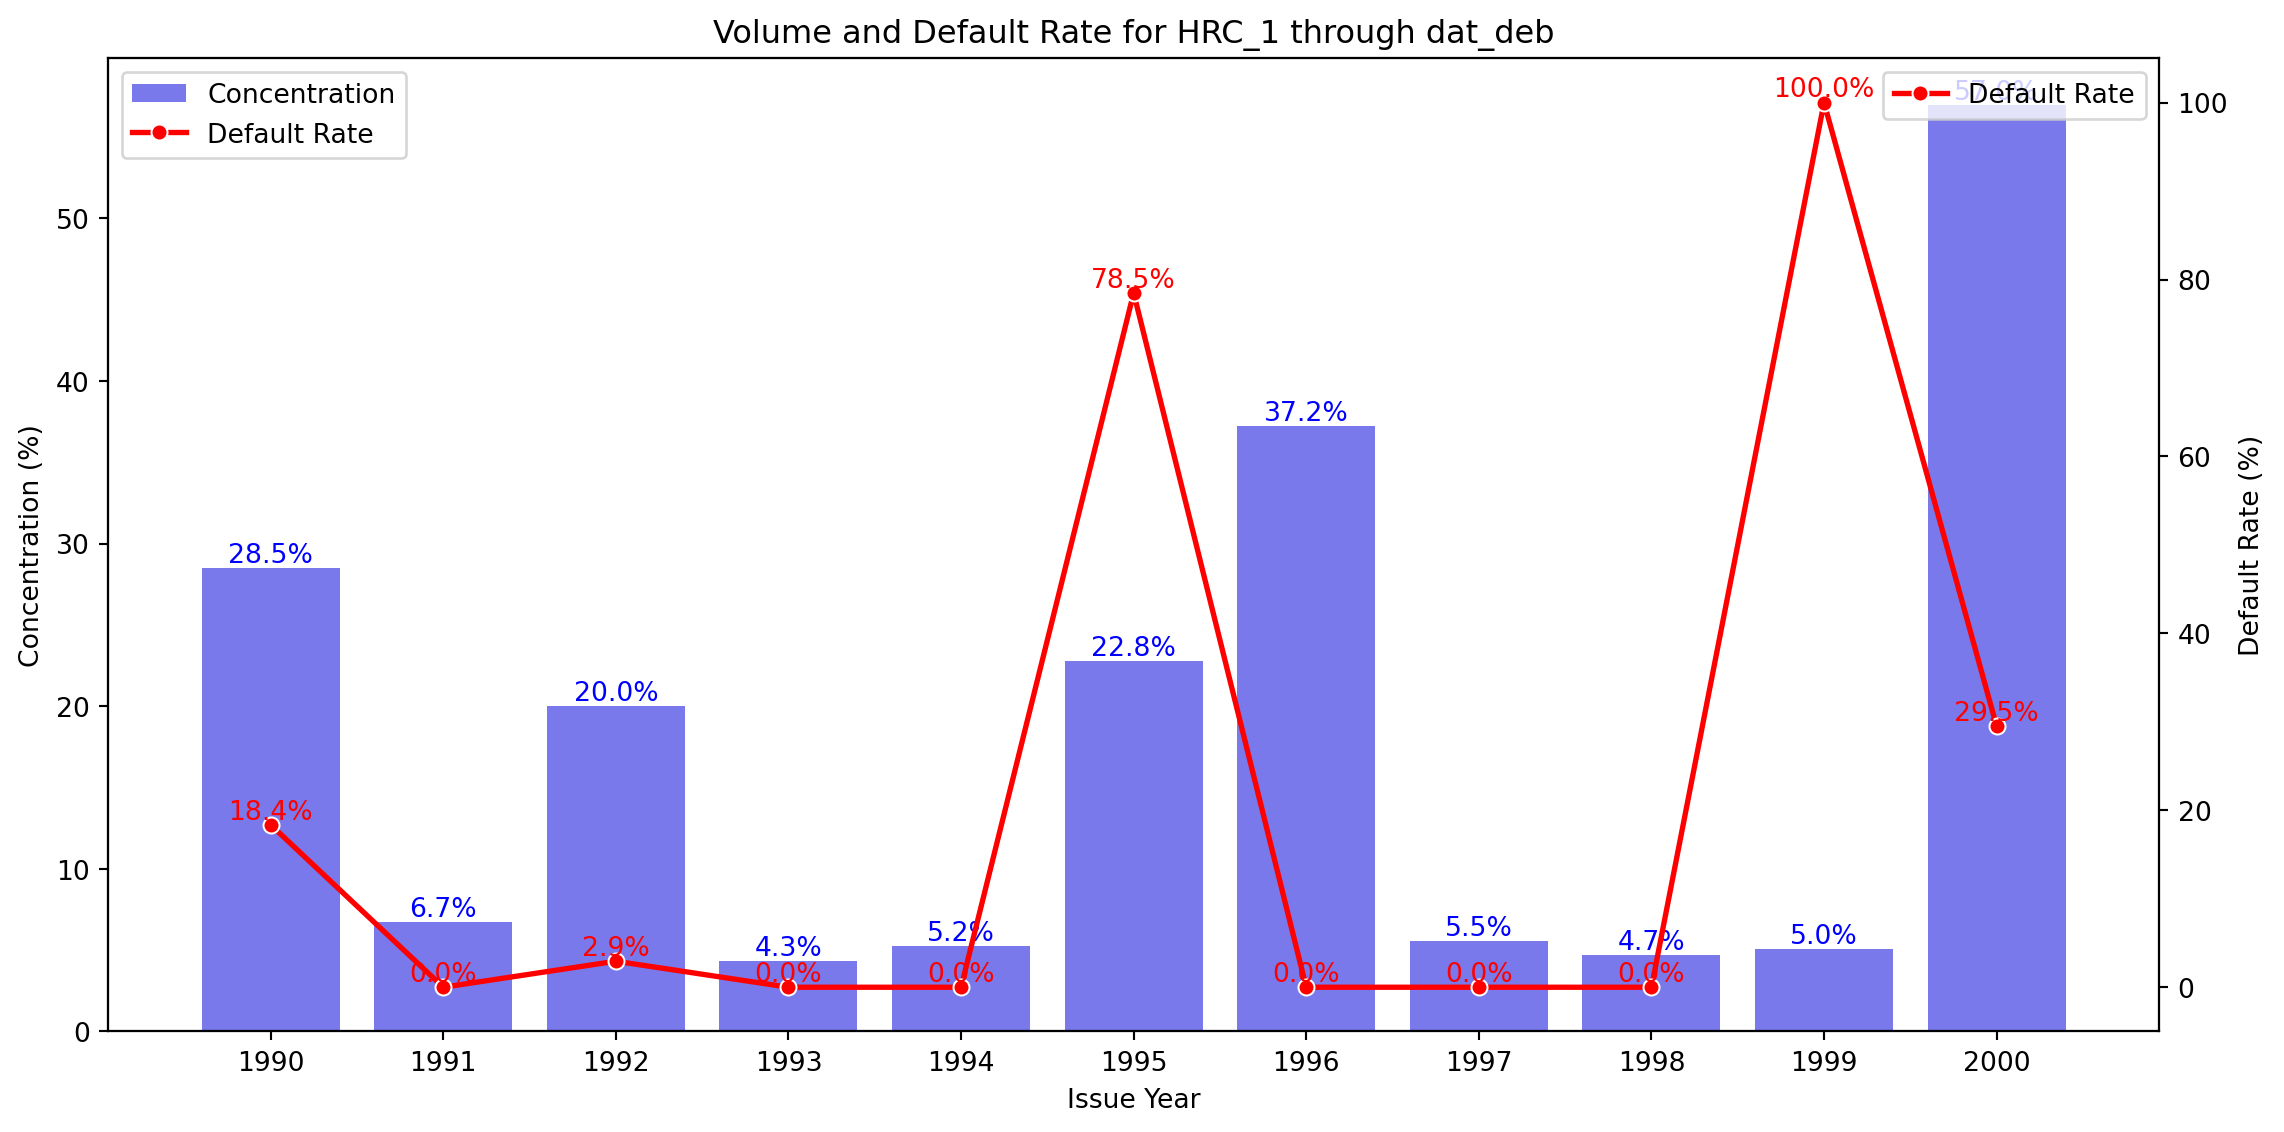

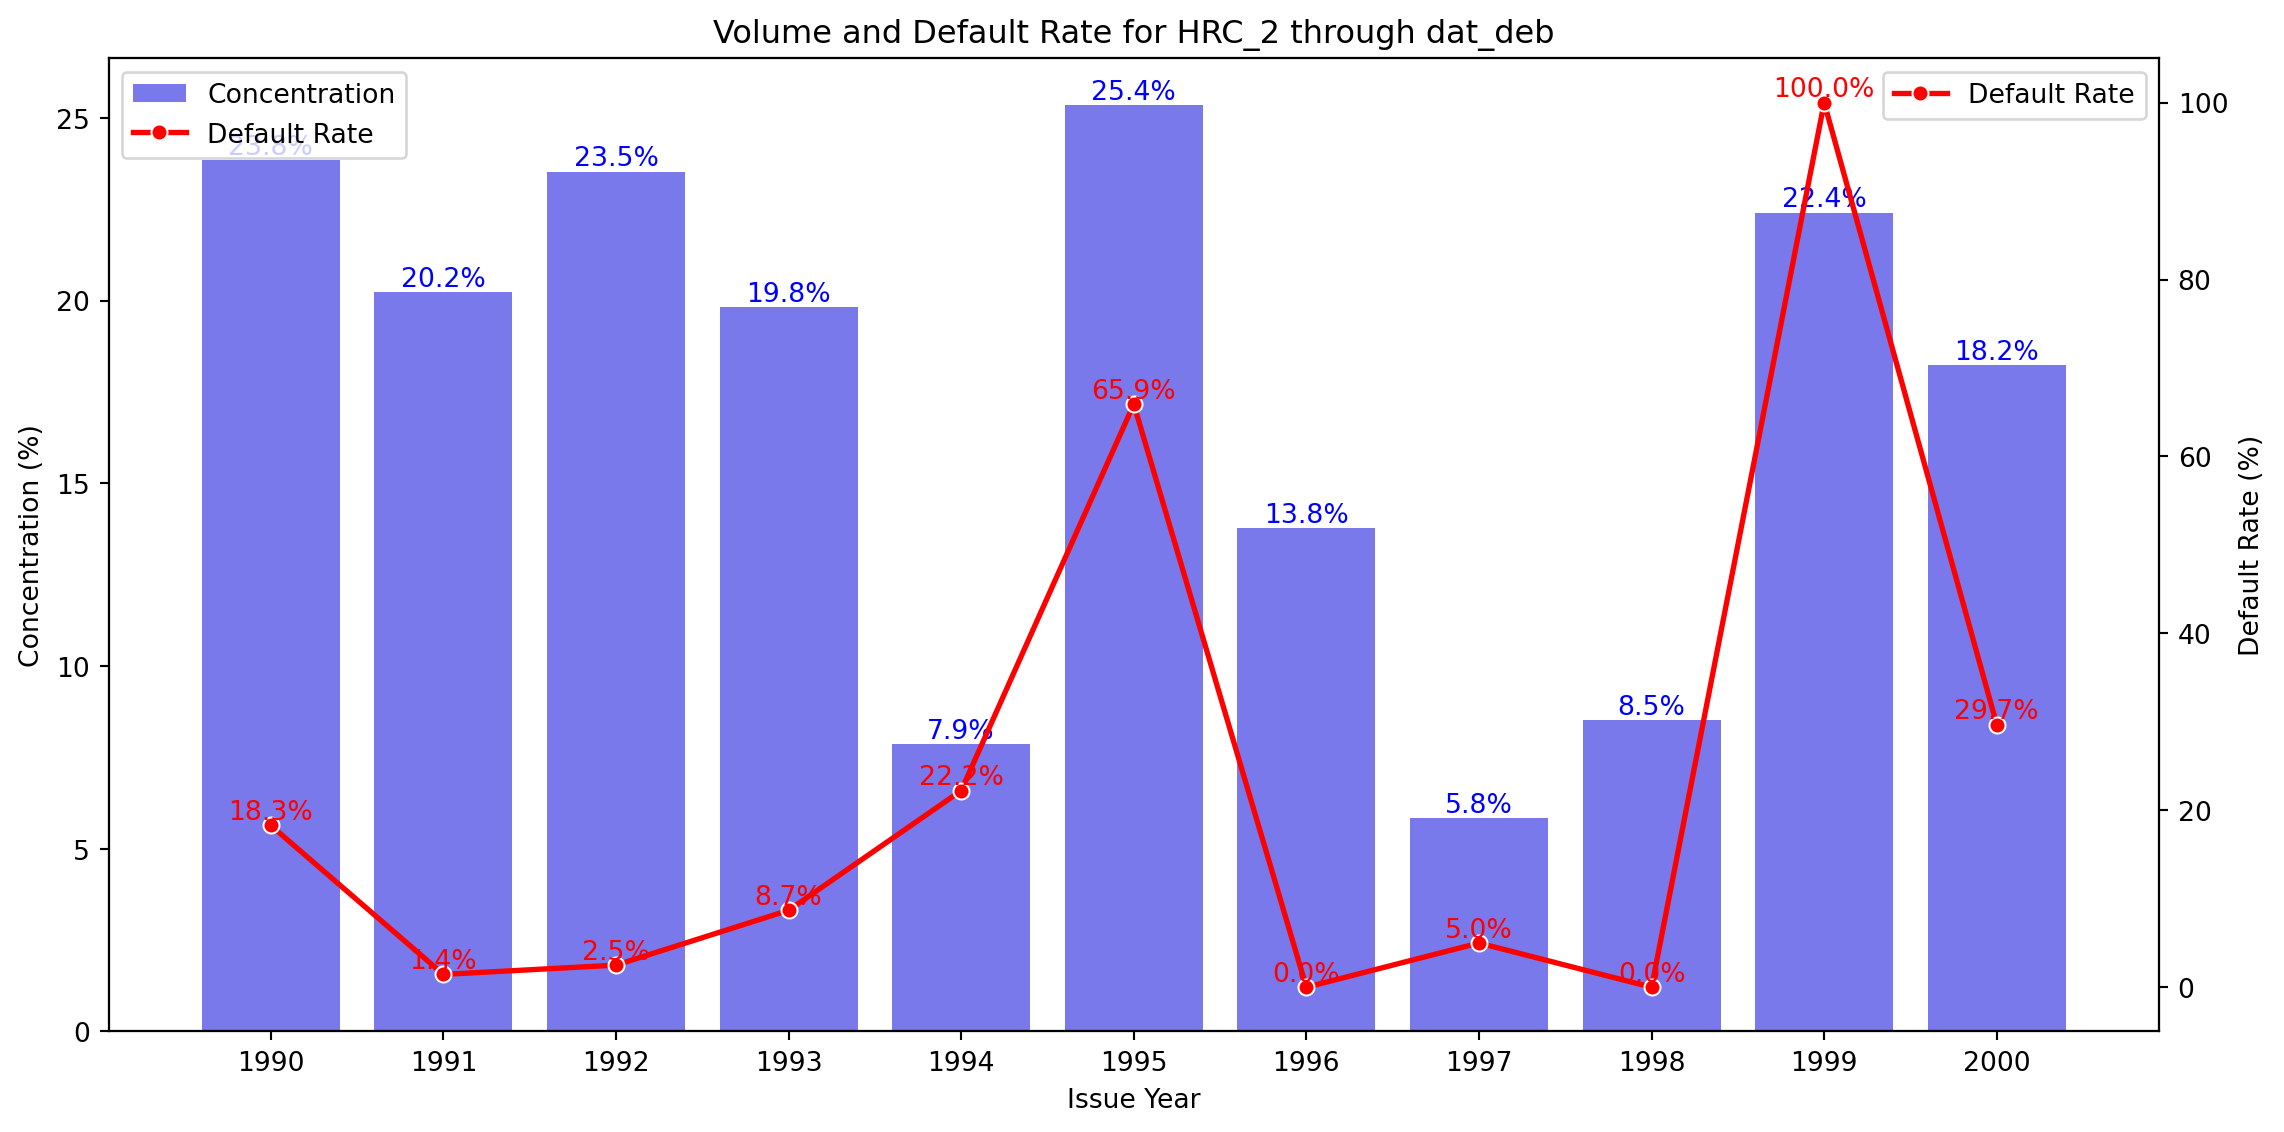

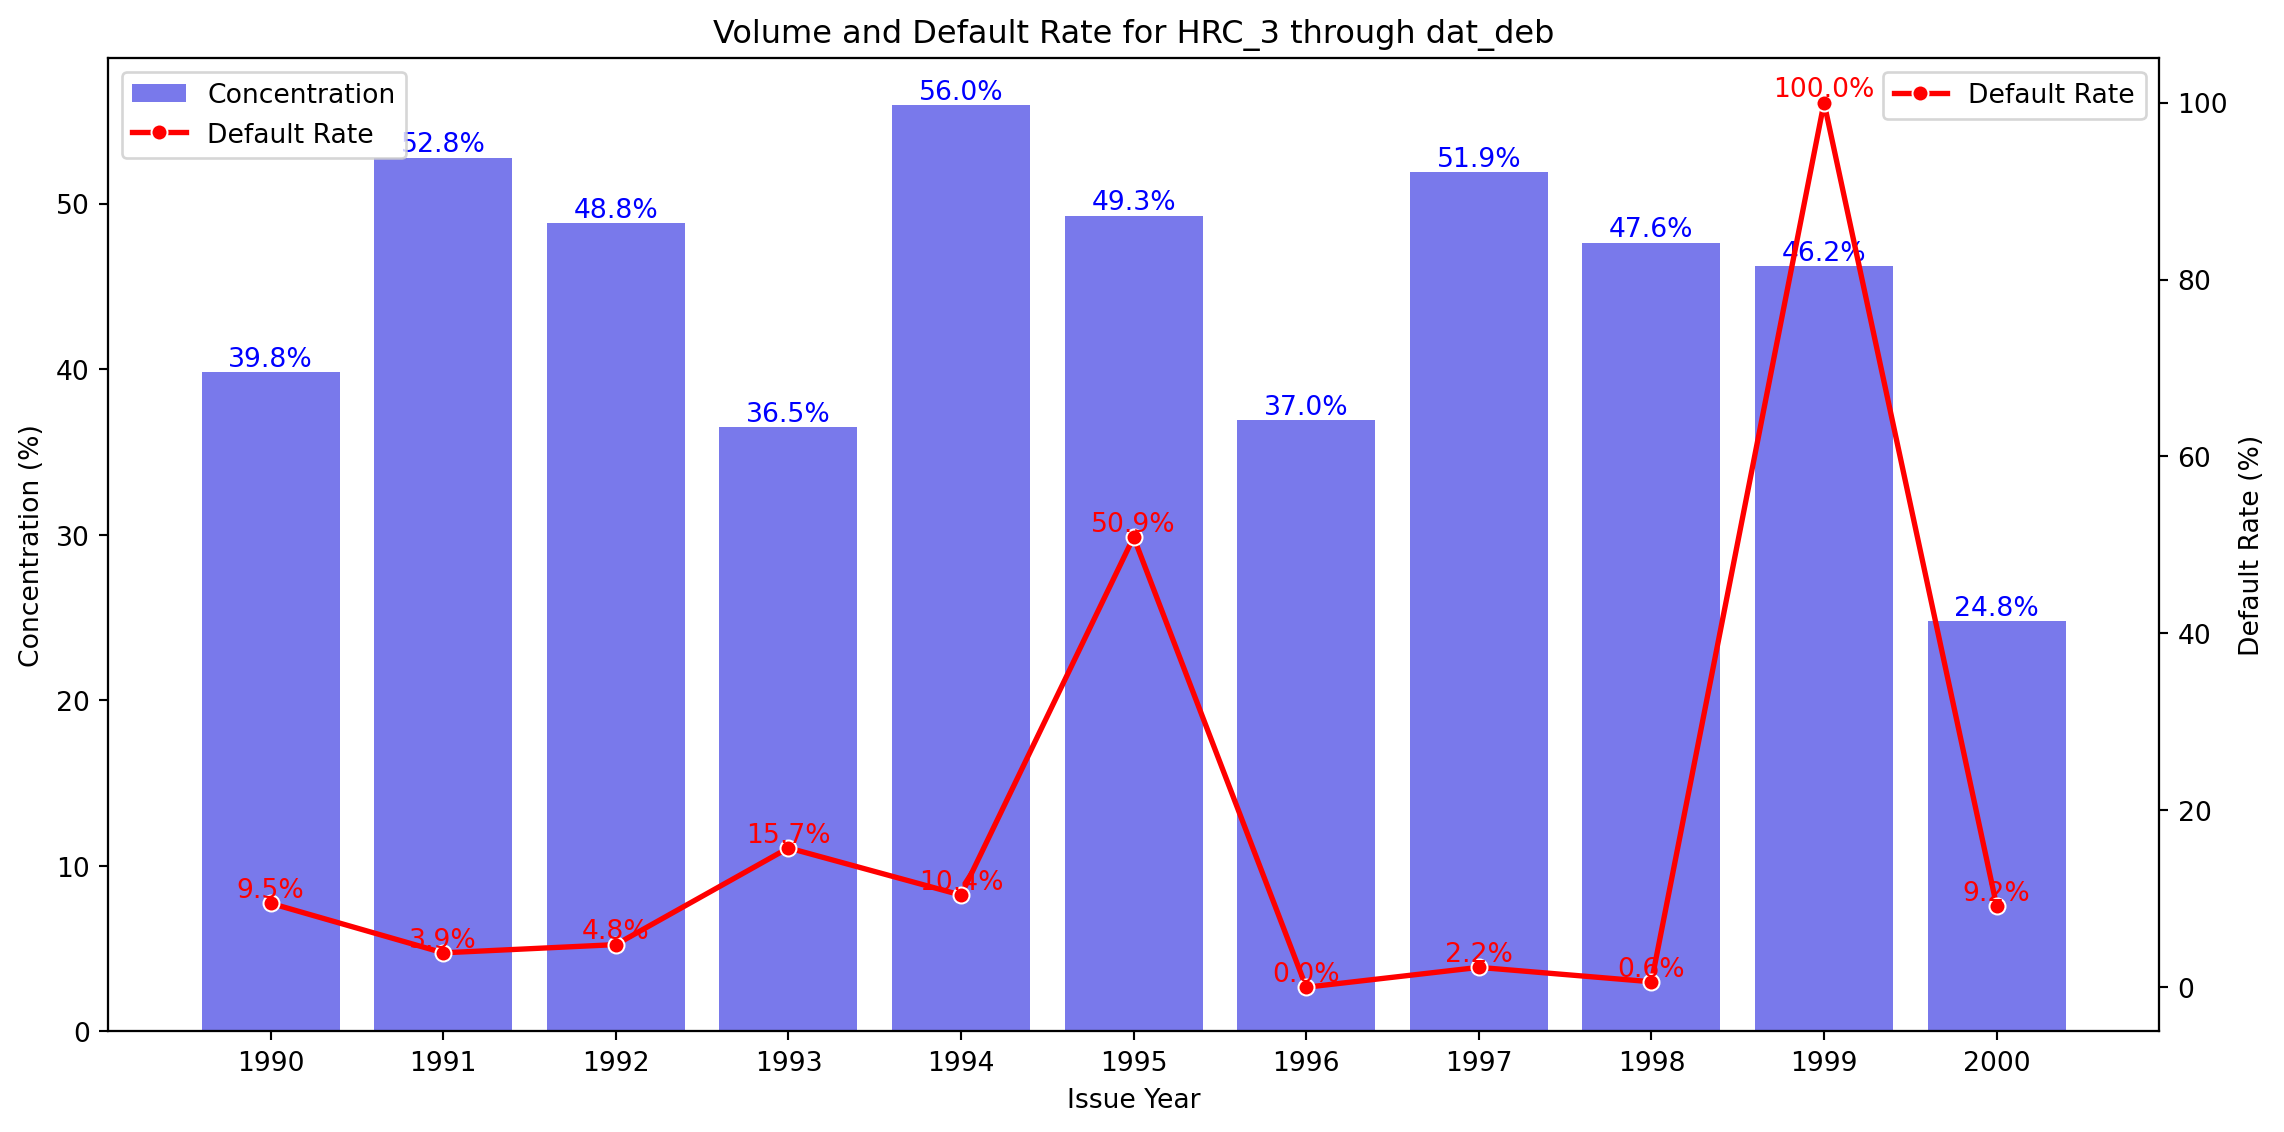

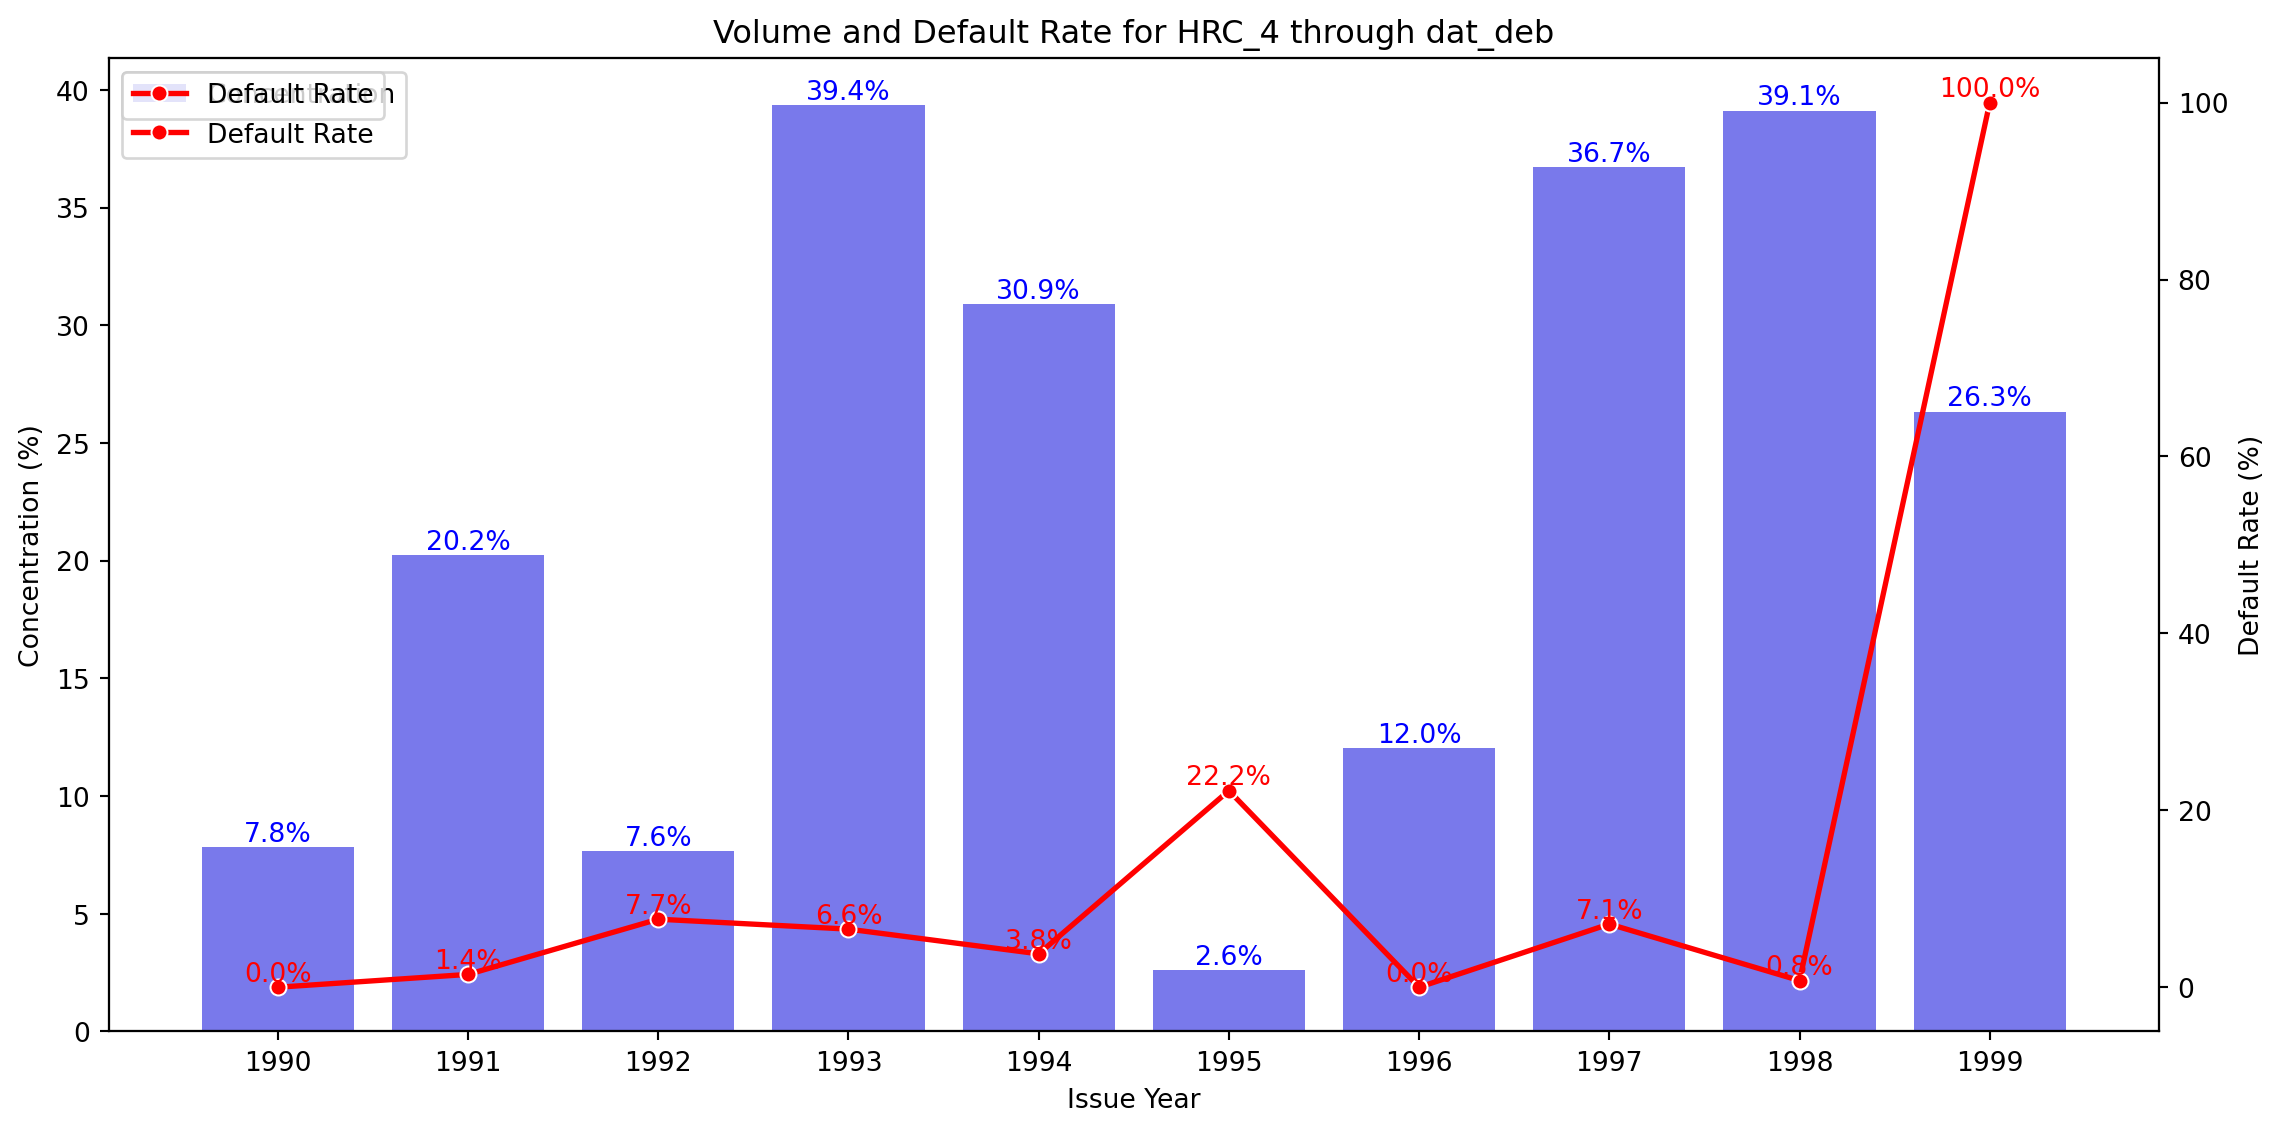

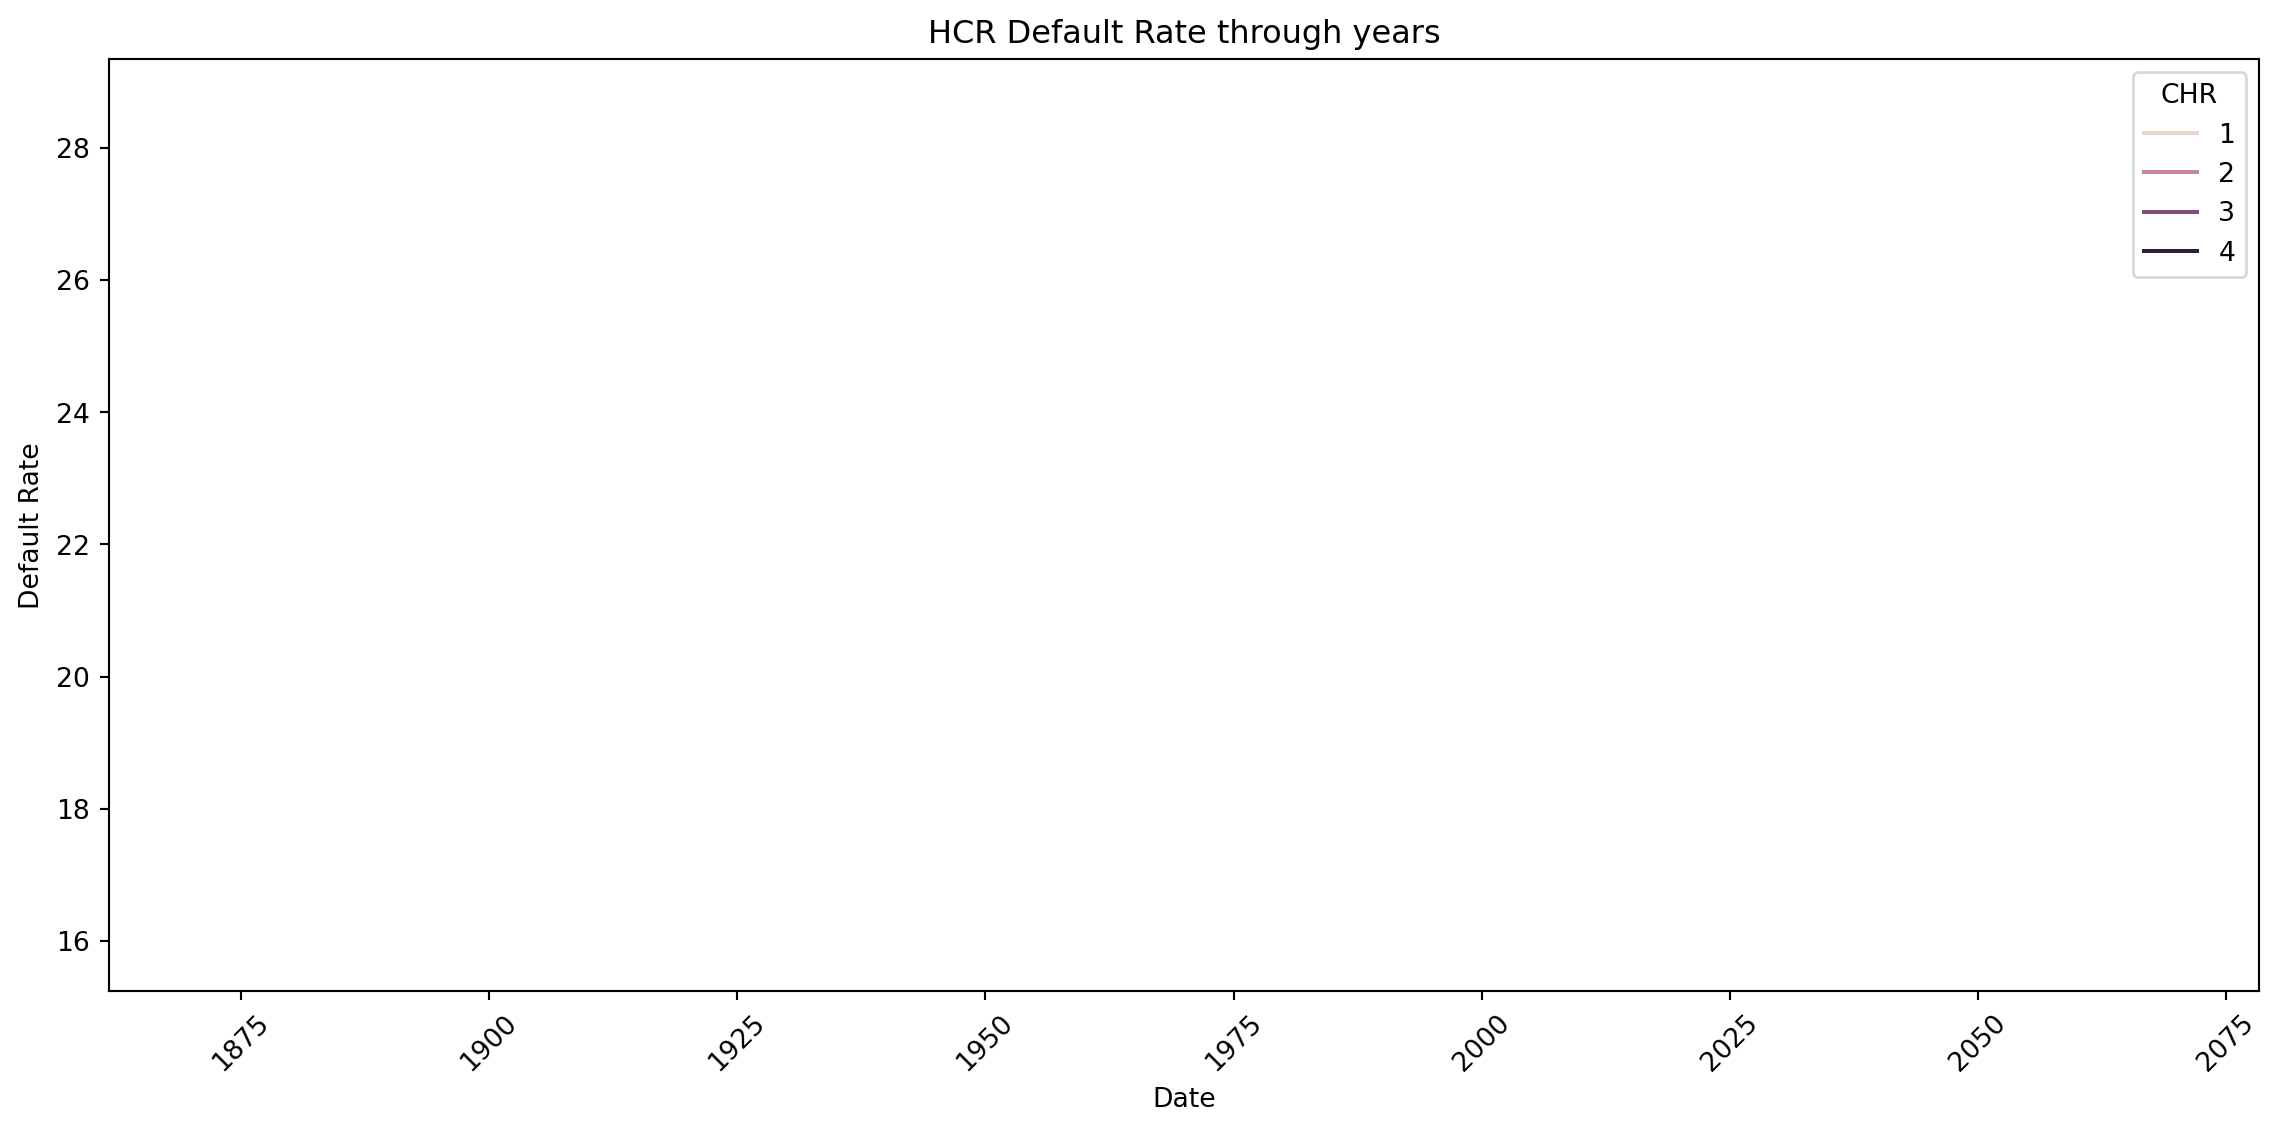

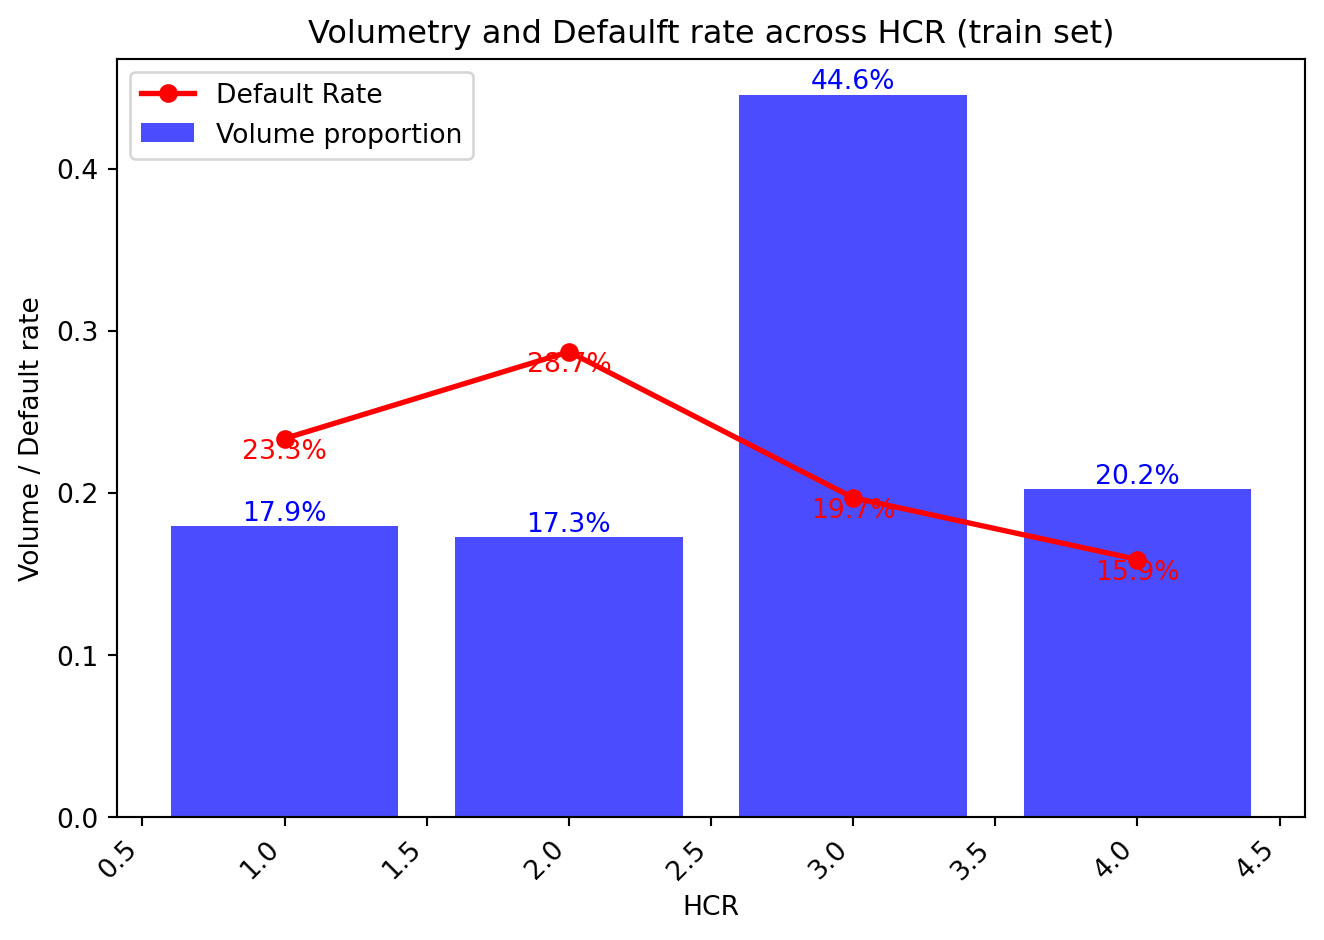

Optimal thresholds: 	[np.float64(-6.3394999999999975), 17.48, 22.7, 25.37, np.float64(50.512499999999996)]
     Default rate  Relatif deviation  Gini index  Shannon entropy
CHR                                                              
4        0.158854                NaN    0.267239         0.437765
3        0.196925          23.965836    0.316291         0.496110
1        0.233480          18.563056    0.357934         0.543447
2        0.287023          22.932450    0.409282         0.599464


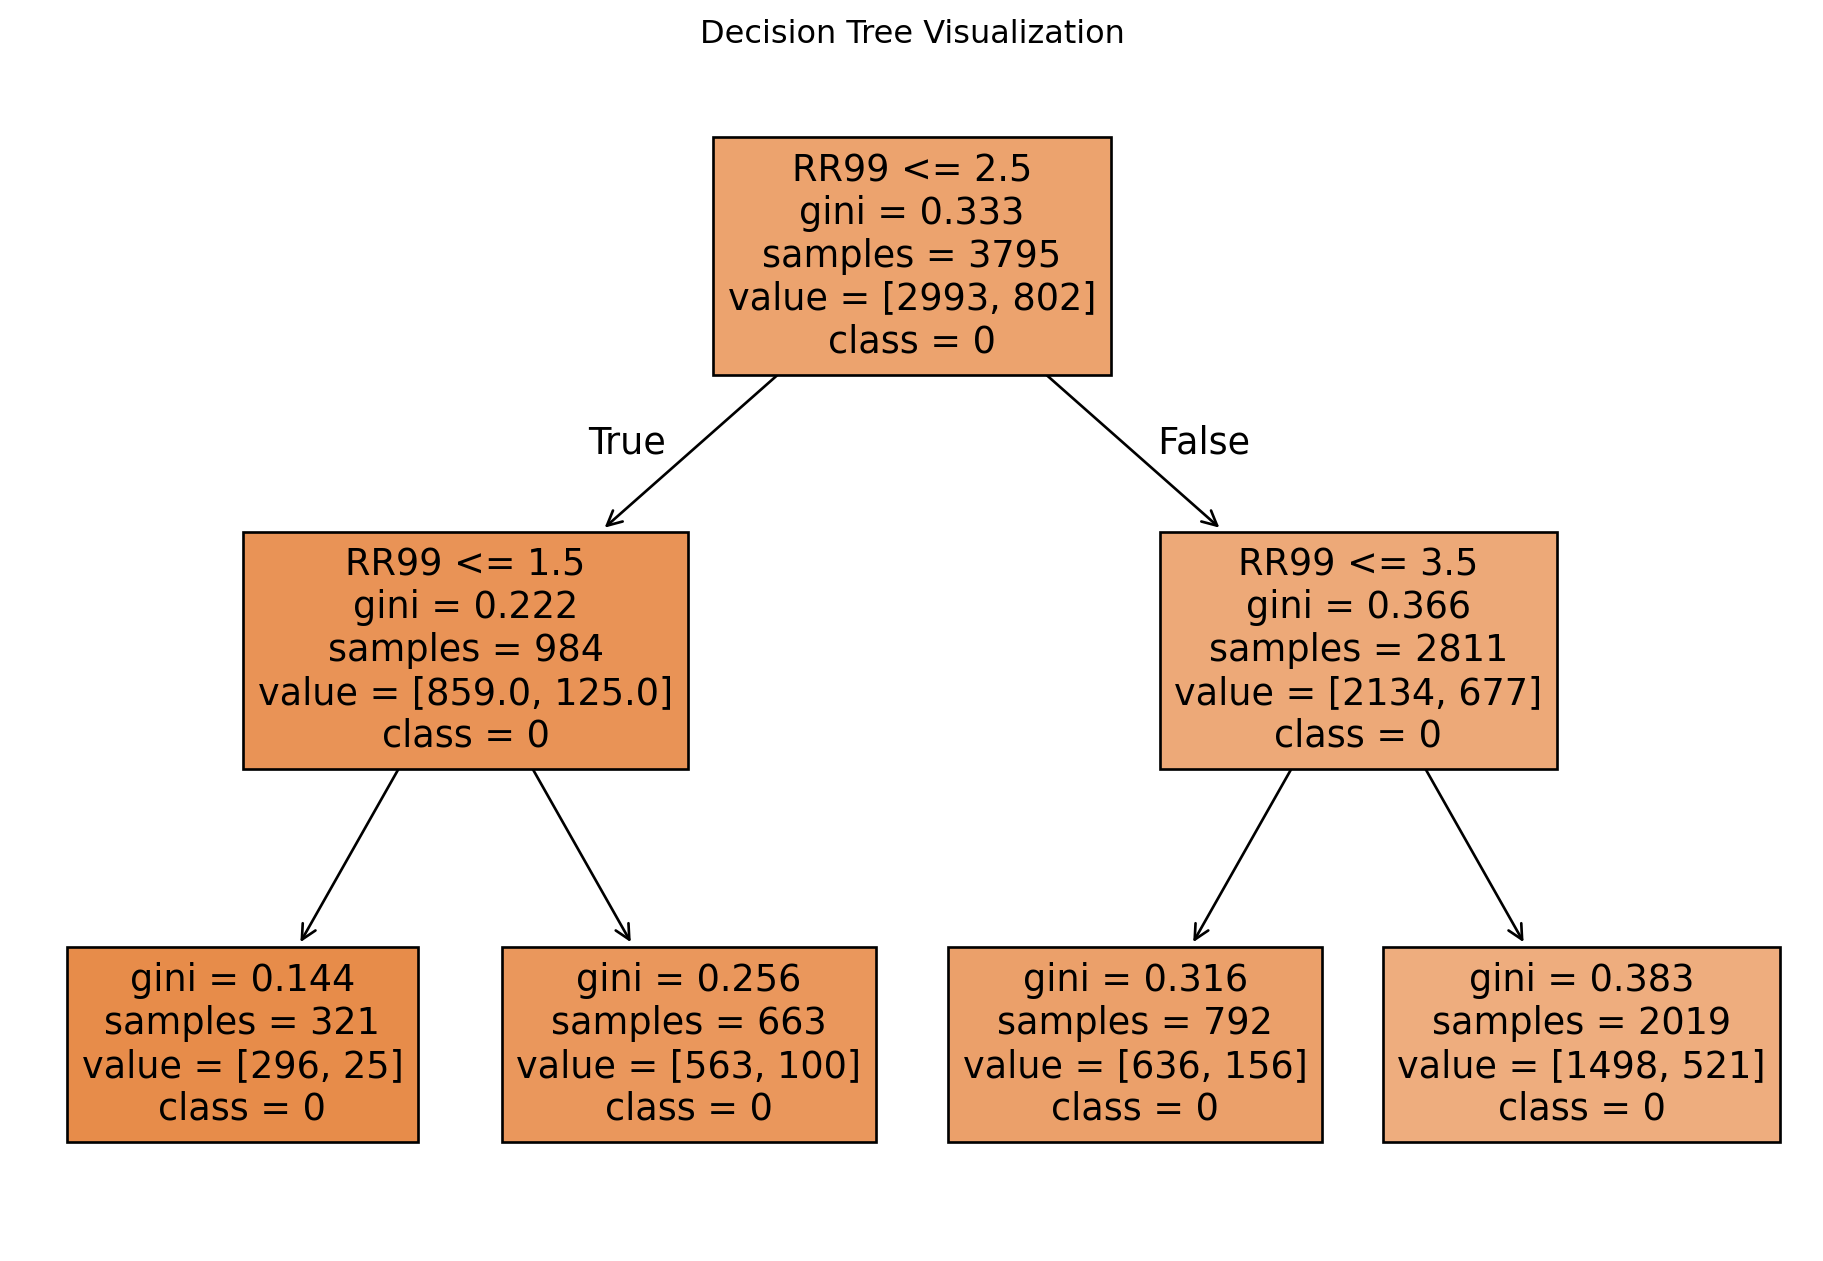

C:\Users\DEBA\AppData\Local\Temp\ipykernel_42680\3037785039.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_score = df_score.groupby([pd.Grouper(key=date_column, freq='Y'), hcr]).agg(


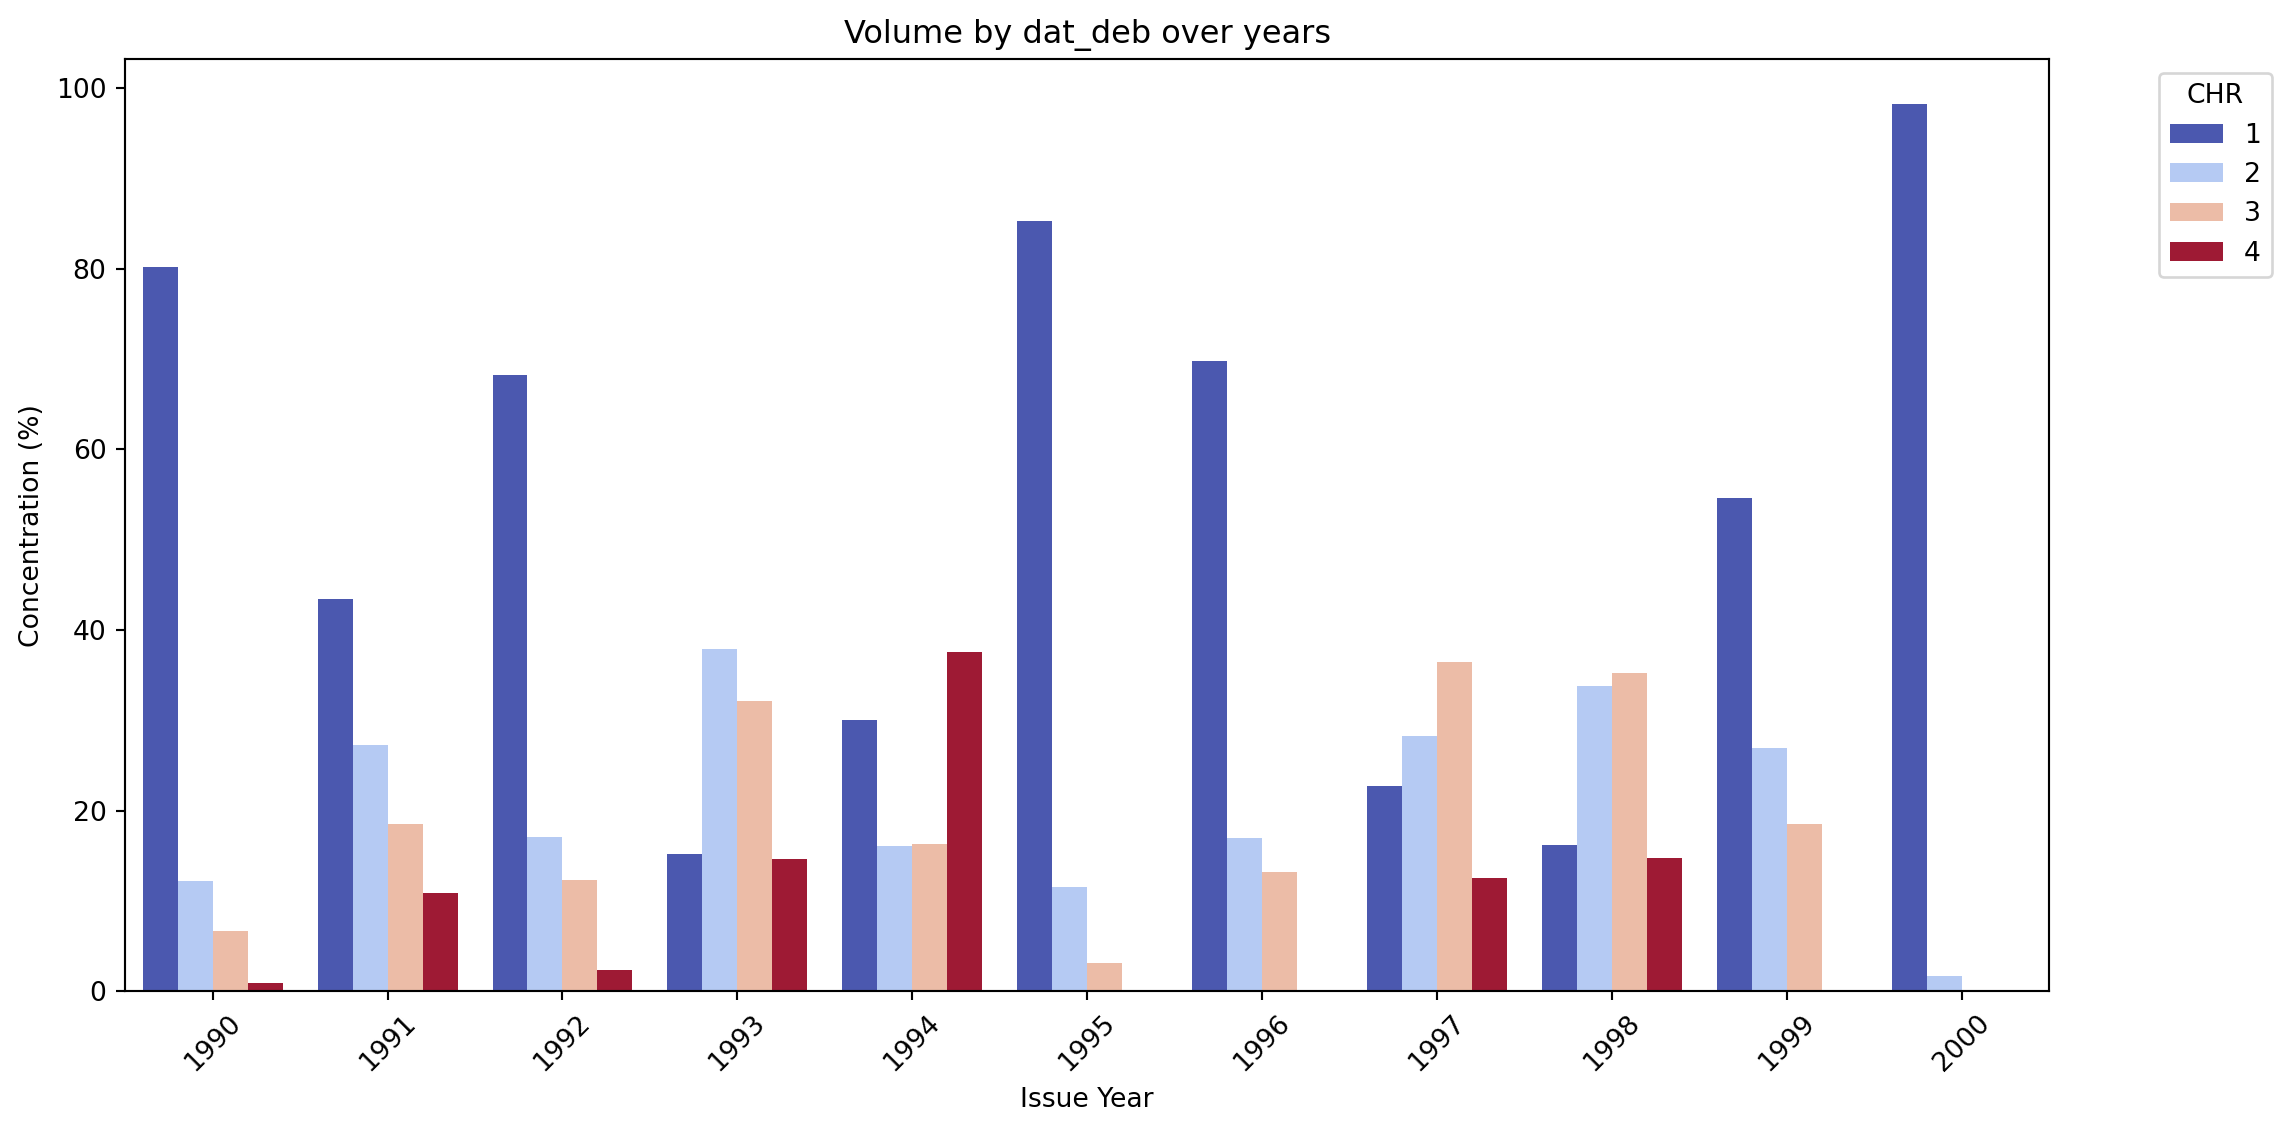

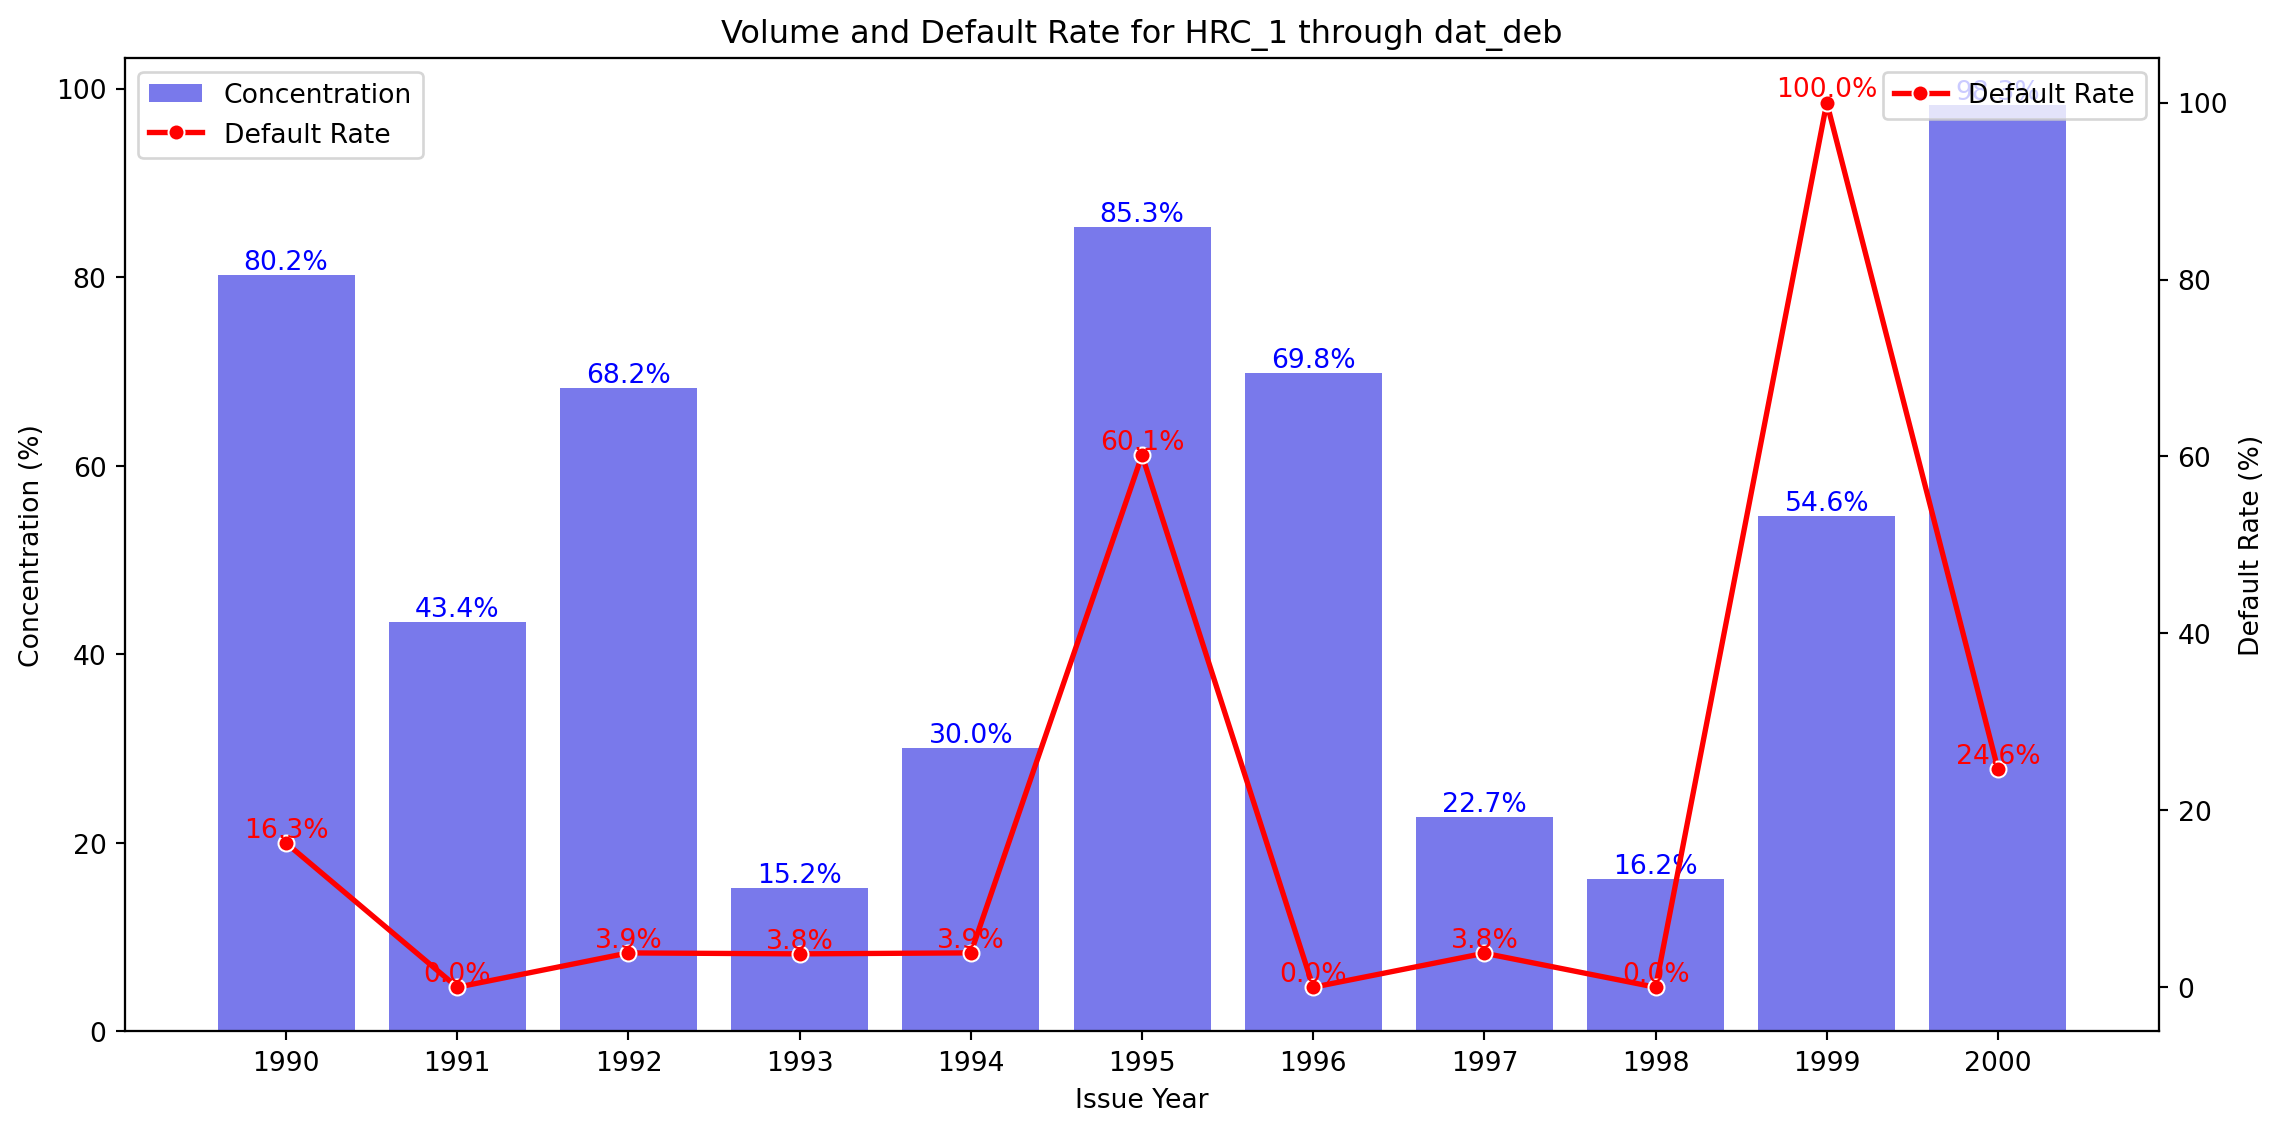

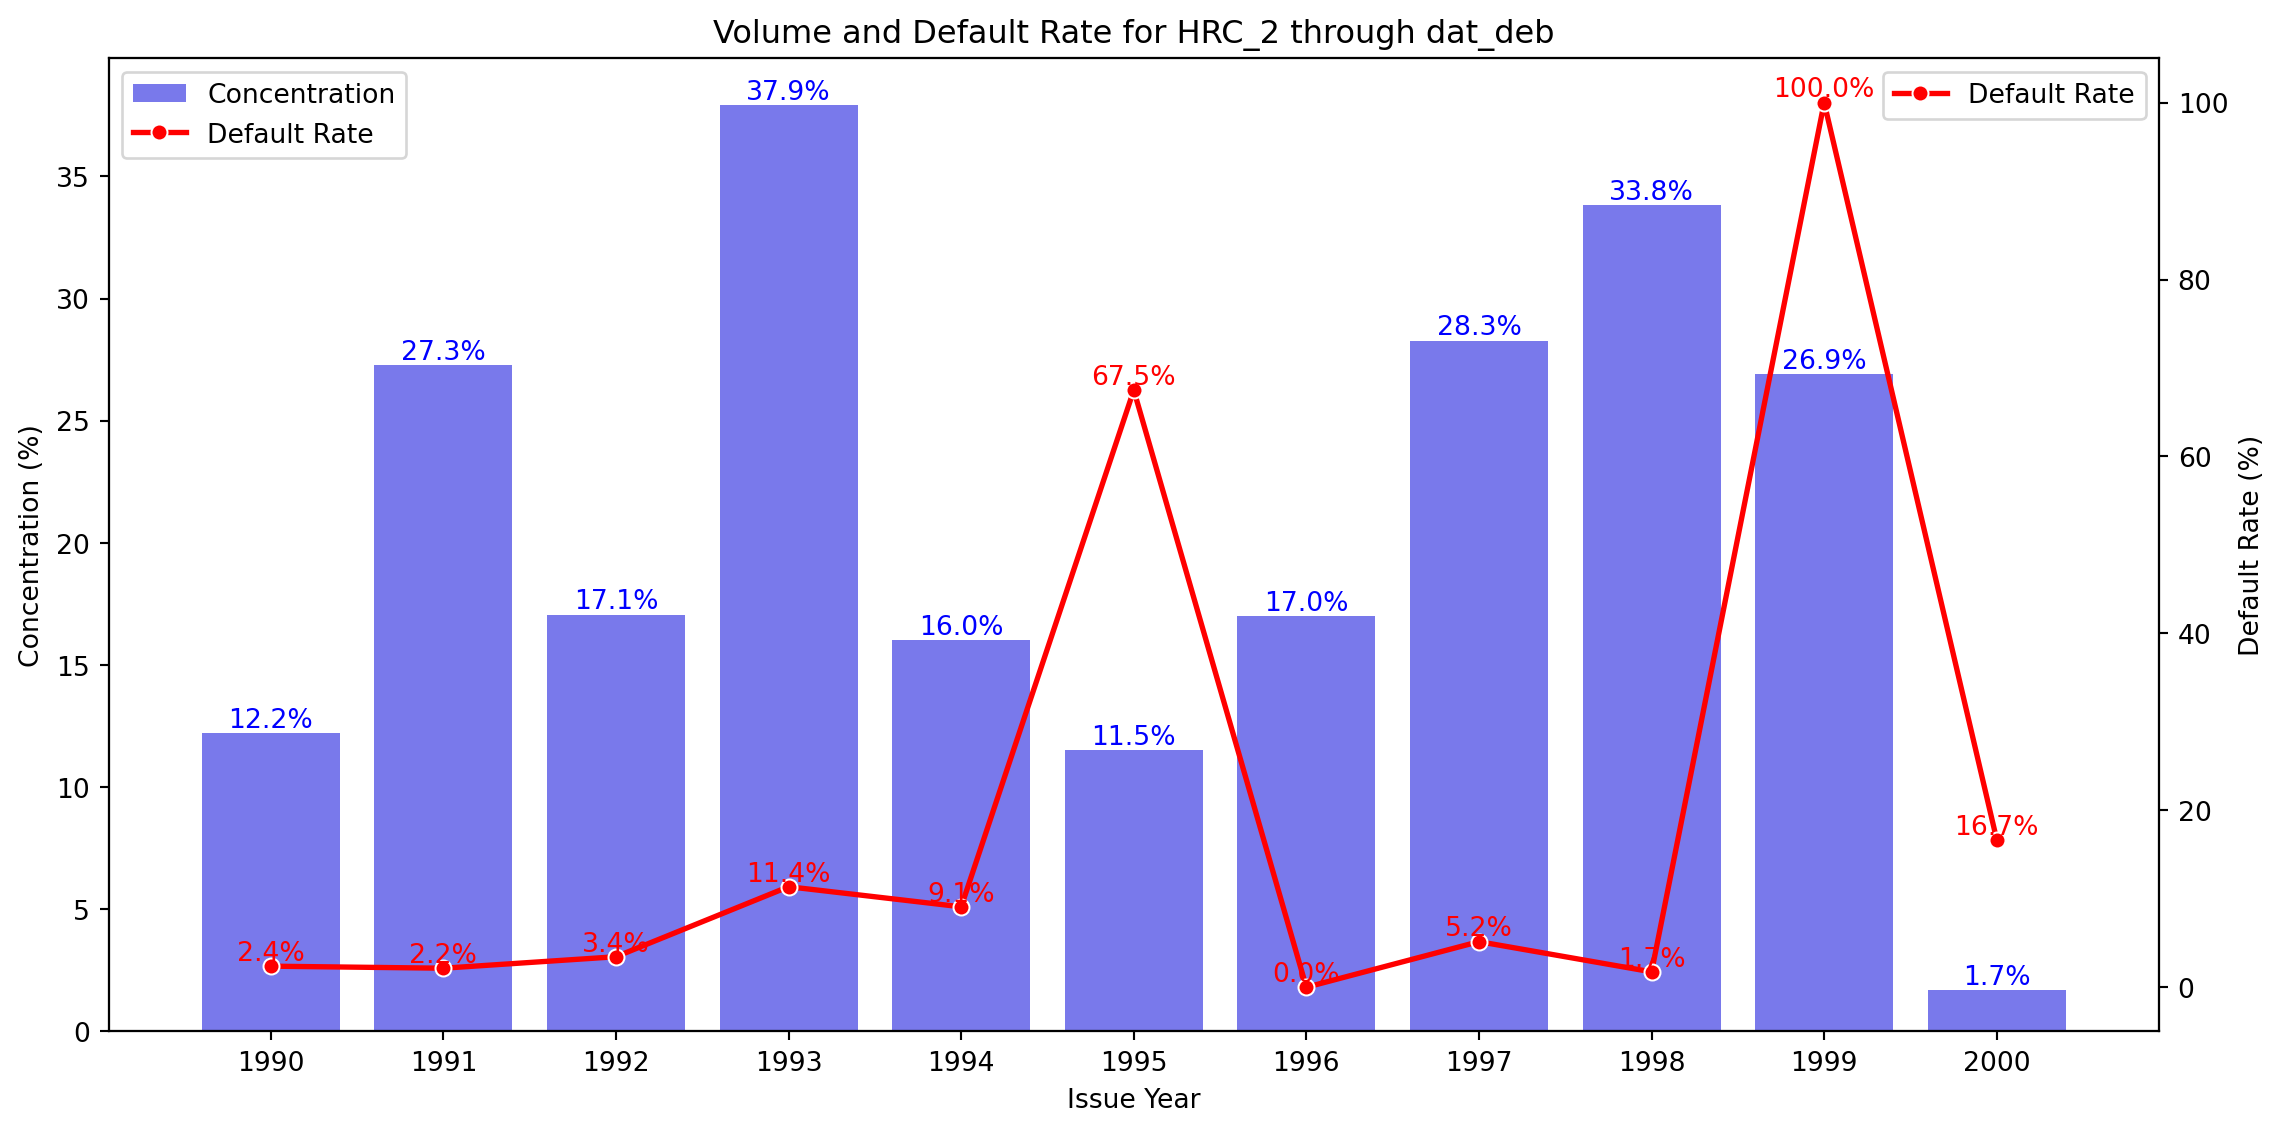

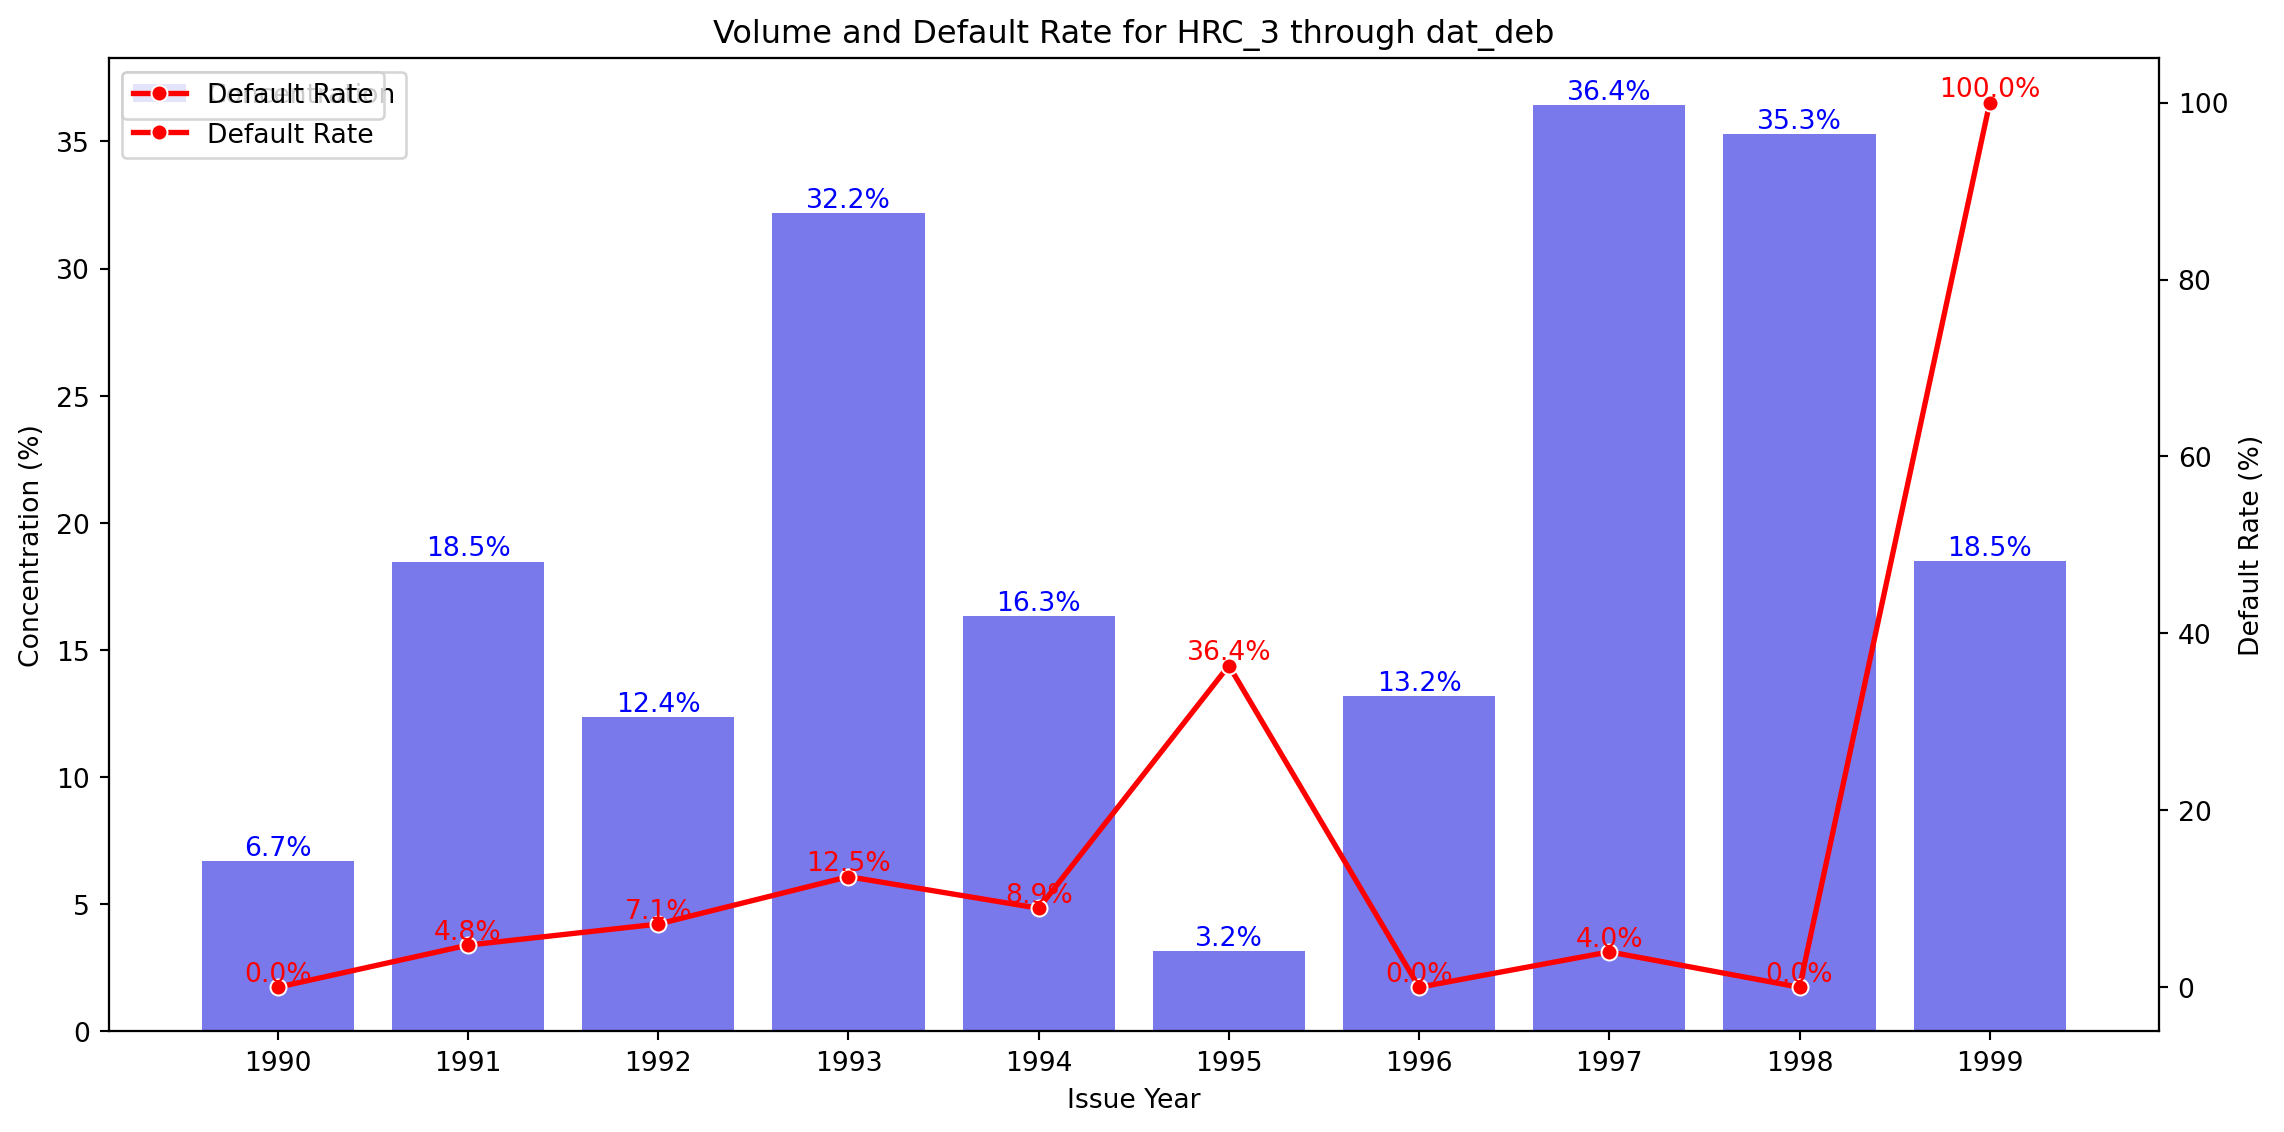

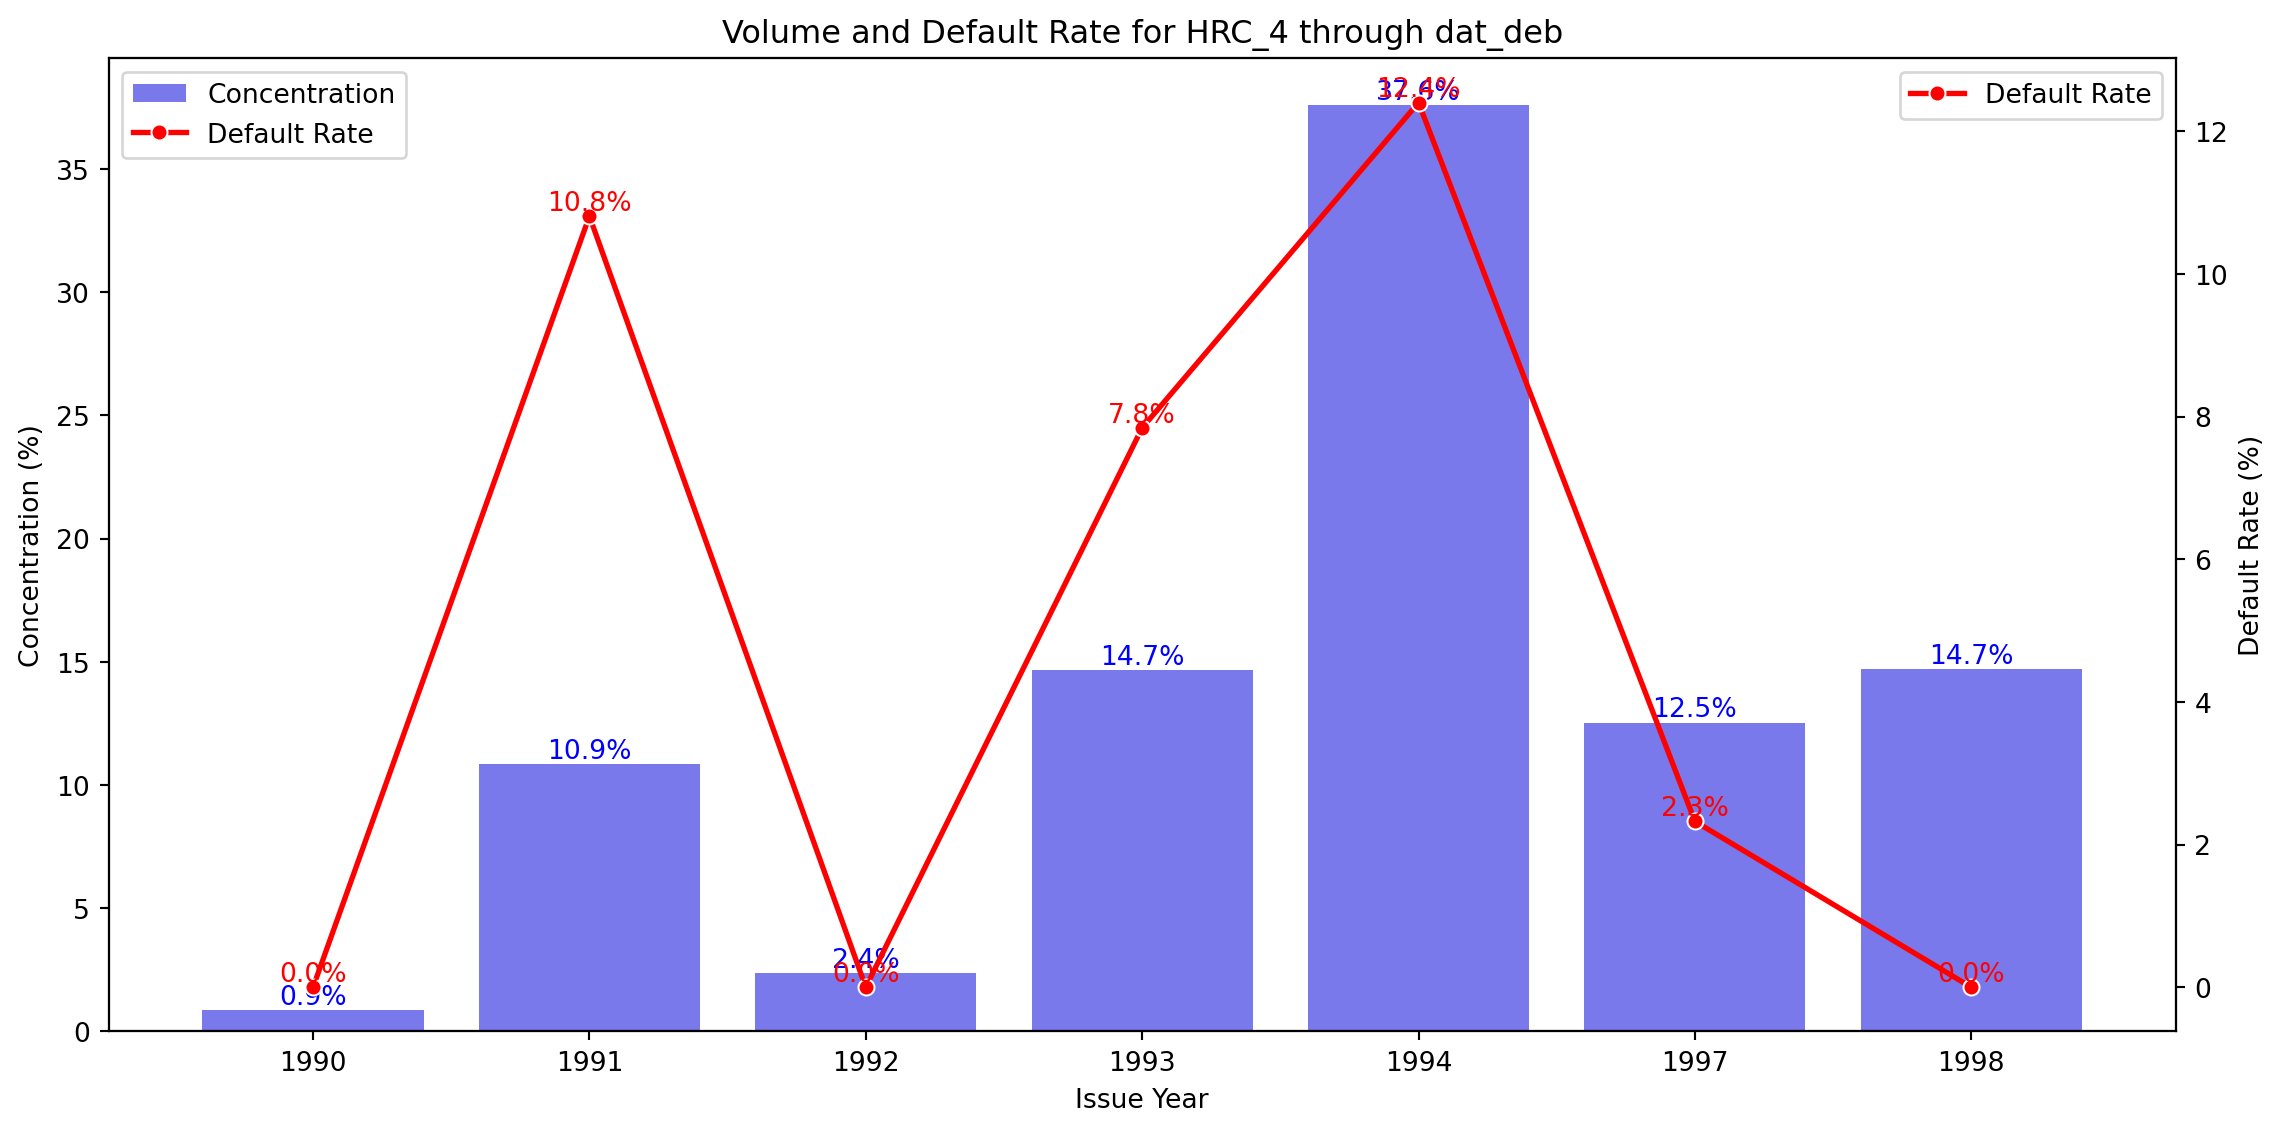

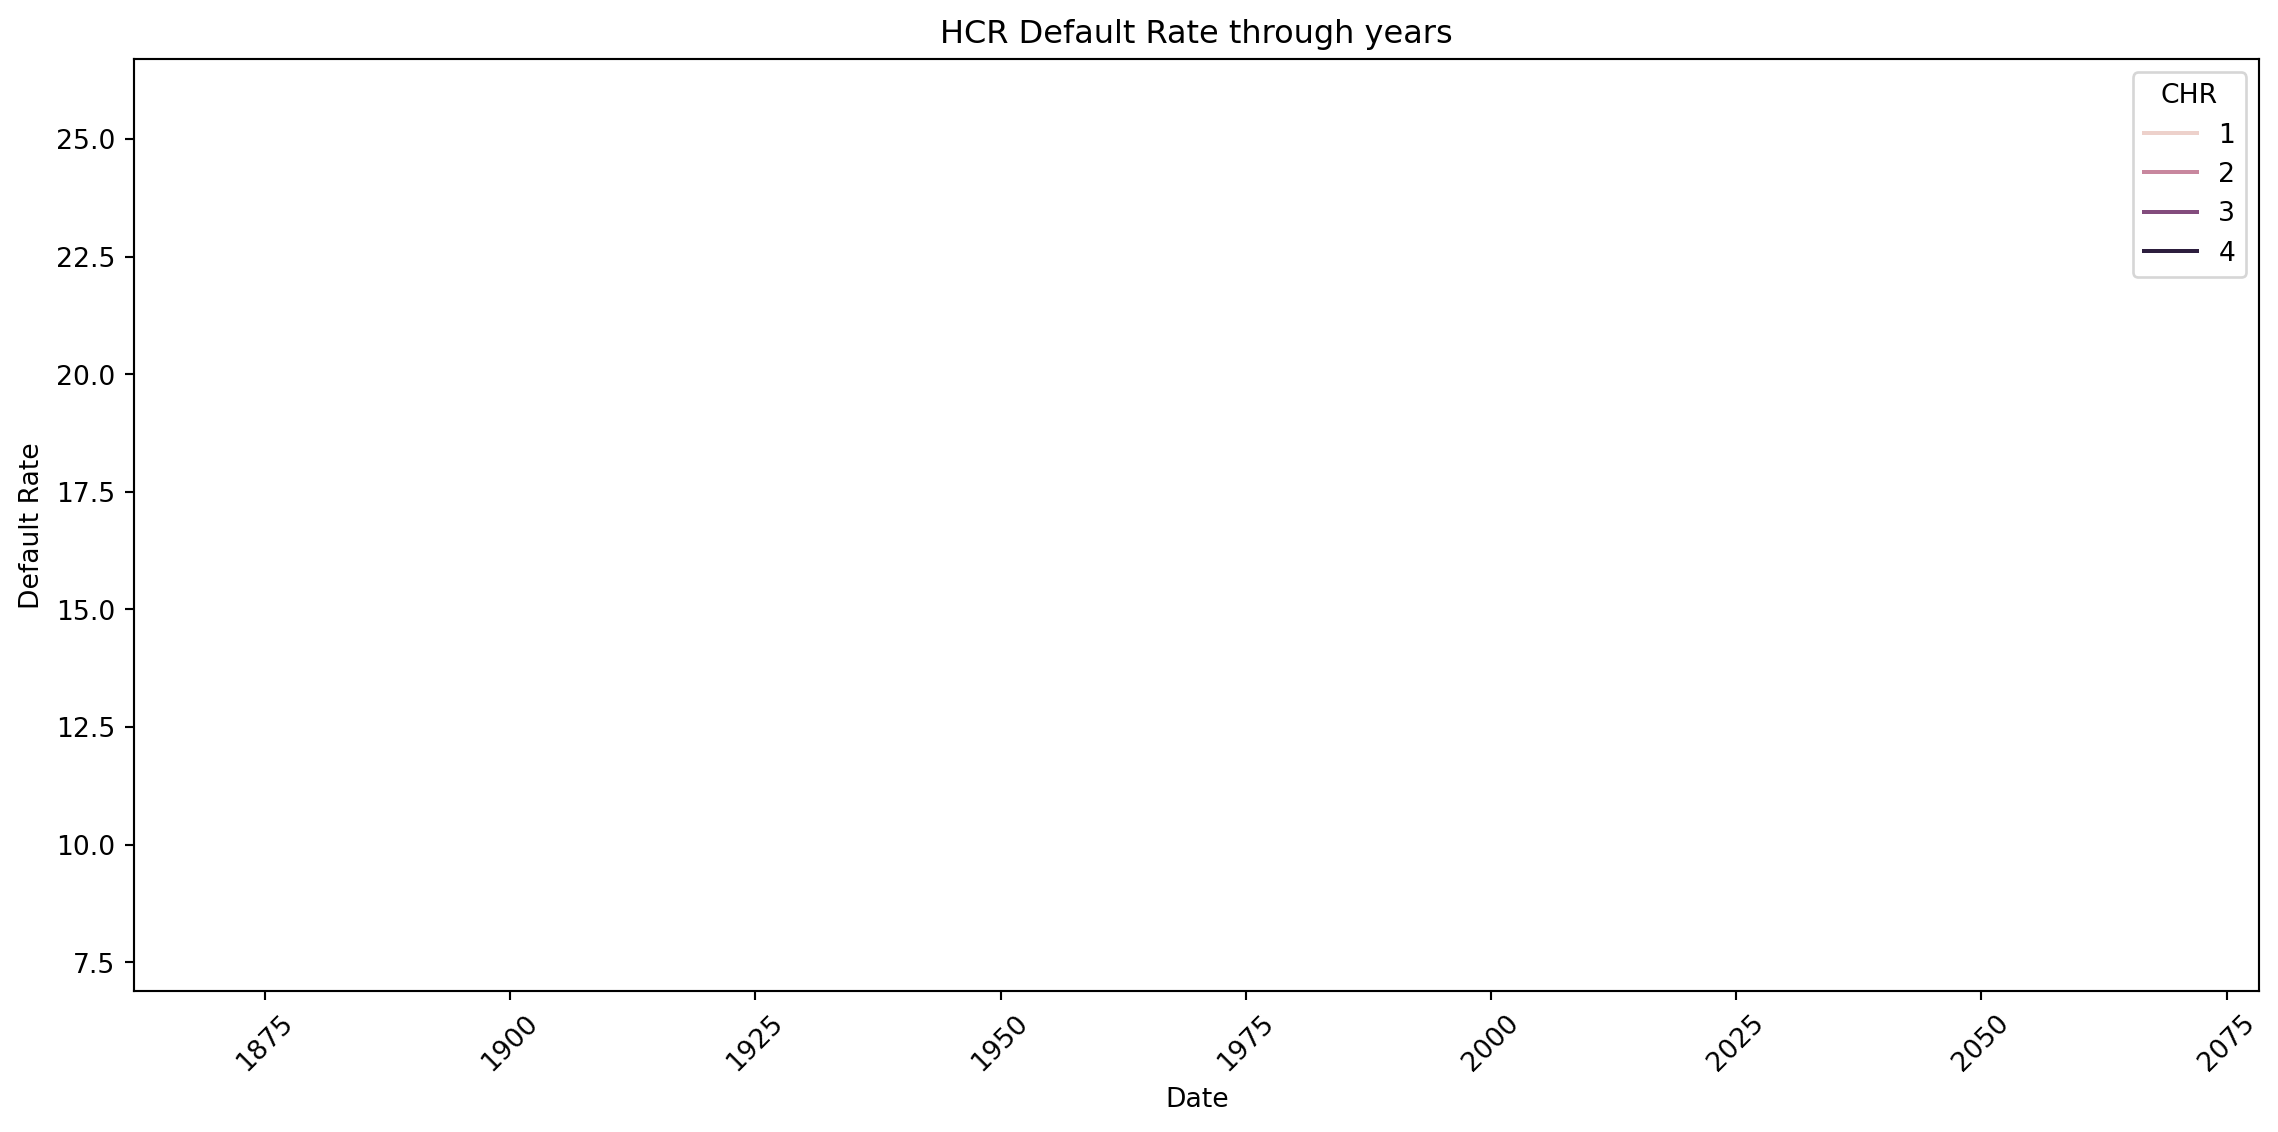

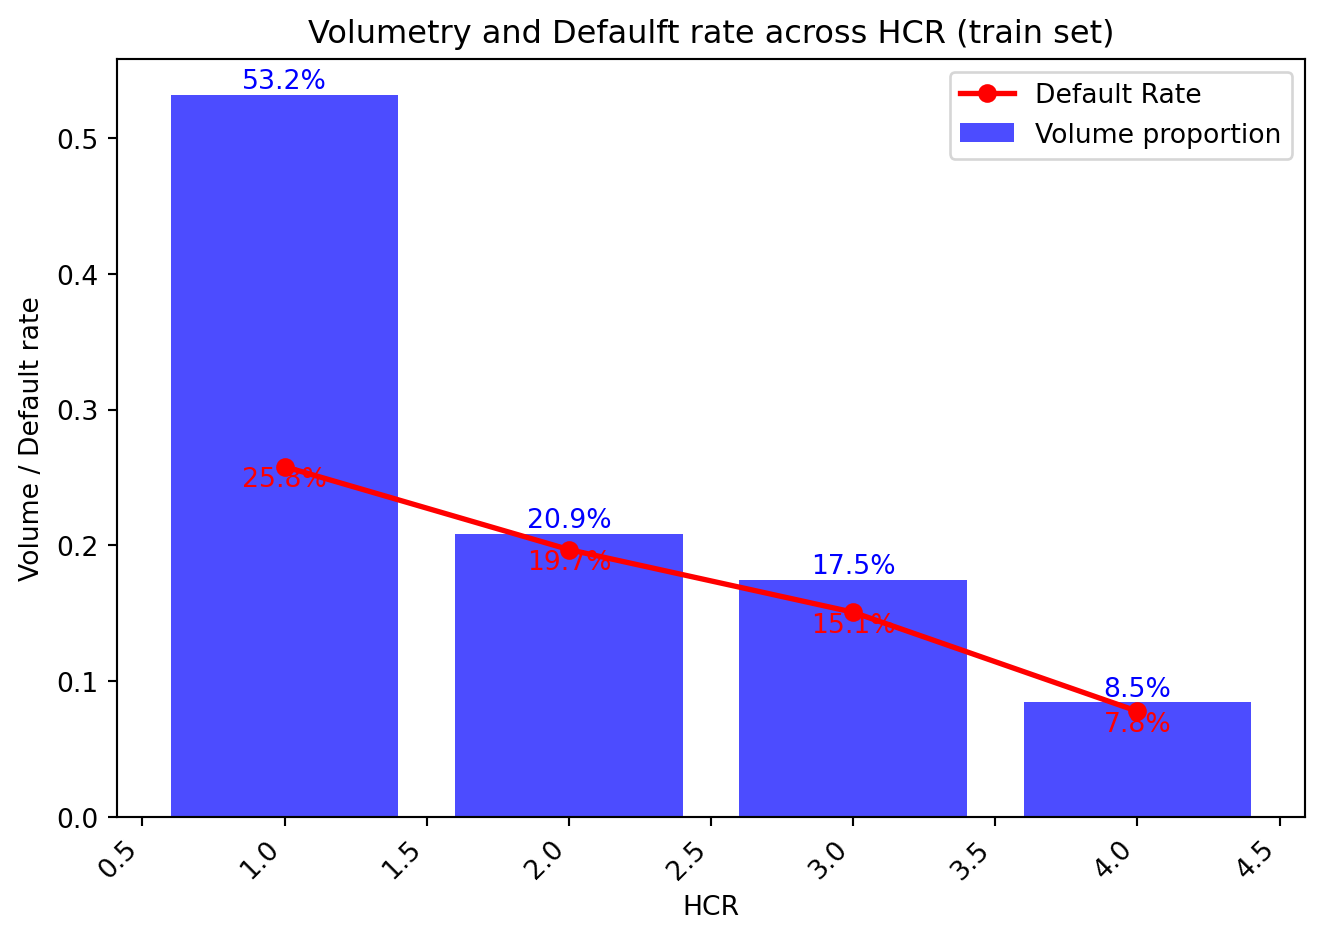

Optimal thresholds: 	[np.float64(-9.5), 1.5, 2.5, 3.5, np.float64(18.5)]
     Default rate  Relatif deviation  Gini index  Shannon entropy
CHR                                                              
4        0.077882                NaN    0.143632         0.273565
3        0.150830          93.665158    0.256160         0.424145
2        0.196970          30.590909    0.316345         0.496173
1        0.258049          31.009258    0.382919         0.571006


In [44]:
target = 'cat_nat'
date_column = 'dat_deb'

for feat in col_num:
    df = data_train.copy()
    conditions, values, thresholds = discretizer(df, feat, target, )
    df['CHR'] = np.select(conditions, values)
    
    concentration_plot(df, 'CHR', target, date_column)
    resultats = taux_defaut(df, 'CHR', date_column, target)
    
    CHR_plot(df, target, label='train')

    # Optimal thresholds 
    print(f'Optimal thresholds: \t{thresholds}')

    # Relative Deviation
    print(resultats)
    #taux_defaut(df, feat)
